<a href="https://colab.research.google.com/github/enicaking/bluetab-uc3m-project-repo/blob/main/notebooks/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<center>

<h1><b>Fraud Detection Project</b></h1>
<h3>Universidad Carlos III de Madrid · Bluetab</h3>

<p><em>Development of a predictive system using Machine Learning to identify fraudulent transactions and strengthen financial security.</em></p>

</center>

---

### Notebook Overview

This notebook is part of the *Bluetab–UC3M Fraud Detection Project*.  
Its main goal is to explore and merge the different datasets provided by the company (`customers_dirty.csv`, `transactions_dirty.csv`, `locations_dirty.csv`, and `creditcard.csv`) to build a clean and unified database for further analysis.  

Throughout this notebook, we:
- Load and inspect the raw data.  
- Perform initial cleaning and consistency checks.  
- Merge datasets into a single structured DataFrame.  
- EDA


---


# **Libraries**

In [1]:
!pip install pvlib
!pip install catboost
!pip install chardet
!pip install xgboost
!pip install polars
!pip install lightgbm
!pip install tabulate
!pip install imbalanced-learn
!pip install scikit-learn
!pip install collections


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections

[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import time
import warnings
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import os
from IPython.display import display
from pathlib import Path

from datetime import datetime, timedelta
from itertools import combinations
from pytz import timezone

from tqdm import tqdm
from tqdm.auto import tqdm

from pvlib.location import Location
from scipy.stats import pearsonr


from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, recall_score, f1_score, precision_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgbm
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC


import os

np.random.seed(123)

c:\Users\M6500QC\OneDrive\Escritorio\1º Cuatrimestre\DATA SCIENCE PROJECT\bluetab-uc3m-project-repo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Upload the datasets**

In [3]:
# If working locally

ROOT = Path().resolve()               # raíz de repo
DATA = ROOT.parent  / "content"

transactions_df = pd.read_csv(DATA / "transactions_dirty.csv")
locations_df = pd.read_csv(DATA / "locations_dirty.csv")
customers_df = pd.read_csv(DATA / "customers_dirty.csv")
flags_df = pd.read_csv(DATA / "flags.csv")
time_table_df = pd.read_csv(DATA / "time_table.csv")
devices_df = pd.read_csv(DATA / "devices.csv")

In [4]:
# # If working on Colab
# transactions_df = pd.read_csv('/content/transactions_dirty.csv')
# locations_df = pd.read_csv('/content/locations_dirty.csv')
# customers_df = pd.read_csv('/content/customers_dirty.csv')
# flags_df = pd.read_csv('/content/flags.csv')
# time_table_df = pd.read_csv('/content/time_table.csv')
# devices_df = pd.read_csv('/content/devices.csv')

# **1. Raw Data Exploration**
This section focuses on the initial exploration of the four raw datasets provided by Bluetab: `customers_dirty.csv`, `transactions_dirty.csv`, `locations_dirty.csv`, and `creditcard.csv`.

The objective is to understand the structure, quality, and characteristics of each dataset, performing an EDA of each one. By analyzing them separately, we can identify inconsistencies, missing values, duplicates, and potential variables of interest for the fraud detection model.

## **Transactions**

In [5]:
display(transactions_df.head())
transactions_df.shape

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Amount,Class,transaction_id,customer_id,device_id
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,822947e3-96bc-4124-8e77-75fc791a6308,1102,DEV_0004
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,107b9ba3-0cd1-48ab-b548-ed6282de31af,1435,DEV_0039
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,64a68036-03d7-434f-b4e9-6af563252772,1860,DEV_0035
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,b3fcacd4-a564-479a-a9b9-cd04d10efed5,1270,DEV_0001
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,2a51fbde-2f19-4ea5-bb7e-cefb24cabd36,1106,DEV_0024


(286815, 33)

In [6]:
print(transactions_df['transaction_id'].duplicated().sum())

500


In [7]:
transactions_df.drop_duplicates(inplace=True) # Complete equal rows are dropped
print(transactions_df['transaction_id'].duplicated().sum()) # There are 3 repeated ids in rows not completely equal

3


In [8]:
duplicated_transactions = transactions_df[transactions_df['transaction_id'].duplicated(keep=False)] # Get all rows with duplicated transaction IDs
print("Duplicated transaction IDs in transactions_df:")
print(duplicated_transactions)

Duplicated transaction IDs in transactions_df:
              V1        V2        V3        V4        V5        V6        V7  \
13213  -2.039728  0.965692  2.166568 -0.005581 -0.086848 -0.098832 -0.216829   
31857  -1.185284  0.512991  2.057373  0.376168  0.234964  0.104018  0.140999   
128428 -1.236607  0.610138  1.576652  1.282104 -0.265792 -0.374496 -0.268472   
286366 -1.236607  0.610138  1.576652  1.282104 -0.265792 -0.374496 -0.268472   
286537 -2.039728  0.965692  2.166568 -0.005581 -0.086848 -0.098832 -0.216829   
286783 -1.185284  0.512991  2.057373  0.376168  0.234964  0.104018  0.140999   

              V8        V9       V10  ...       V24       V25       V26  \
13213   0.198205  1.605322  0.364846  ...  0.157698 -0.031629  0.211652   
31857   0.329286 -0.358042 -0.077797  ... -0.025780 -0.152223 -0.523562   
128428  0.471094 -0.561624 -0.352570  ...  0.454560 -0.392421 -0.232860   
286366  0.471094 -0.561624 -0.352570  ...  0.454560 -0.392421 -0.232860   
286537  0.198205 

The amount is the same, the customer and device id are different and it is impossible to have two equal transaction ids, so we compared with other database.

In [9]:
duplicated_df = transactions_df[transactions_df['transaction_id'].duplicated(keep=False)].copy()
aux = pd.merge(duplicated_df, customers_df, on='customer_id', how='inner')
display(aux)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,transaction_id,customer_id,device_id,name,age,email,phone,country,credit_score,join_date
0,-2.039728,0.965692,2.166568,-0.005581,-0.086848,-0.098832,-0.216829,0.198205,1.605322,0.364846,...,a995c6a8-ef9d-4c4f-928d-7149a5549fc8,1163,DEV_0100,Ariel Sandoval,70,NaN,689.731.8692x8972,Serbia,787,2021-09-17
1,-1.236607,0.610138,1.576652,1.282104,-0.265792,-0.374496,-0.268472,0.471094,-0.561624,-0.352570,...,70a09c87-2693-4455-9373-01c07f4cbc65,1955,DEV_0089,Anthony Rodriguez,38,xmalone@example.org,611-818-2422x412,Greenland,702,2023-08-27
2,-1.185284,0.512991,2.057373,0.376168,0.234964,0.104018,0.140999,0.329286,-0.358042,-0.077797,...,7dd260b9-5836-4d26-9163-ceff19cee458,1617,DEV_0038,Virginia Casey,33,carpenterjorge@example.net,001-821-229-9642,Luxembourg,493,2022-06-20


In [10]:
# Remove the rows which are incorrect (the customer_id does not match in the transaction database with the customer database)
transactions_df = transactions_df[~(
    (transactions_df['transaction_id'] == "a995c6a8-ef9d-4c4f-928d-7149a5549fc8") &
    (transactions_df['customer_id'] == 99180)
)]

transactions_df = transactions_df[~(
    (transactions_df['transaction_id'] == "70a09c87-2693-4455-9373-01c07f4cbc65") &
    (transactions_df['customer_id'] == 99172)
)]

transactions_df = transactions_df[~(
    (transactions_df['transaction_id'] == "7dd260b9-5836-4d26-9163-ceff19cee458") &
    (transactions_df['customer_id'] == 99209)
)]

In [11]:
print(transactions_df.shape)

(286315, 33)


## **Locations**

In [12]:
display(locations_df.head())
locations_df.shape

,transaction_id,ip_address,country,city,zip_code,merchant
0,822947e3-96bc-4124-8e77-75fc791a6308,83.63.232.13,Australia,Perth,NaN,Davis-Parker
1,107b9ba3-0cd1-48ab-b548-ed6282de31af,89.213.161.51,Australia,Perth,57376.0,Garcia-Mitchell
2,64a68036-03d7-434f-b4e9-6af563252772,140.231.3.186,France,Lyon,19277.0,Mccann-Snow
3,b3fcacd4-a564-479a-a9b9-cd04d10efed5,40.46.209.108,Germany,Berlin,93260.0,Jones Inc
4,2a51fbde-2f19-4ea5-bb7e-cefb24cabd36,174.155.184.108,Australia,Melbourne,97401.0,Rodriguez Inc


(286315, 6)

In [13]:
print(locations_df['transaction_id'].duplicated().sum())

0


## **Customers**

In [14]:
display(customers_df.head())
customers_df.shape

,customer_id,name,age,email,phone,country,credit_score,join_date
0,1102,Allison Hill,56,qjacobson@example.org,6502166799,Gambia,787,2024-03-18
1,1435,Noah Rhodes,69,ylopez@example.com,767.389.9730x8069,Georgia,582,2021-09-04
2,1860,Angie Henderson,46,seanbaker@example.com,567-917-9576x024,Mayotte,765,2023-11-19
3,1270,Daniel Wagner,32,jeremy49@example.org,(873)783-9597x246,Papua New Guinea,612,2021-02-23
4,1106,Cristian Santos,60,karencontreras@example.org,329.834.1722x3297,Serbia,580,2021-04-17


(1000, 8)

In [15]:
print(customers_df['customer_id'].duplicated().sum())

0


## **Flags**

In [16]:
display(flags_df.head())
flags_df.shape

,transaction_id,is_foreign_tx,is_night_tx,is_high_amount
0,822947e3-96bc-4124-8e77-75fc791a6308,1,1,0
1,107b9ba3-0cd1-48ab-b548-ed6282de31af,1,1,0
2,64a68036-03d7-434f-b4e9-6af563252772,1,1,0
3,b3fcacd4-a564-479a-a9b9-cd04d10efed5,1,1,0
4,2a51fbde-2f19-4ea5-bb7e-cefb24cabd36,1,1,0


(286315, 4)

In [17]:
print(flags_df['transaction_id'].duplicated().sum())

0


## **Time-table**

In [18]:
display(time_table_df.head())
time_table_df.shape

,transaction_id,timestamp,hour,day_of_week,is_weekend,month,time_of_day
0,822947e3-96bc-4124-8e77-75fc791a6308,2023-01-01 00:00:00,0,6,1,1,Night
1,107b9ba3-0cd1-48ab-b548-ed6282de31af,2023-01-01 00:00:00,0,6,1,1,Night
2,64a68036-03d7-434f-b4e9-6af563252772,2023-01-01 00:00:01,0,6,1,1,Night
3,b3fcacd4-a564-479a-a9b9-cd04d10efed5,2023-01-01 00:00:01,0,6,1,1,Night
4,2a51fbde-2f19-4ea5-bb7e-cefb24cabd36,2023-01-01 00:00:02,0,6,1,1,Night


(286315, 7)

In [19]:
print(time_table_df['transaction_id'].duplicated().sum())

0


## **Devices**

In [20]:
display(devices_df.head())
devices_df.shape

,device_id,device_type,os,browser,is_mobile
0,DEV_0001,Desktop,macOS,Chrome,0
1,DEV_0002,POS,Android,Firefox,0
2,DEV_0003,ATM,Linux,Chrome,0
3,DEV_0004,Desktop,Windows,Safari,0
4,DEV_0005,POS,Android,Safari,0


(100, 5)

In [21]:
print(devices_df['device_id'].duplicated().sum())

0


# **2. Data Merging and Integration**
This section combines the different raw datasets into a single unified structure, linking transactions, customers, locations (*TODO: and credit card features.*)
The goal is to build a consistent and complete dataset that can be used for global exploratory analysis and model development.

In [22]:
merged_df = pd.merge(transactions_df, locations_df, on='transaction_id', how='inner')
print(merged_df.shape)

(286315, 38)


In [23]:
merge2_df = pd.merge(merged_df, flags_df, on='transaction_id', how='inner')
display(merge2_df.head())
print(merge2_df.shape)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,customer_id,device_id,ip_address,country,city,zip_code,merchant,is_foreign_tx,is_night_tx,is_high_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,1102,DEV_0004,83.63.232.13,Australia,Perth,NaN,Davis-Parker,1,1,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,1435,DEV_0039,89.213.161.51,Australia,Perth,57376.0,Garcia-Mitchell,1,1,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,1860,DEV_0035,140.231.3.186,France,Lyon,19277.0,Mccann-Snow,1,1,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,1270,DEV_0001,40.46.209.108,Germany,Berlin,93260.0,Jones Inc,1,1,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,1106,DEV_0024,174.155.184.108,Australia,Melbourne,97401.0,Rodriguez Inc,1,1,0


(286315, 41)


In [24]:
merge3_df = pd.merge(merge2_df, time_table_df, on='transaction_id', how='inner')
display(merge3_df.head())
print(merge3_df.shape)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,merchant,is_foreign_tx,is_night_tx,is_high_amount,timestamp,hour,day_of_week,is_weekend,month,time_of_day
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,Davis-Parker,1,1,0,2023-01-01 00:00:00,0,6,1,1,Night
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,Garcia-Mitchell,1,1,0,2023-01-01 00:00:00,0,6,1,1,Night
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,Mccann-Snow,1,1,0,2023-01-01 00:00:01,0,6,1,1,Night
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,Jones Inc,1,1,0,2023-01-01 00:00:01,0,6,1,1,Night
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,Rodriguez Inc,1,1,0,2023-01-01 00:00:02,0,6,1,1,Night


(286315, 47)


In [25]:
merge4_df = pd.merge(merge3_df, devices_df, on='device_id', how='inner')
display(merge4_df.head())
print(merge4_df.shape)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,timestamp,hour,day_of_week,is_weekend,month,time_of_day,device_type,os,browser,is_mobile
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,2023-01-01 00:00:00,0,6,1,1,Night,Desktop,Windows,Safari,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,2023-01-01 00:00:00,0,6,1,1,Night,Mobile,Android,Firefox,1
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,2023-01-01 00:00:01,0,6,1,1,Night,Mobile,Android,NaN,1
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,2023-01-01 00:00:01,0,6,1,1,Night,Desktop,macOS,Chrome,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,2023-01-01 00:00:02,0,6,1,1,Night,ATM,Linux,Chrome,0


(286315, 51)


In [26]:
df = pd.merge(merge4_df, customers_df, on='customer_id', how='left')
display(df.head())
print(df.shape)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,os,browser,is_mobile,name,age,email,phone,country_y,credit_score,join_date
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,Windows,Safari,0,Allison Hill,56.0,qjacobson@example.org,6502166799,Gambia,787.0,2024-03-18
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,Android,Firefox,1,Noah Rhodes,69.0,ylopez@example.com,767.389.9730x8069,Georgia,582.0,2021-09-04
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,Android,NaN,1,Angie Henderson,46.0,seanbaker@example.com,567-917-9576x024,Mayotte,765.0,2023-11-19
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,macOS,Chrome,0,Daniel Wagner,32.0,jeremy49@example.org,(873)783-9597x246,Papua New Guinea,612.0,2021-02-23
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,Linux,Chrome,0,Cristian Santos,60.0,karencontreras@example.org,329.834.1722x3297,Serbia,580.0,2021-04-17


(286315, 58)


# **3. Exploratory Data Analysis on Merged Dataset**

Now that we have our merged dataset, we take a closer look at each variable (boxplots and histograms for numerical variables, bar charts for non-numeric variables) and also gain a deeper understanding of the correlations between variables. Each variable was individually plotted in relation to the Fradulence Status, and then PCA, ranking and feature importance models were applied to understand the contribution of each variable to the overall model.

In [27]:
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286315 entries, 0 to 286314
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   V1              286315 non-null  float64
 1   V2              286315 non-null  float64
 2   V3              286315 non-null  float64
 3   V4              286315 non-null  float64
 4   V5              286315 non-null  float64
 5   V6              286315 non-null  float64
 6   V7              286315 non-null  float64
 7   V8              286315 non-null  float64
 8   V9              286315 non-null  float64
 9   V10             286315 non-null  float64
 10  V11             286315 non-null  float64
 11  V12             286315 non-null  float64
 12  V13             286315 non-null  float64
 13  V14             286315 non-null  float64
 14  V15             286315 non-null  float64
 15  V16             286315 non-null  float64
 16  V17             286315 non-null  float64
 17  V18       

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,os,browser,is_mobile,name,age,email,phone,country_y,credit_score,join_date
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,Windows,Safari,0,Allison Hill,56.0,qjacobson@example.org,6502166799,Gambia,787.0,2024-03-18
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,Android,Firefox,1,Noah Rhodes,69.0,ylopez@example.com,767.389.9730x8069,Georgia,582.0,2021-09-04
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,Android,NaN,1,Angie Henderson,46.0,seanbaker@example.com,567-917-9576x024,Mayotte,765.0,2023-11-19
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,macOS,Chrome,0,Daniel Wagner,32.0,jeremy49@example.org,(873)783-9597x246,Papua New Guinea,612.0,2021-02-23
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,Linux,Chrome,0,Cristian Santos,60.0,karencontreras@example.org,329.834.1722x3297,Serbia,580.0,2021-04-17


In [28]:
# We rename the country variables
df.rename(columns={'country_x': 'merchant_country'}, inplace=True)
df.rename(columns={'country_y': 'customer_country'}, inplace=True)

In [29]:
# We convert the variables we do not want as numeric
df["zip_code"] = df["zip_code"].astype("object")
df["customer_id"] = df["customer_id"].astype("object")
print(df.dtypes)

V1                  float64
V2                  float64
V3                  float64
V4                  float64
V5                  float64
V6                  float64
V7                  float64
V8                  float64
V9                  float64
V10                 float64
V11                 float64
V12                 float64
V13                 float64
V14                 float64
V15                 float64
V16                 float64
V17                 float64
V18                 float64
V19                 float64
V20                 float64
V21                 float64
V22                 float64
V23                 float64
V24                 float64
V25                 float64
V26                 float64
V27                 float64
V28                 float64
Amount              float64
Class                 int64
transaction_id       object
customer_id          object
device_id            object
ip_address           object
merchant_country     object
city                

Class
0    284315
1      2000
Name: count, dtype: int64


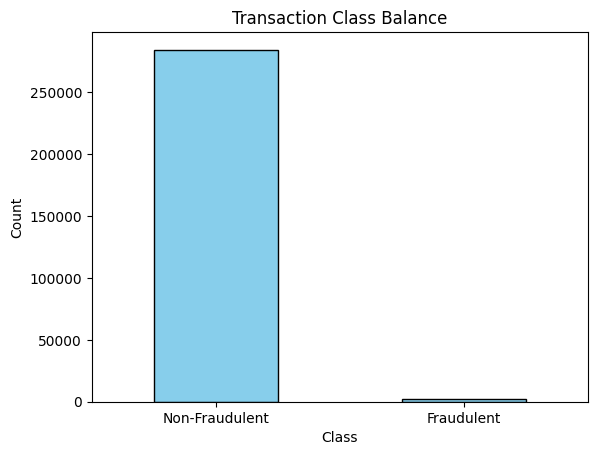

In [30]:
# We check the Class balance between Fraudulent and Non Fraudulent transactions
print(df["Class"].value_counts())
df["Class"].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Transaction Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"], rotation=0)
plt.show()

In [31]:
numeric_vars = [
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
    'Amount', 'age', 'credit_score', 'hour']
numeric_df = df[numeric_vars]

categoric_vars = ['ip_address', 'merchant_country', 'city', 'zip_code', 'merchant',
    'customer_country', 'month', 'time_of_day', 'device_type', 'os', 'browser']
categoric_df = df[categoric_vars]

binary_vars = ['is_foreign_tx', 'is_night_tx', 'is_high_amount',
    'day_of_week', 'is_weekend', 'is_mobile']
binary_df = df[binary_vars]

target_vars = ['Class']
target_df = df[target_vars]

## Variable Distributions

This section examines the distribution of all variables—numeric, categorical, and binary—to understand their characteristics and potential influence on fraud detection.

### Numeric Variables

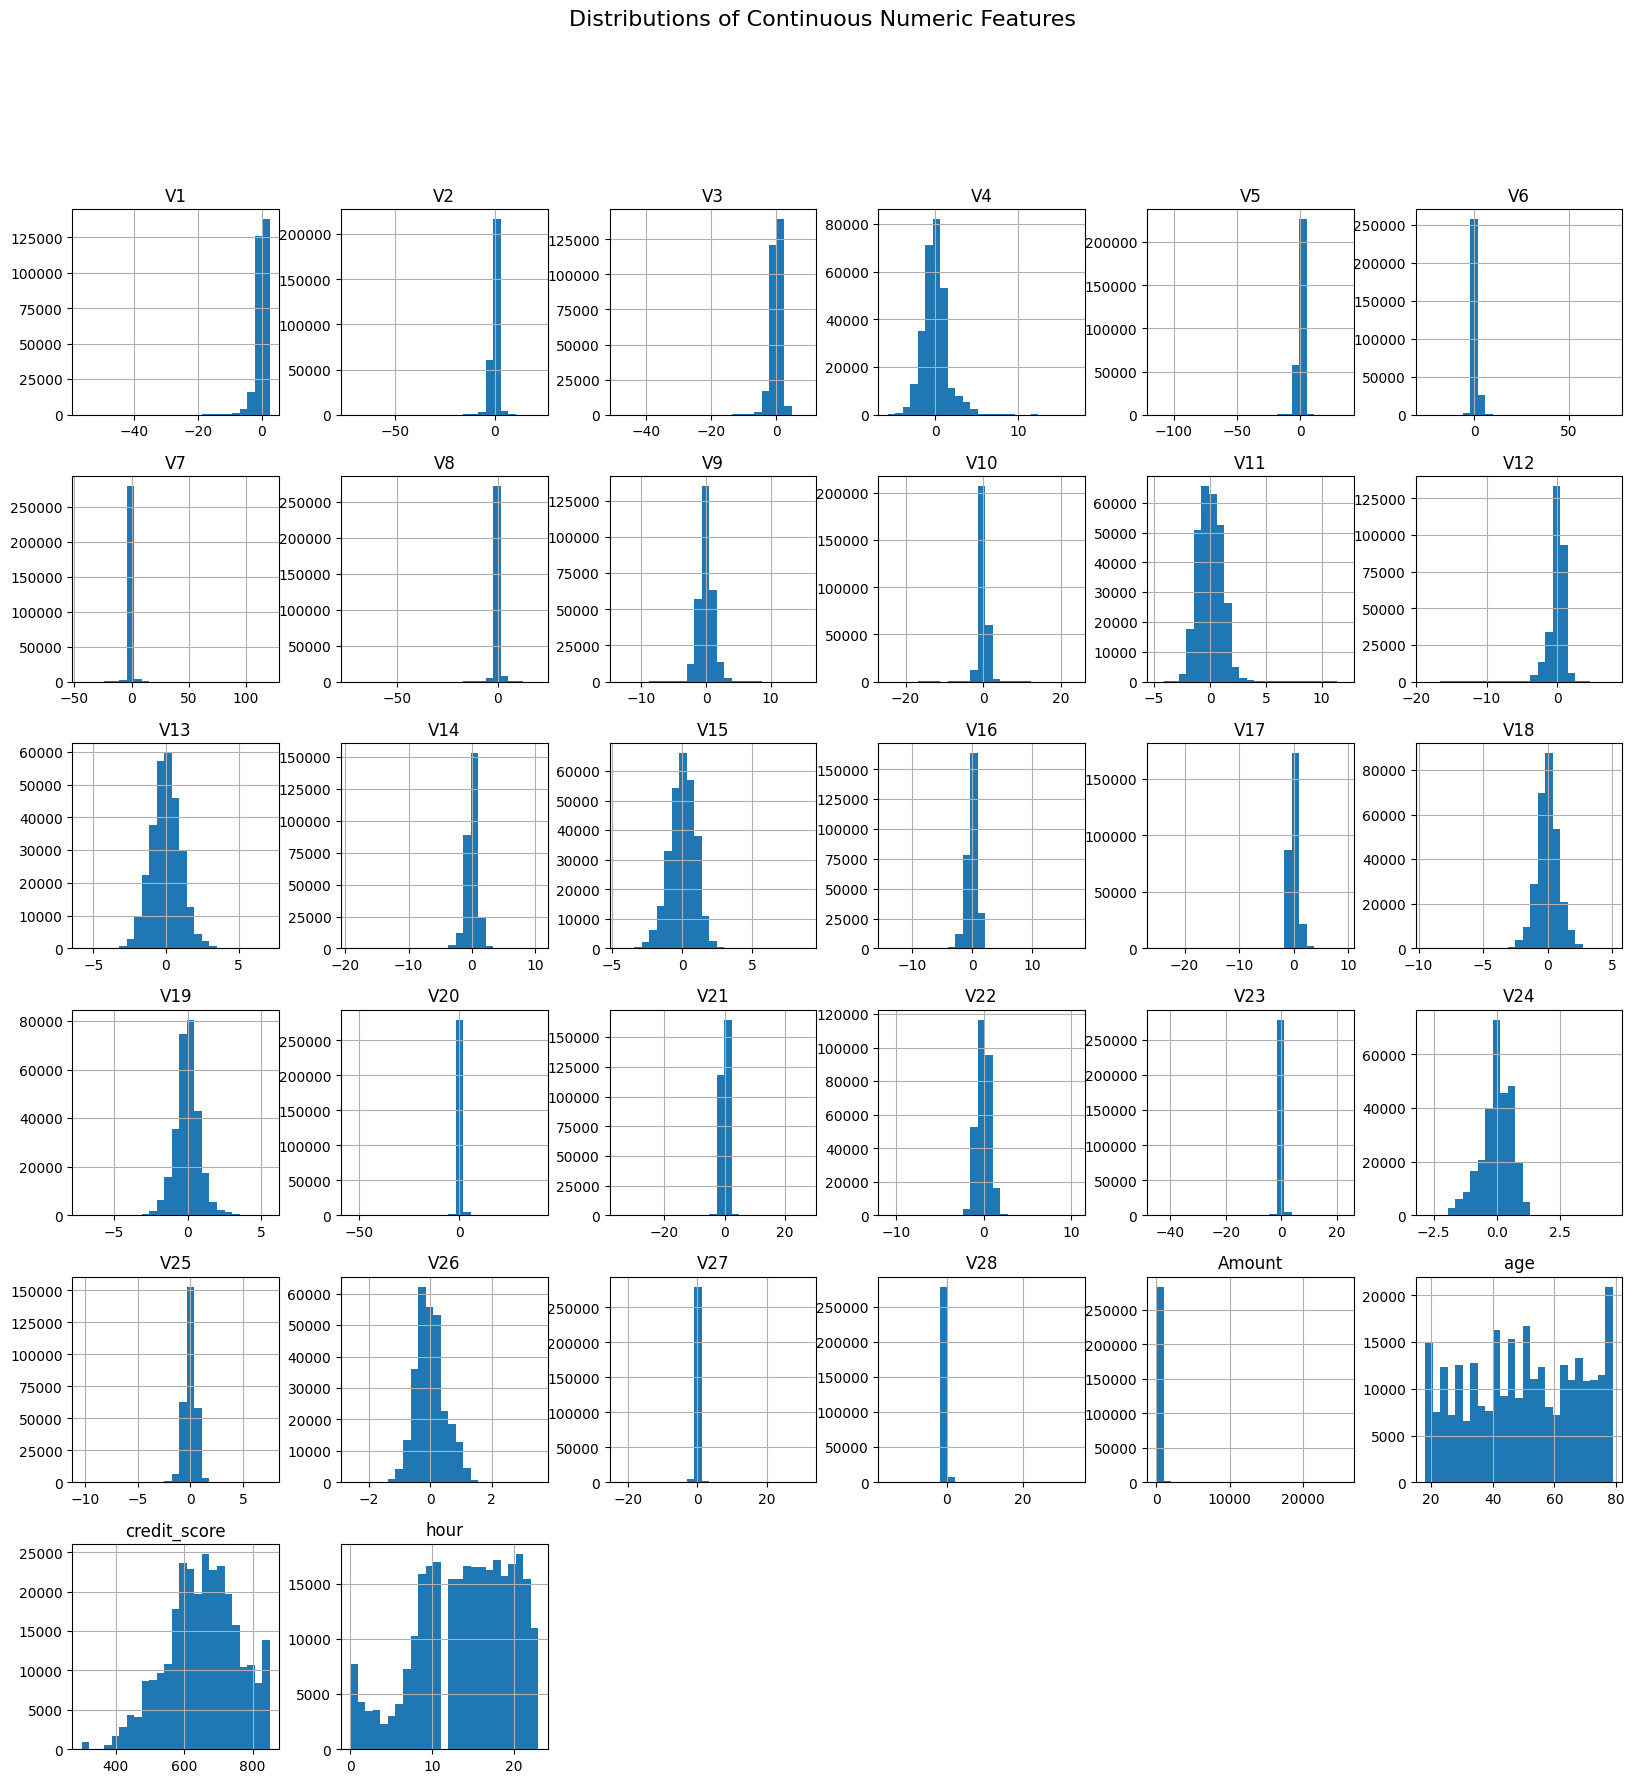

In [32]:
# Plot histograms for continuous numeric features
numeric_df.hist(figsize=(20, 20), bins=25)
plt.suptitle("Distributions of Continuous Numeric Features", fontsize=16)
plt.show()

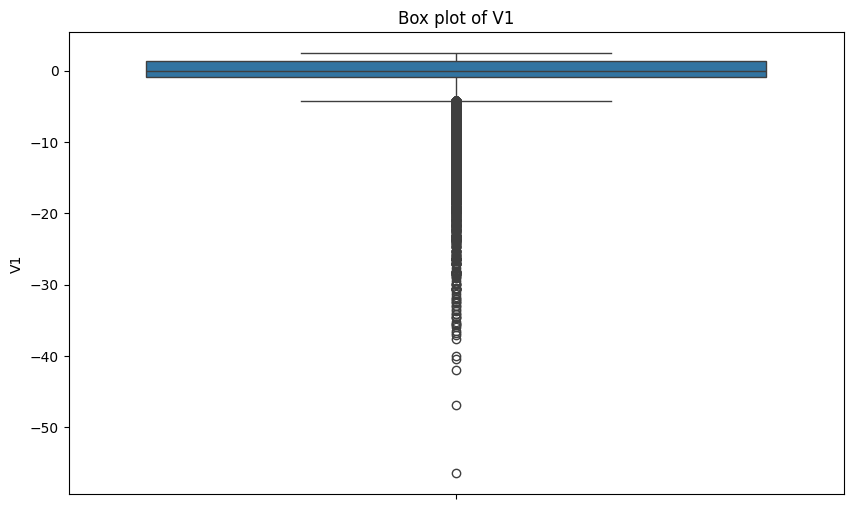

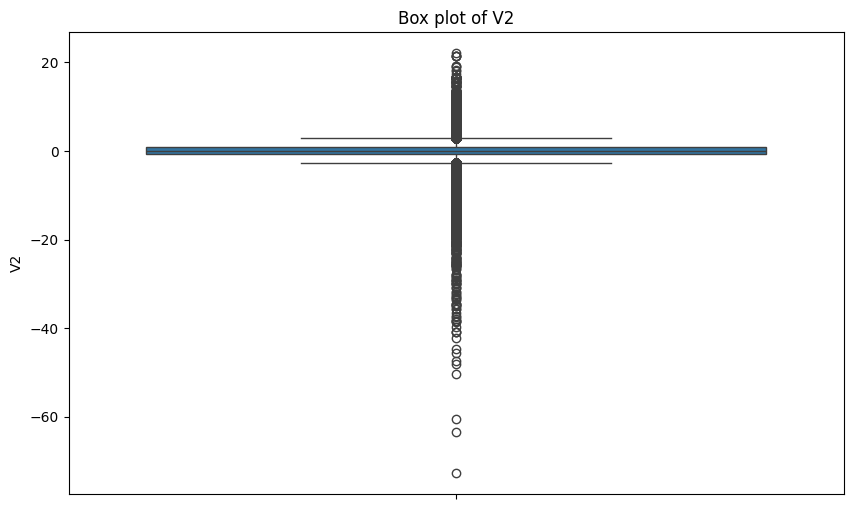

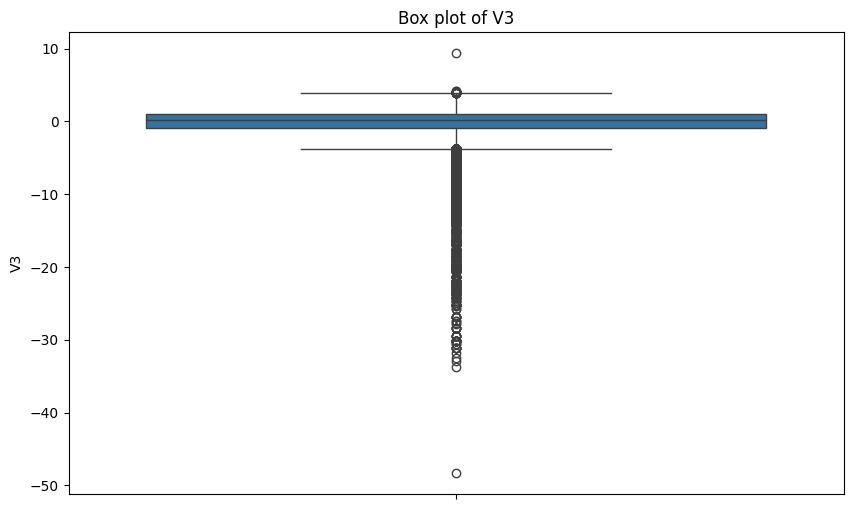

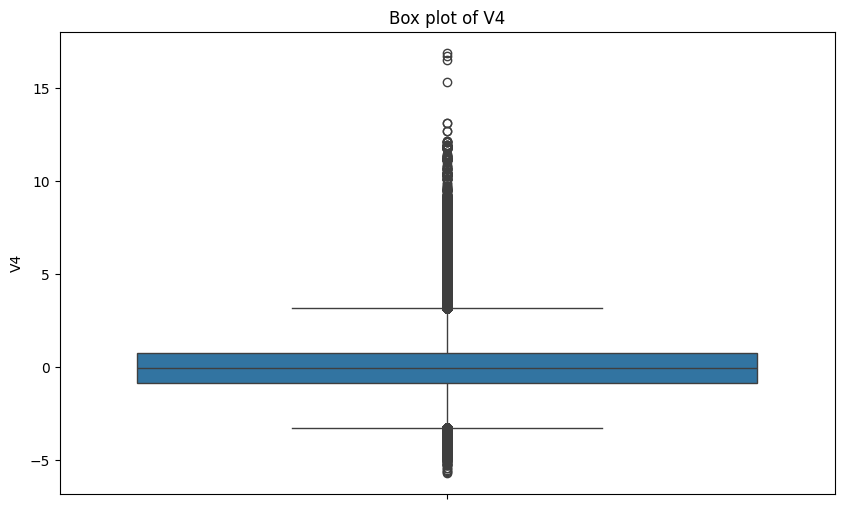

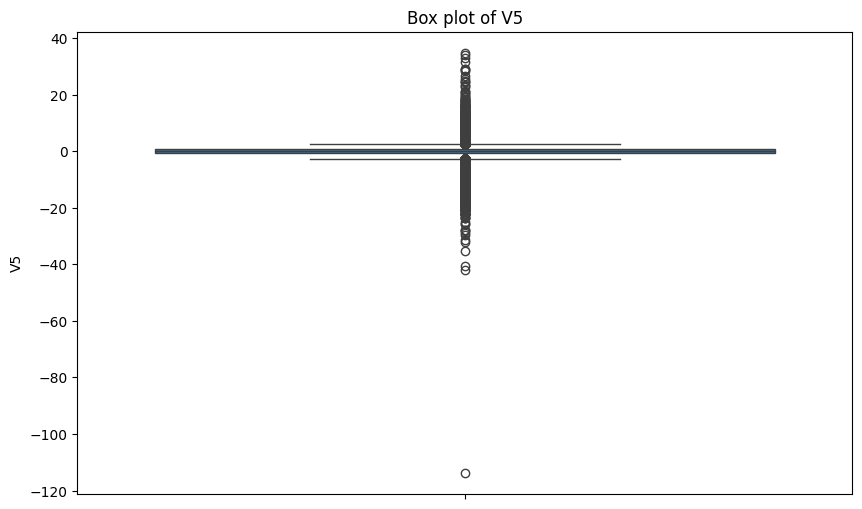

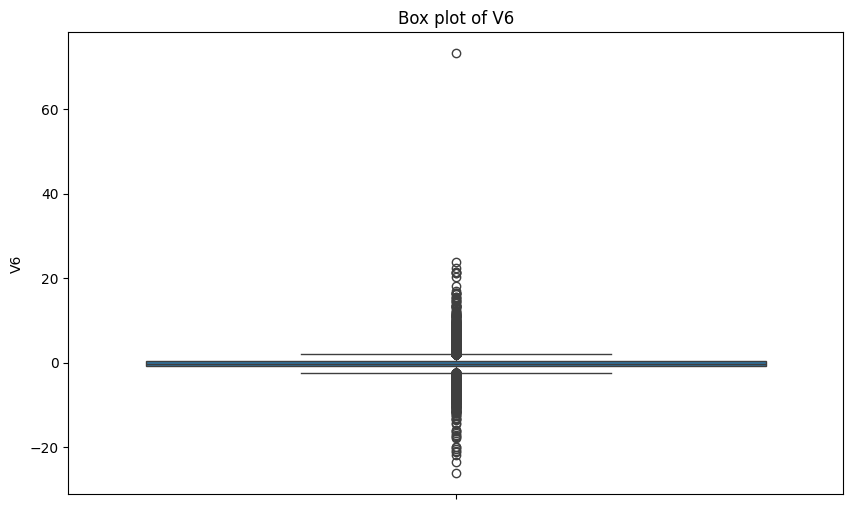

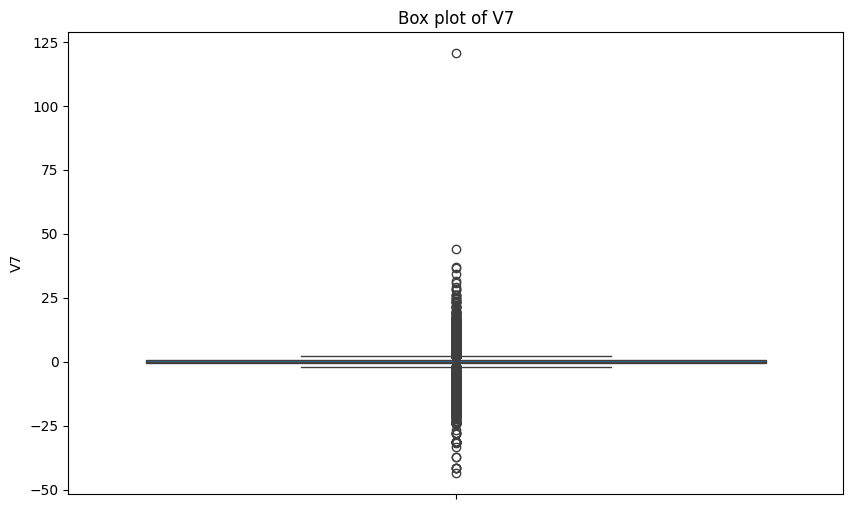

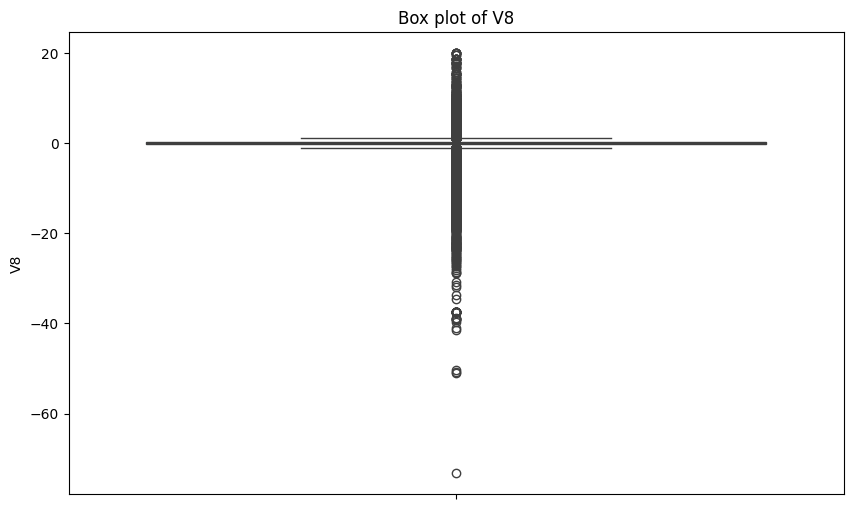

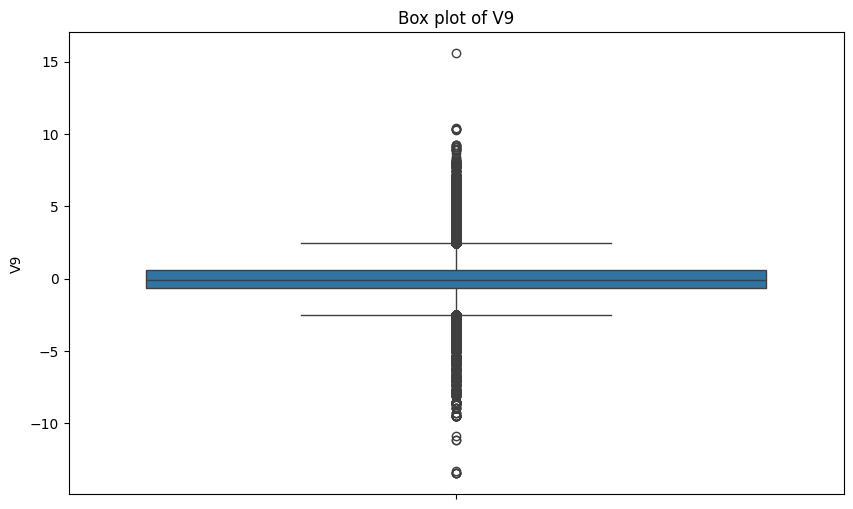

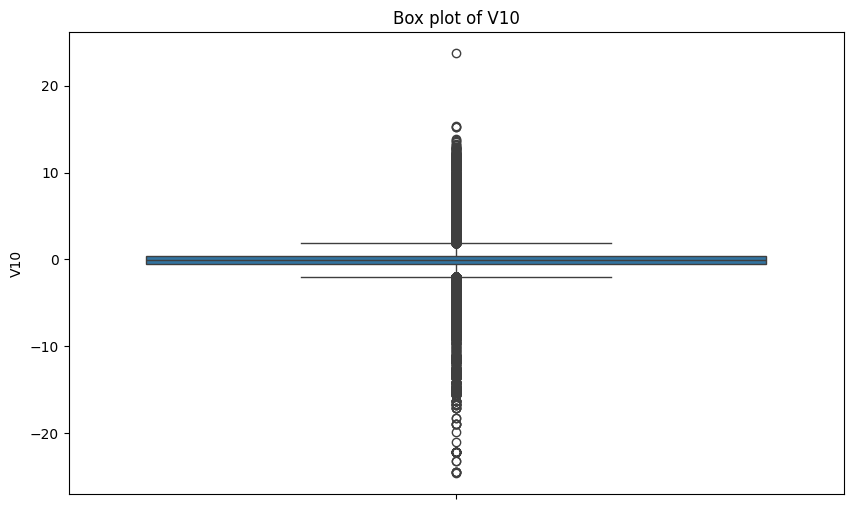

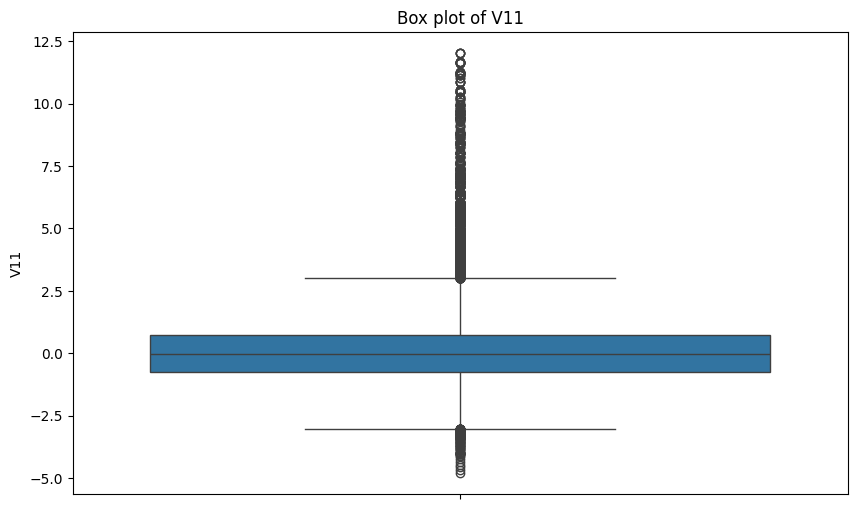

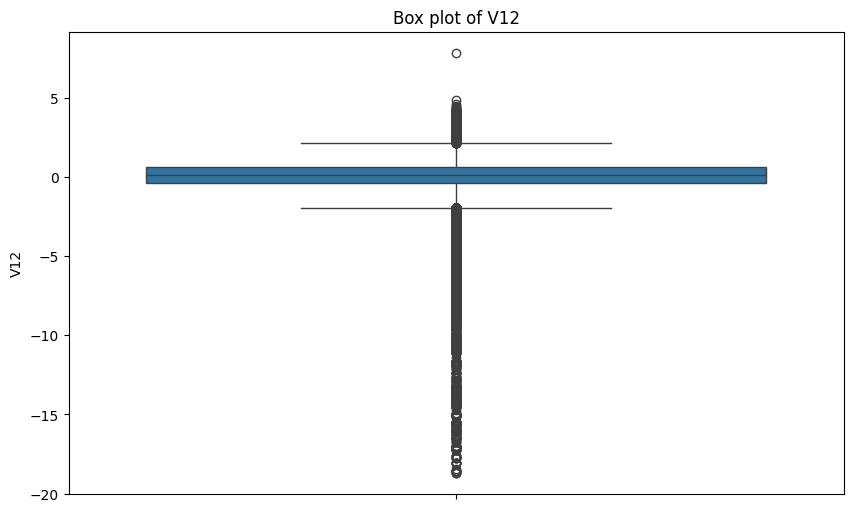

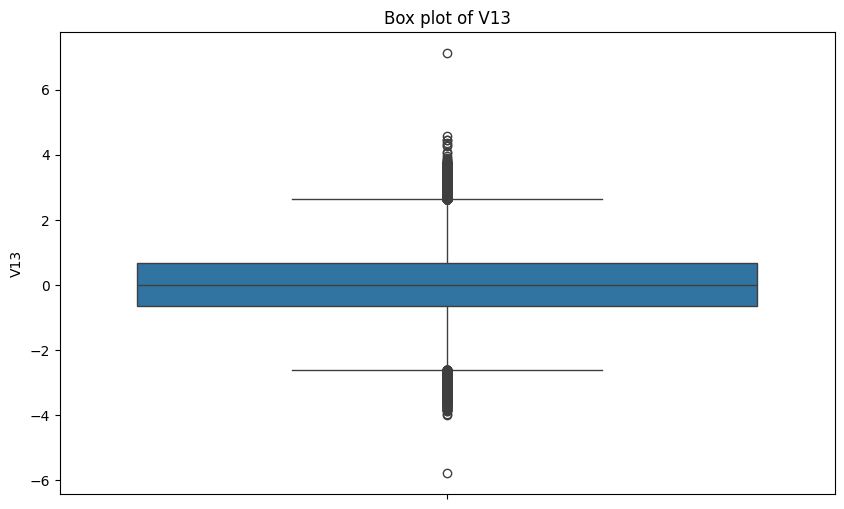

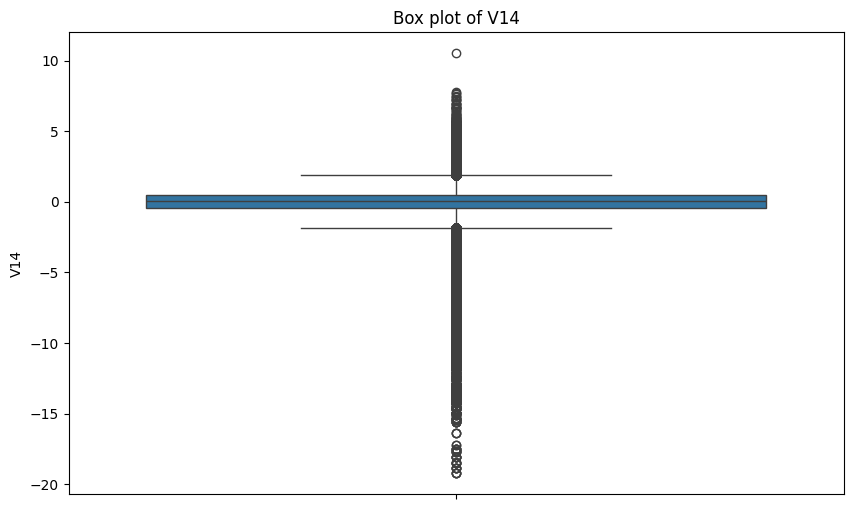

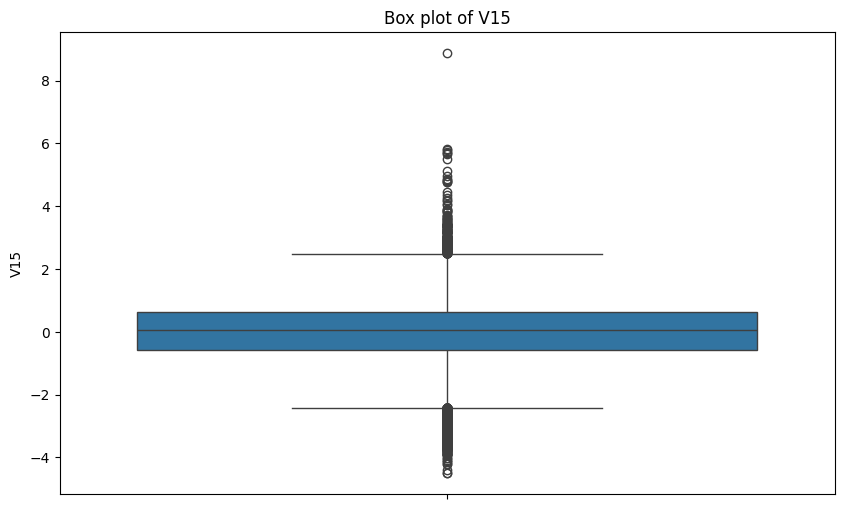

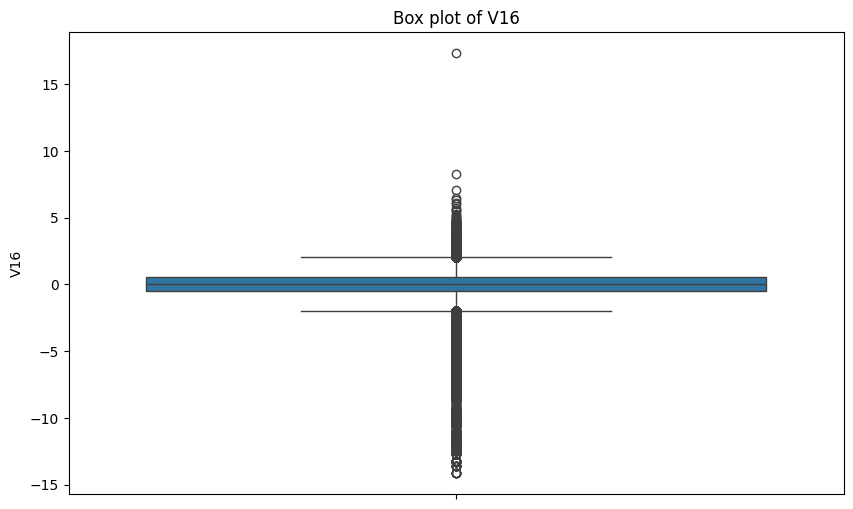

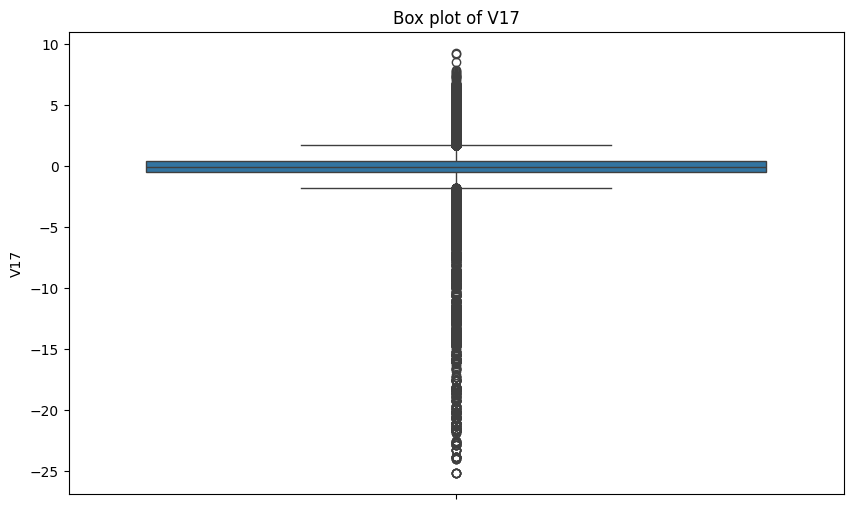

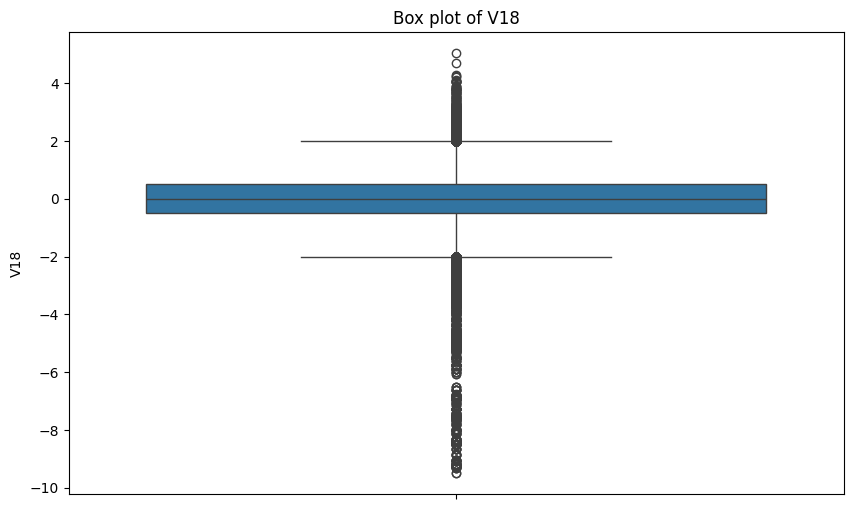

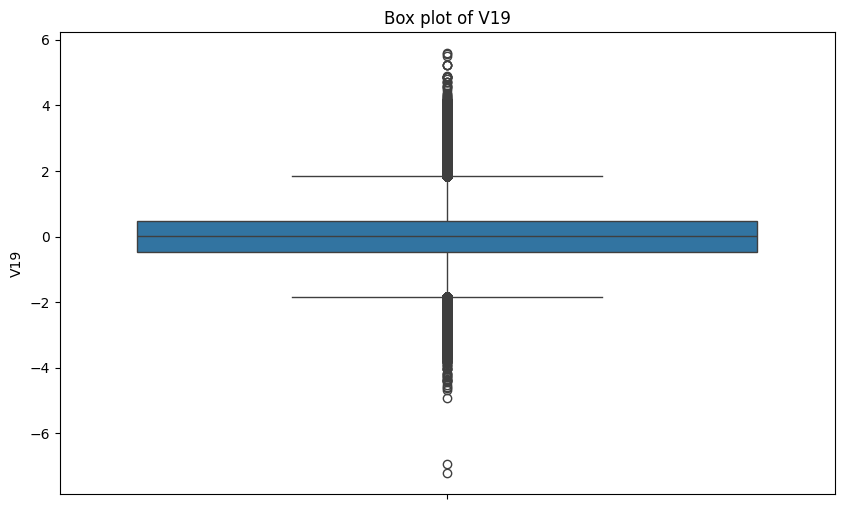

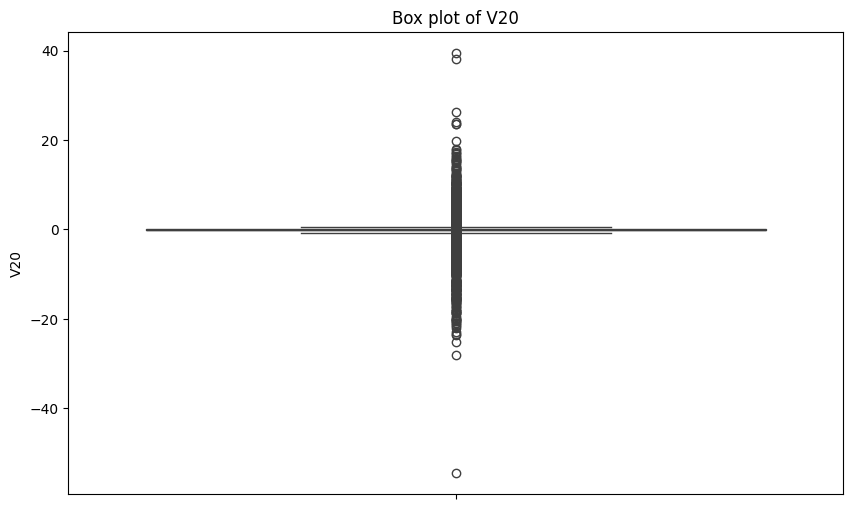

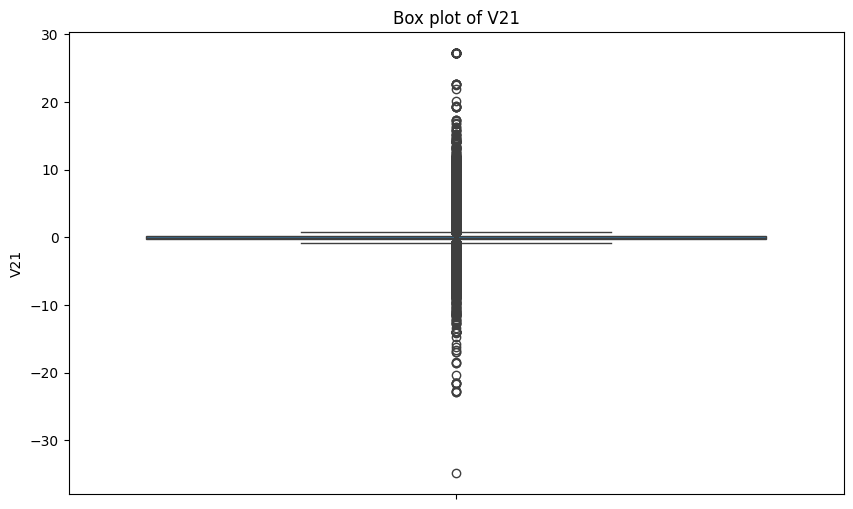

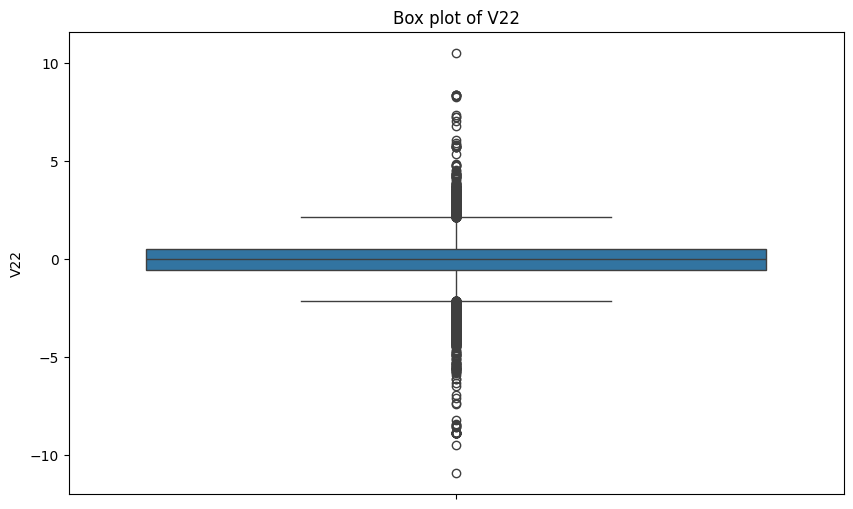

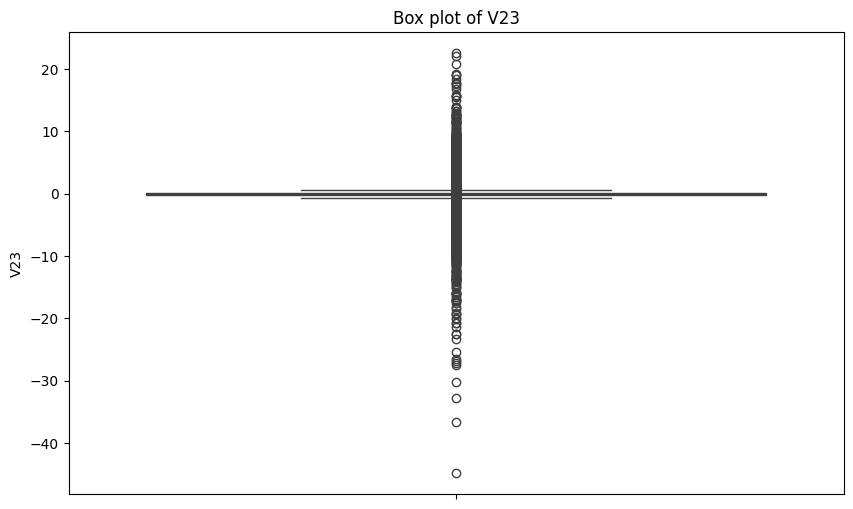

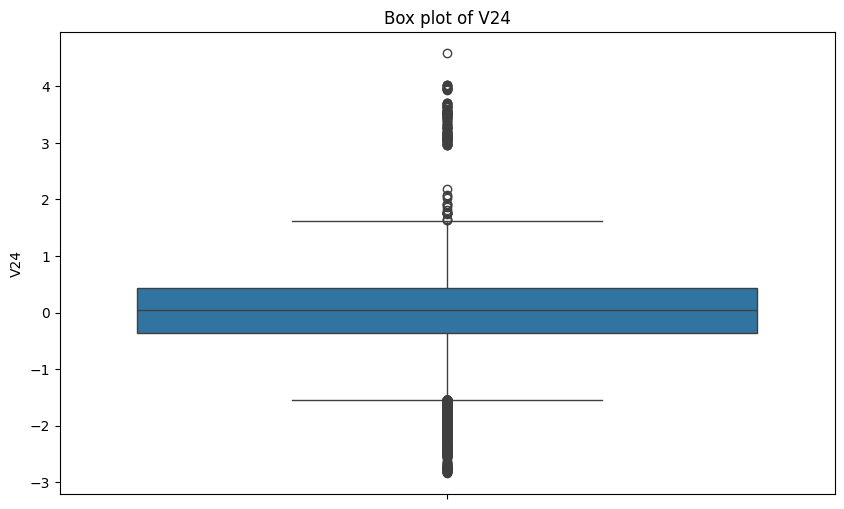

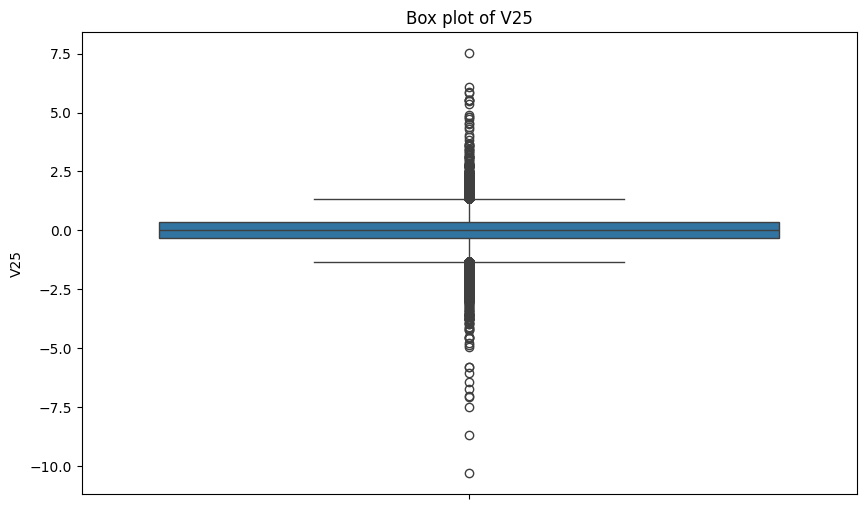

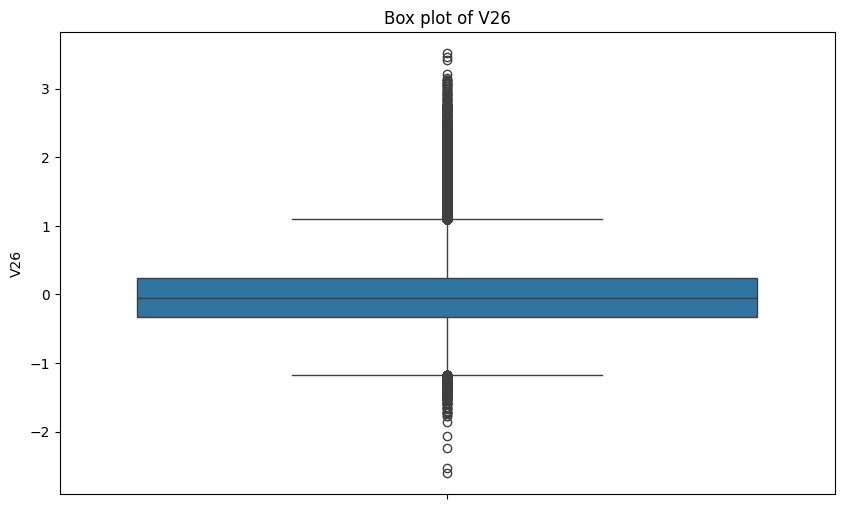

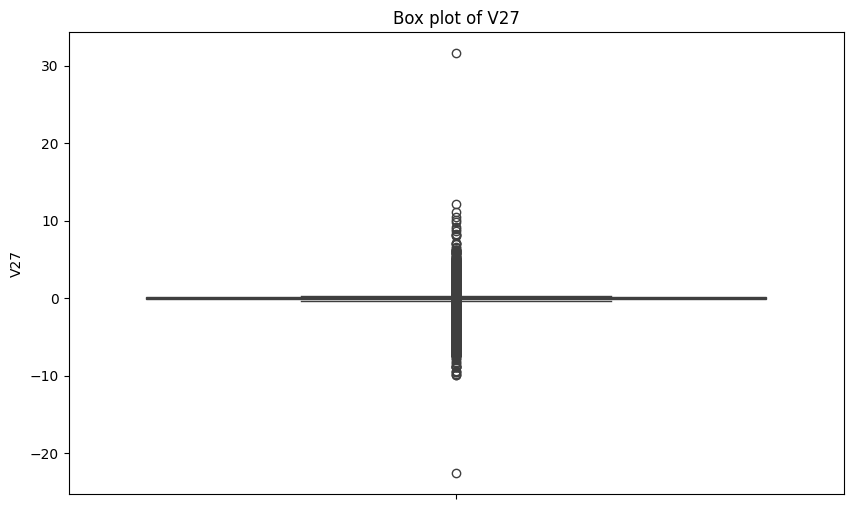

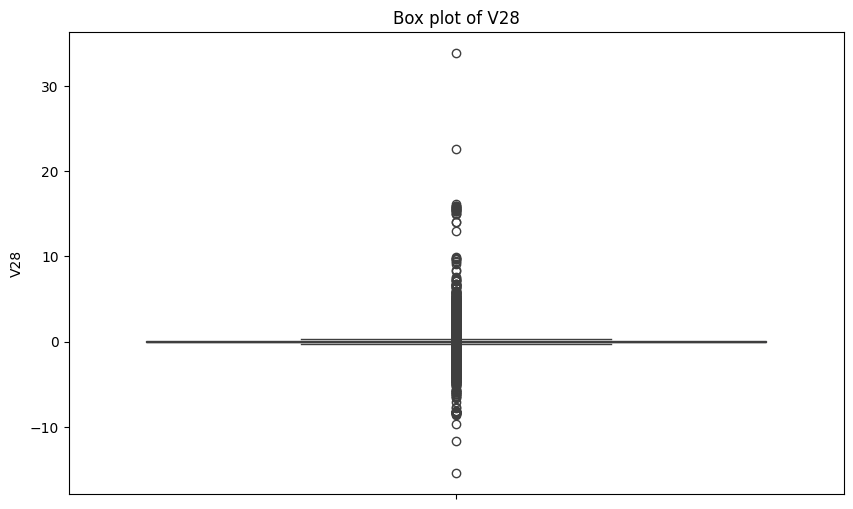

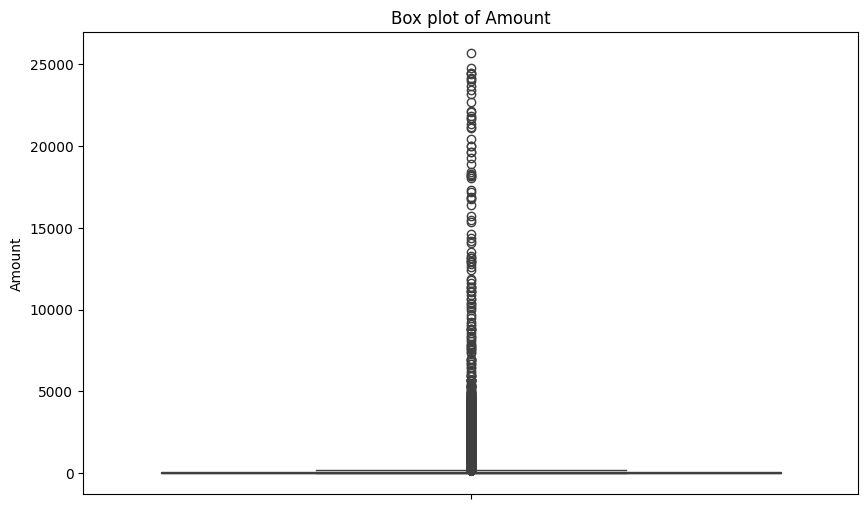

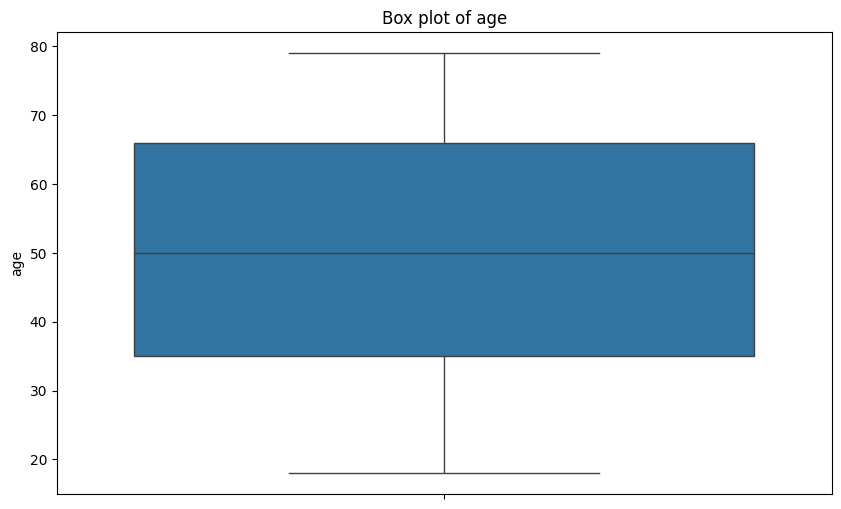

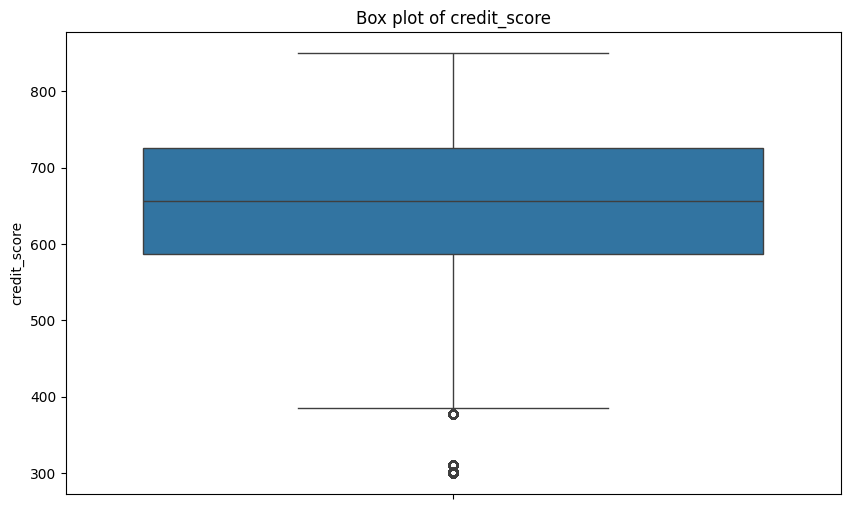

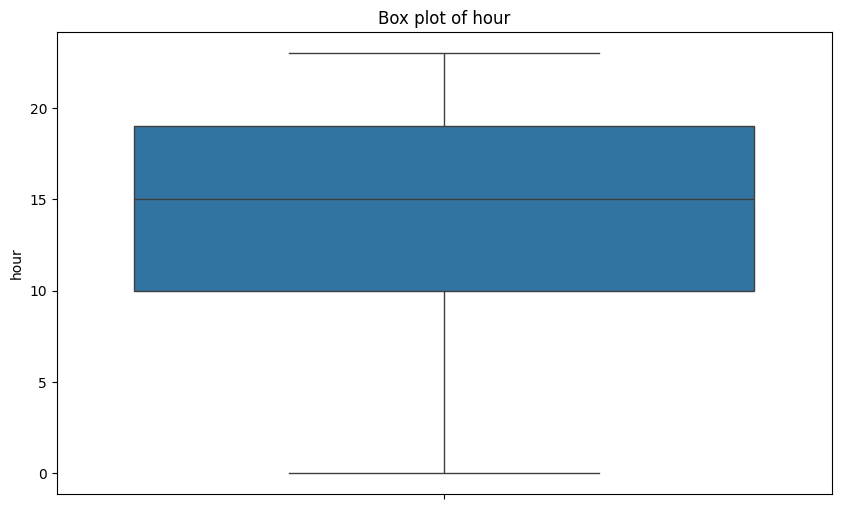

In [33]:
for col in numeric_df:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, y=col)
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
    plt.show()


Analysis for column: V1

Descriptive statistics:


count    286315.000000
mean         -0.024166
std           2.033031
min         -56.407510
25%          -0.929272
50%           0.009518
75%           1.313364
max           2.454930
Name: V1, dtype: float64

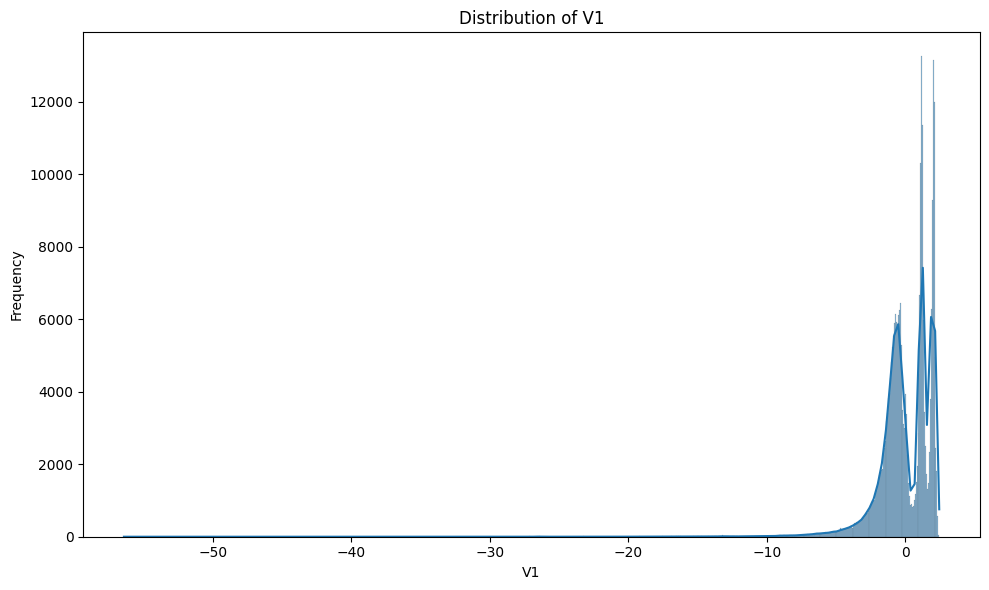

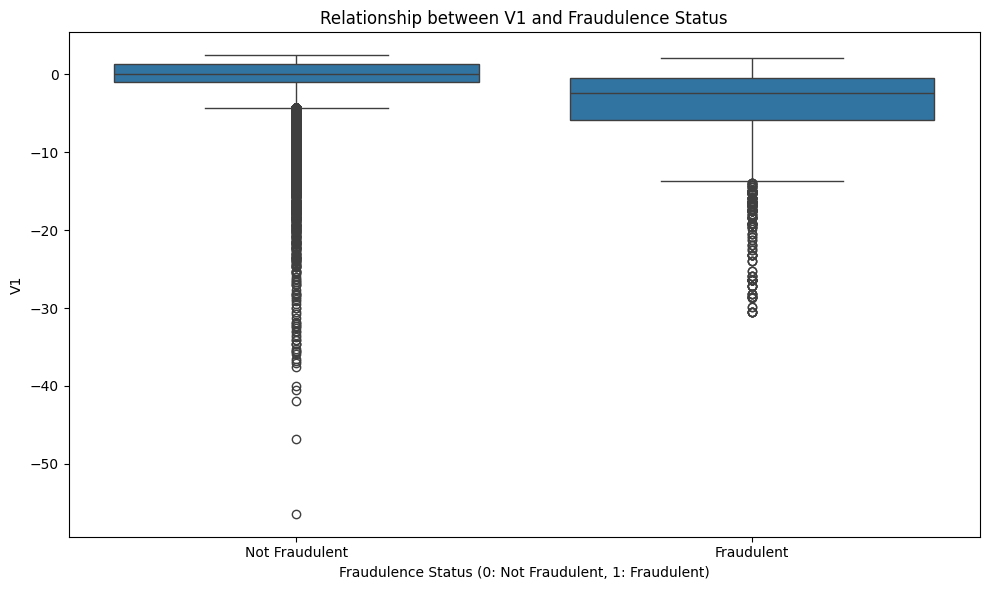


Analysis for column: V2

Descriptive statistics:


count    286315.000000
mean          0.018155
std           1.691744
min         -72.715728
25%          -0.595493
50%           0.070189
75%           0.813354
max          22.057729
Name: V2, dtype: float64

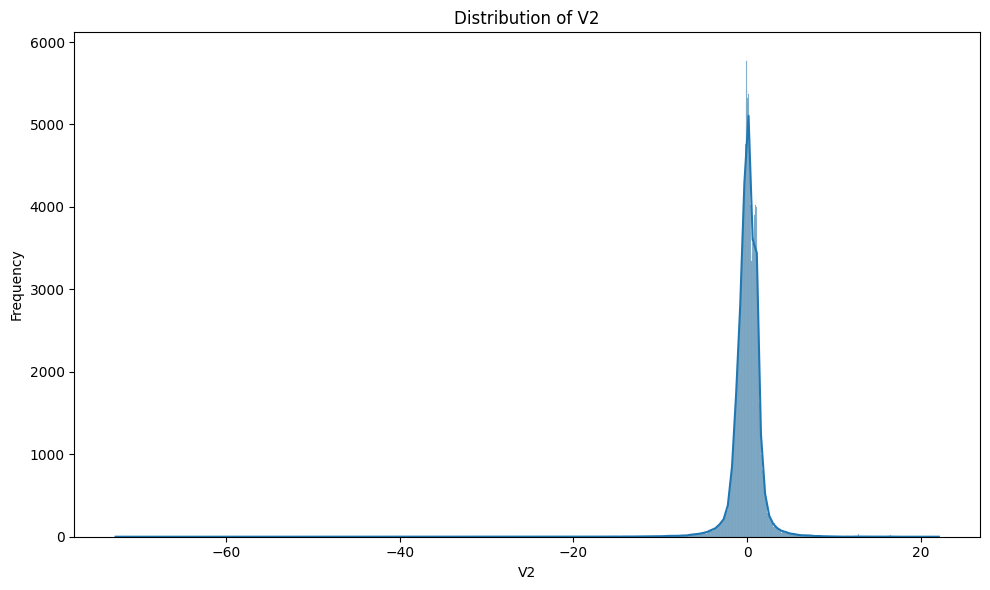

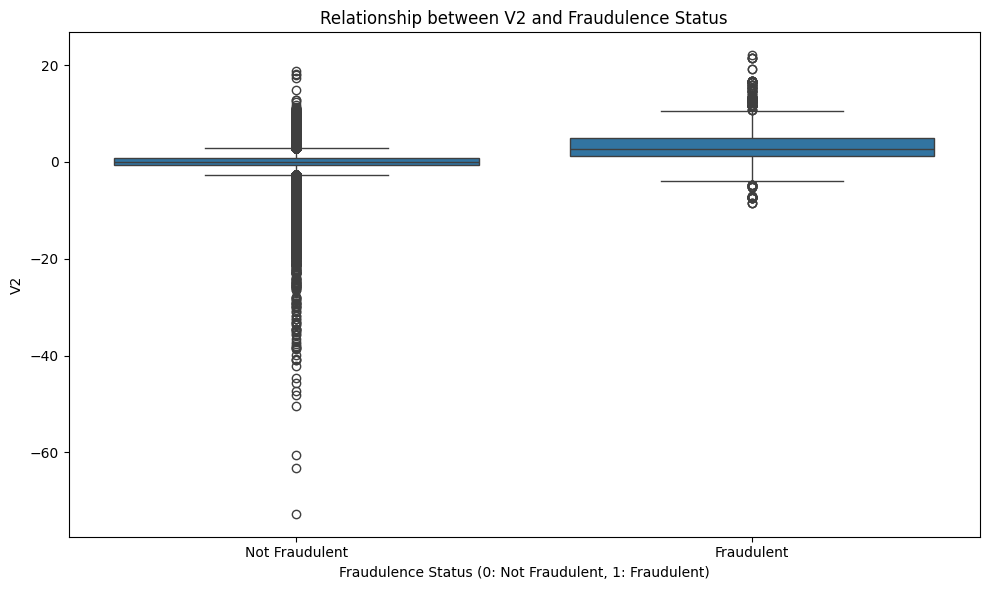


Analysis for column: V3

Descriptive statistics:


count    286315.000000
mean         -0.035505
std           1.664057
min         -48.325589
25%          -0.907409
50%           0.172793
75%           1.023179
max           9.382558
Name: V3, dtype: float64

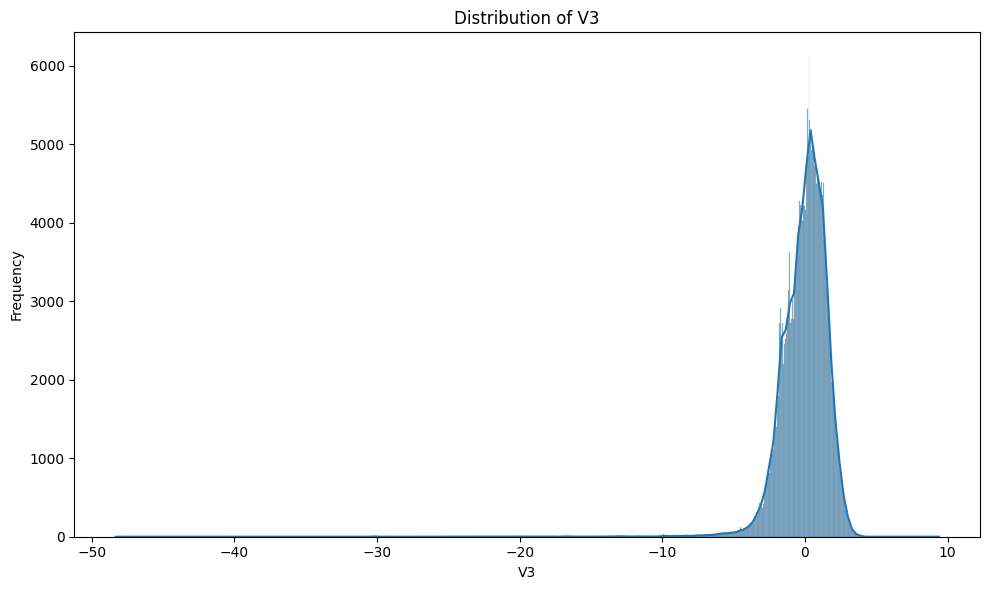

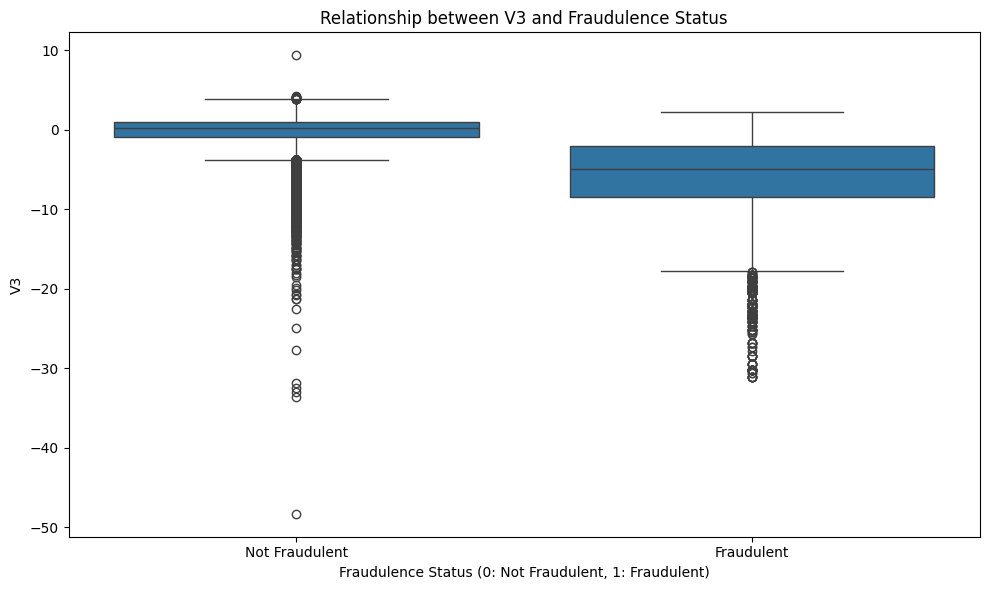


Analysis for column: V4

Descriptive statistics:


count    286315.000000
mean          0.023738
std           1.465026
min          -5.683171
25%          -0.843786
50%          -0.011537
75%           0.759227
max          16.875344
Name: V4, dtype: float64

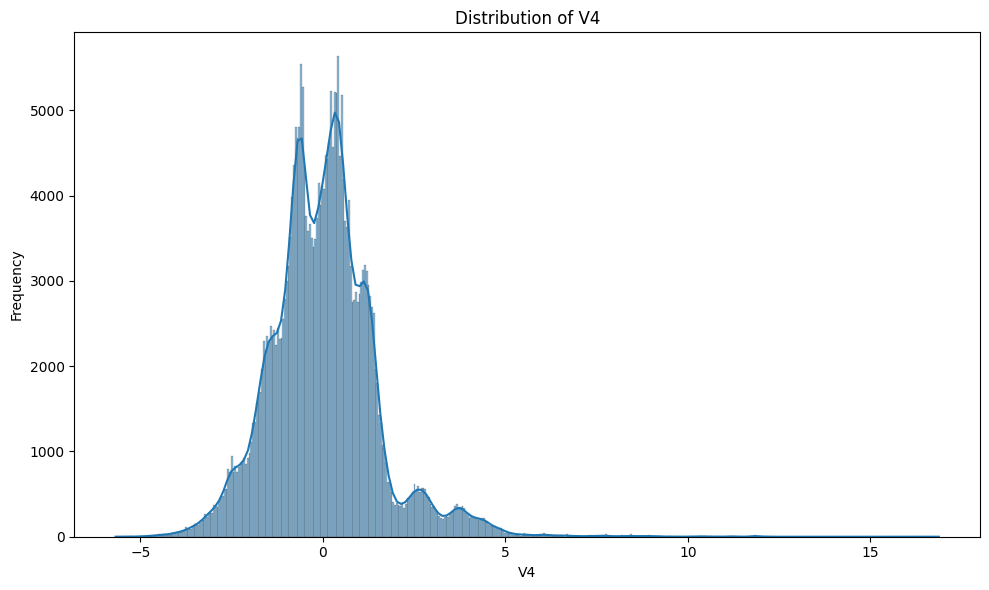

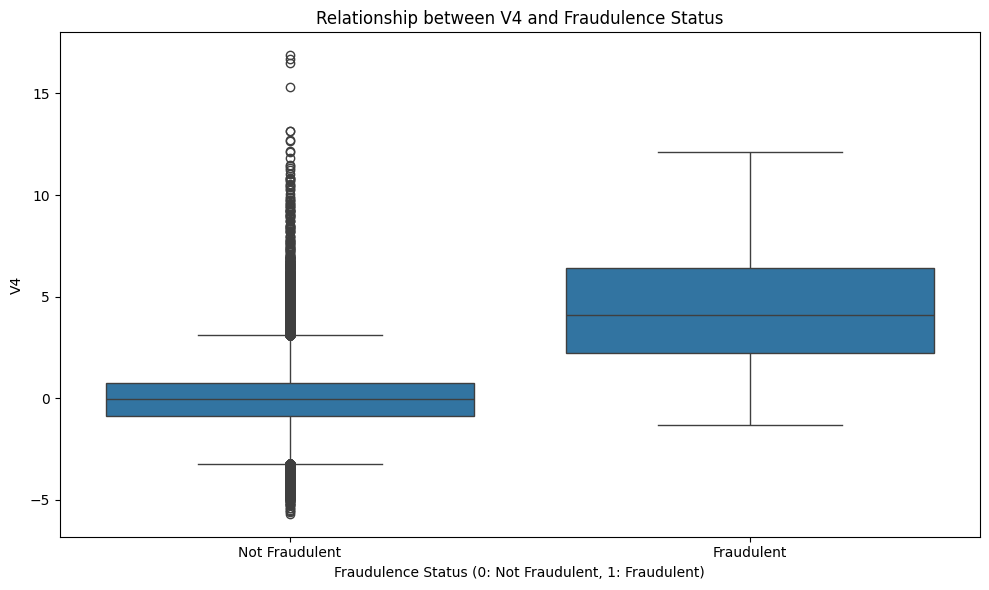


Analysis for column: V5

Descriptive statistics:


count    286315.000000
mean         -0.015496
std           1.440135
min        -113.743307
25%          -0.697608
50%          -0.057173
75%           0.610778
max          34.801666
Name: V5, dtype: float64

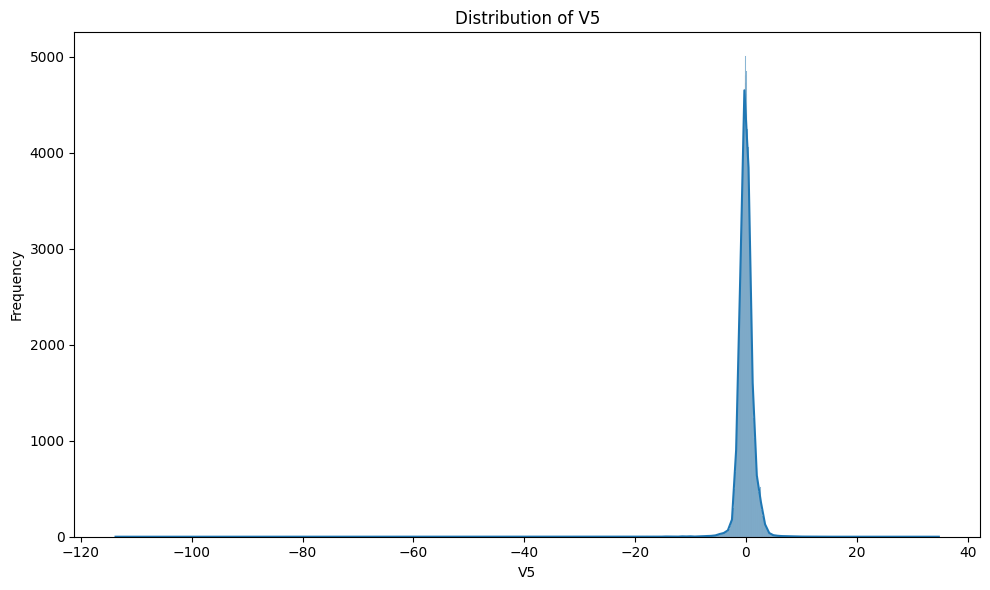

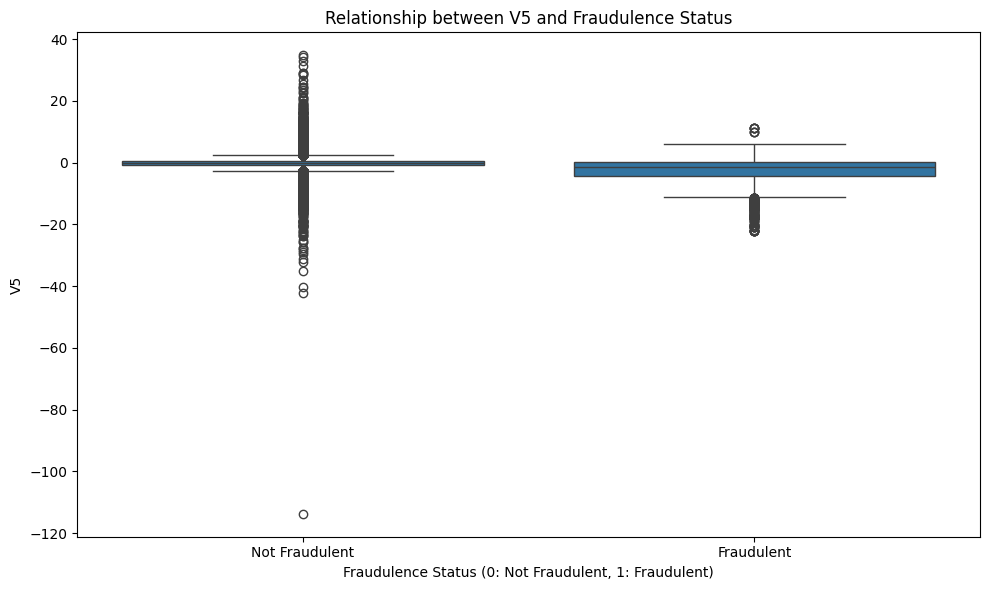


Analysis for column: V6

Descriptive statistics:


count    286315.000000
mean         -0.006939
std           1.338852
min         -26.160506
25%          -0.772949
50%          -0.277219
75%           0.395847
max          73.301626
Name: V6, dtype: float64

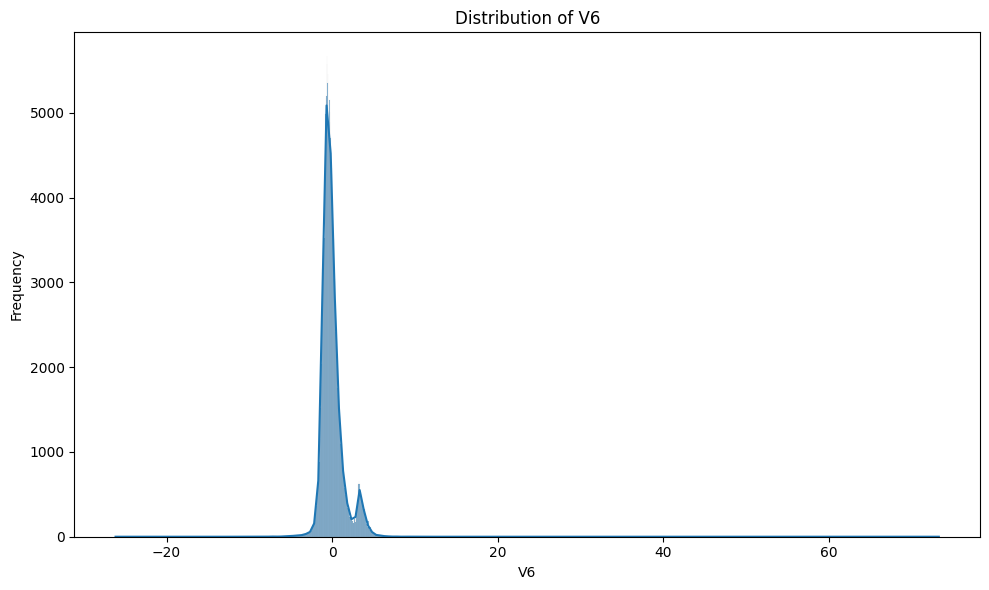

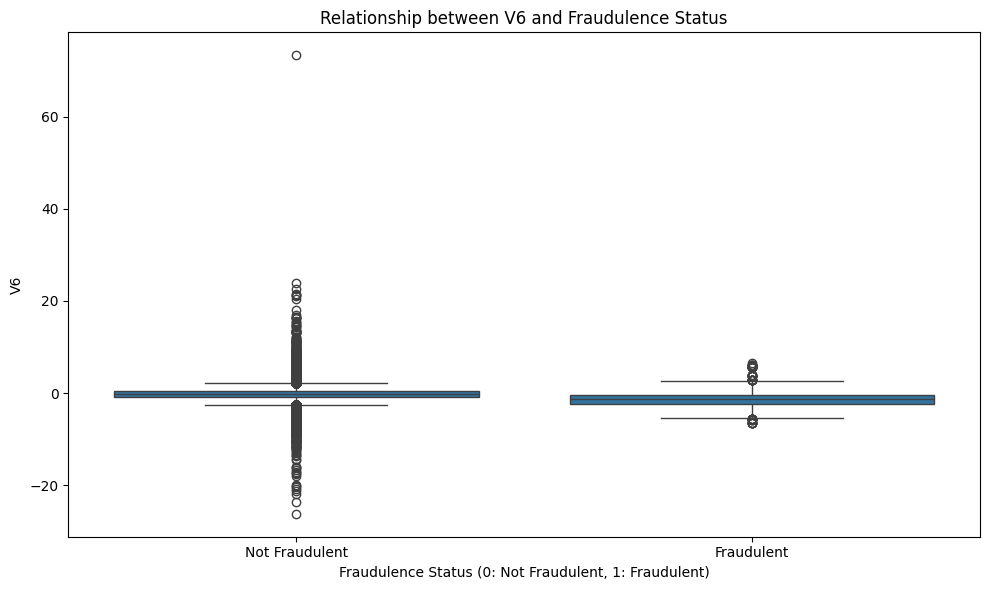


Analysis for column: V7

Descriptive statistics:


count    286315.000000
mean         -0.028154
std           1.383856
min         -43.557242
25%          -0.560981
50%           0.037005
75%           0.568421
max         120.589494
Name: V7, dtype: float64

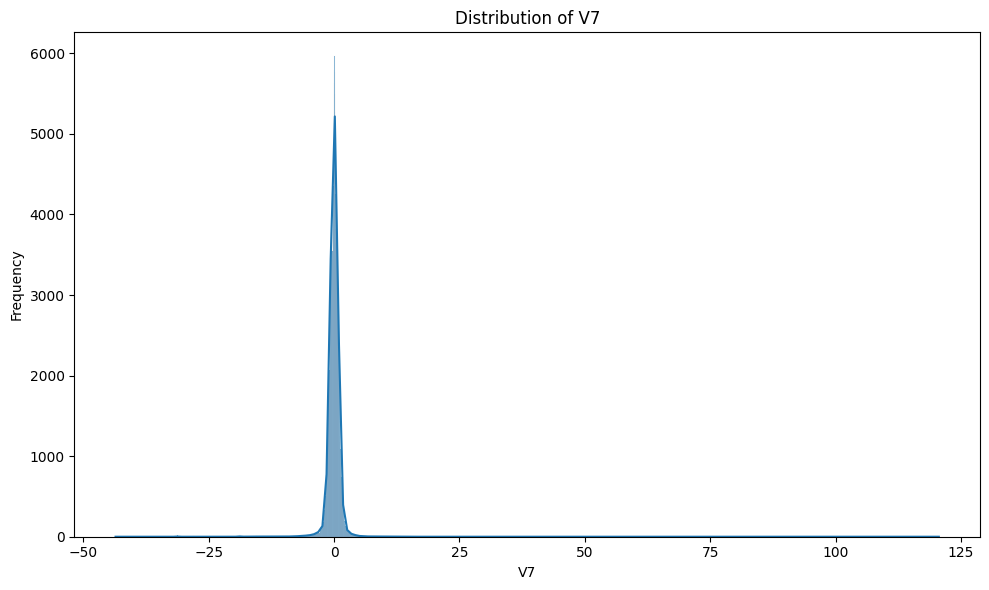

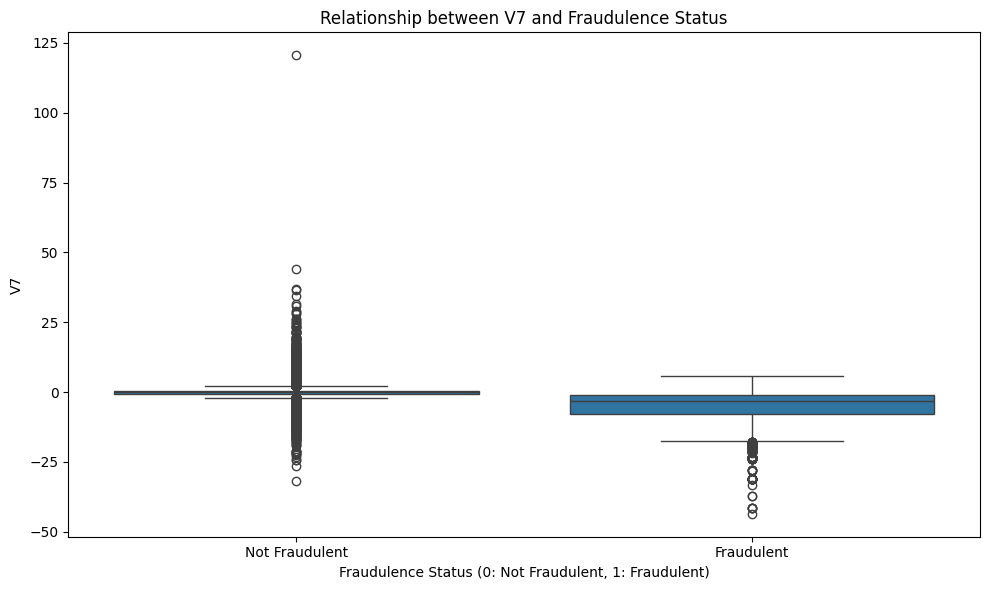


Analysis for column: V8

Descriptive statistics:


count    286315.000000
mean          0.001809
std           1.285448
min         -73.216718
25%          -0.208711
50%           0.023150
75%           0.330601
max          20.007208
Name: V8, dtype: float64

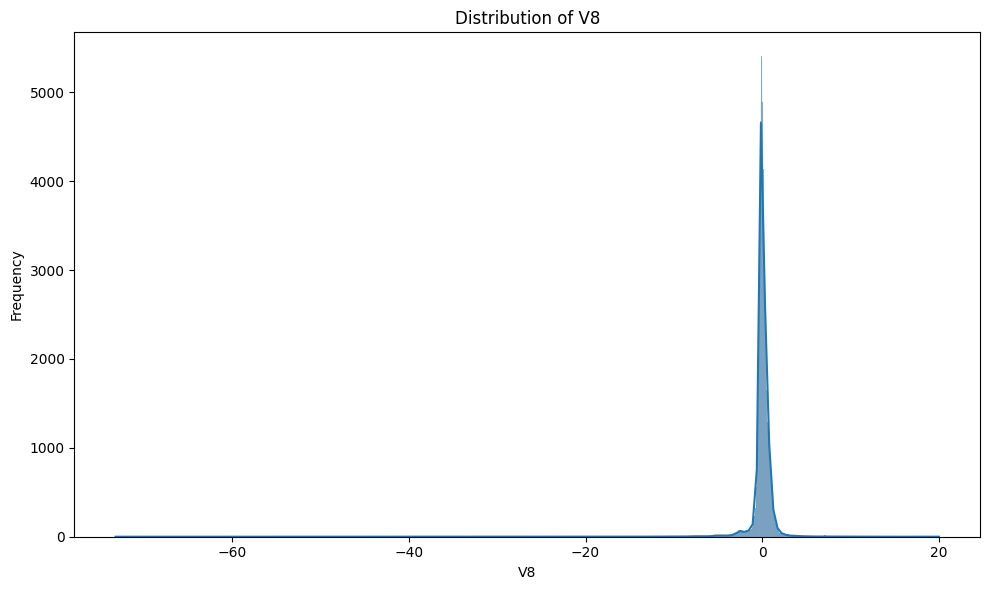

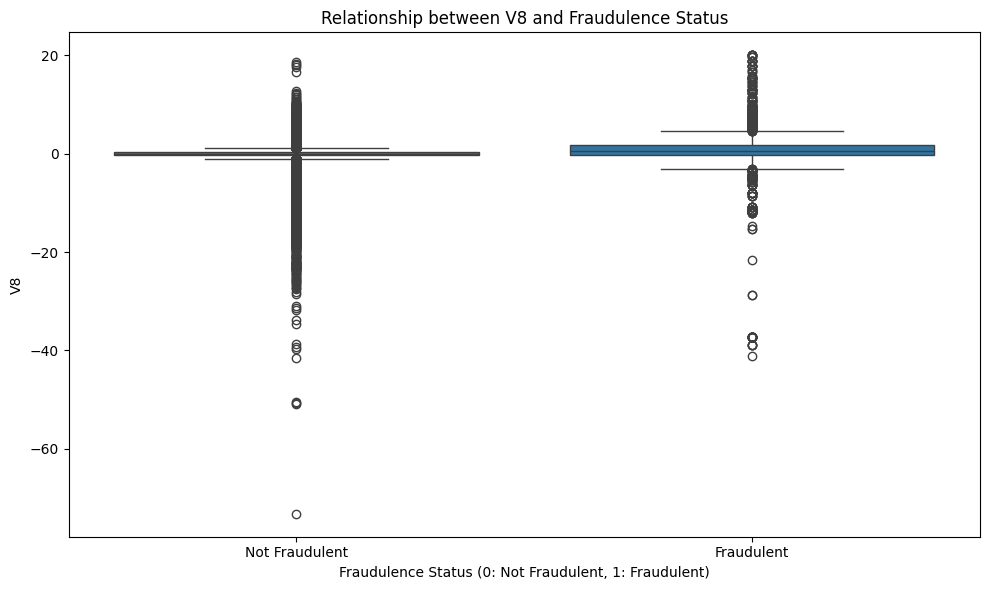


Analysis for column: V9

Descriptive statistics:


count    286315.000000
mean         -0.013087
std           1.124924
min         -13.434066
25%          -0.651328
50%          -0.054419
75%           0.594028
max          15.594995
Name: V9, dtype: float64

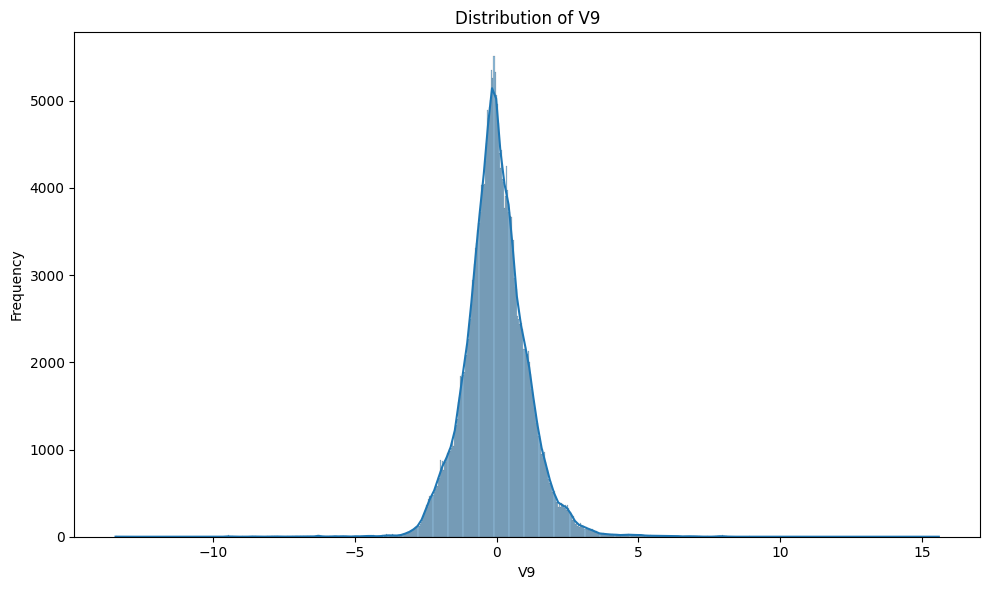

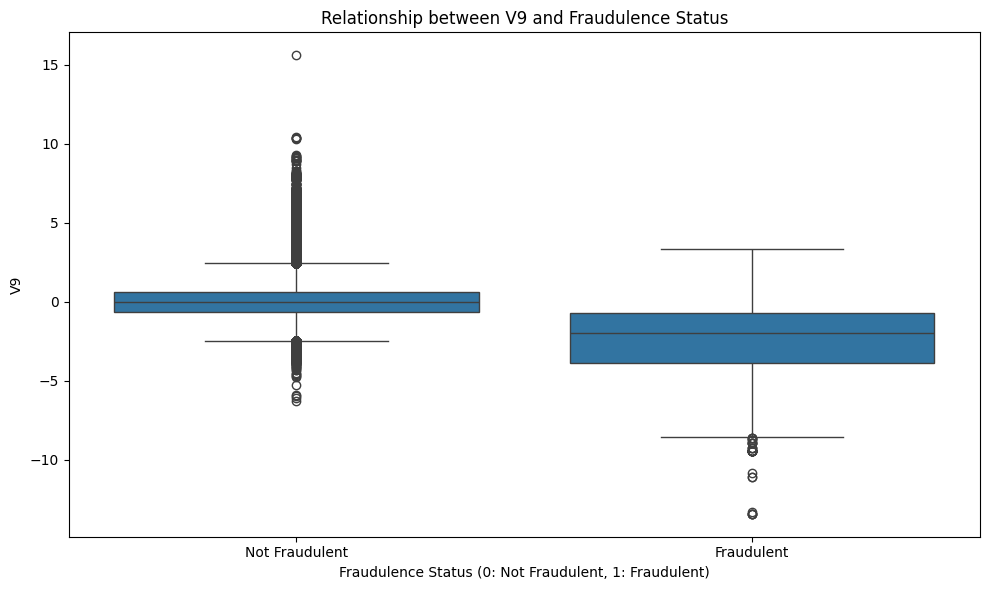


Analysis for column: V10

Descriptive statistics:


count    286315.000000
mean         -0.029173
std           1.209545
min         -24.588262
25%          -0.542040
50%          -0.096187
75%           0.449688
max          23.745136
Name: V10, dtype: float64

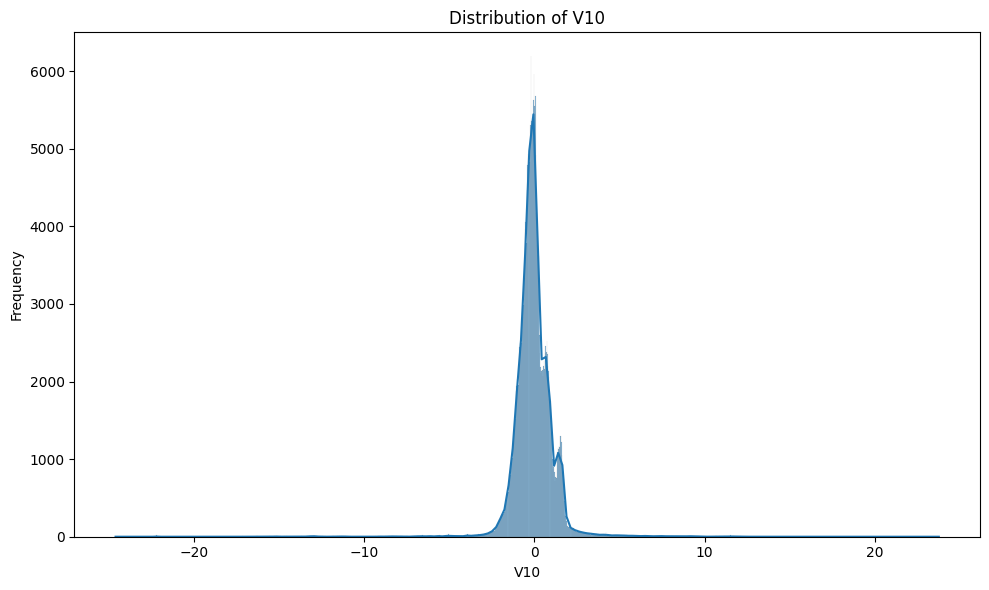

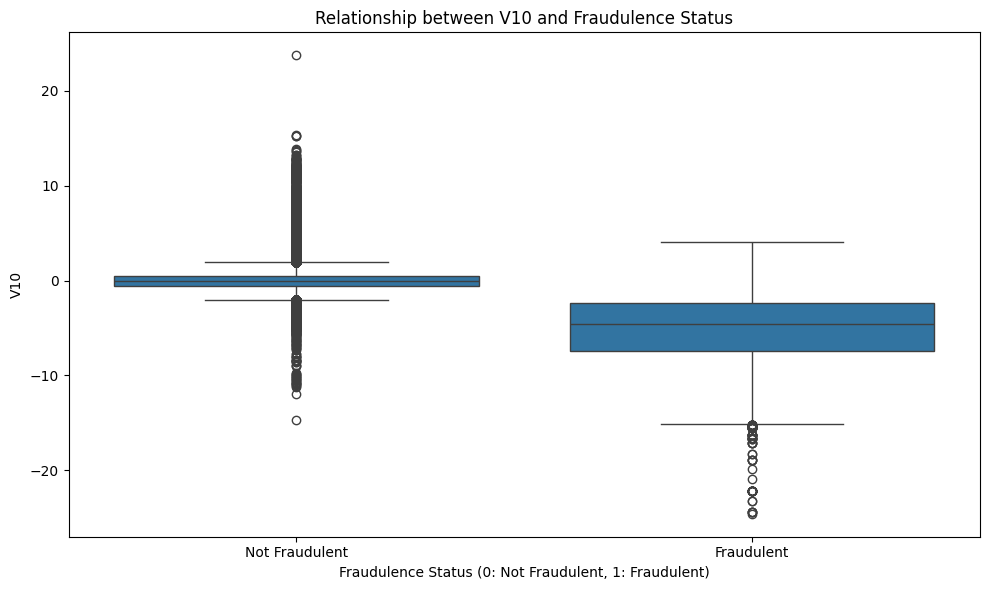


Analysis for column: V11

Descriptive statistics:


count    286315.000000
mean          0.020162
std           1.073409
min          -4.797473
25%          -0.759153
50%          -0.026350
75%           0.750812
max          12.018913
Name: V11, dtype: float64

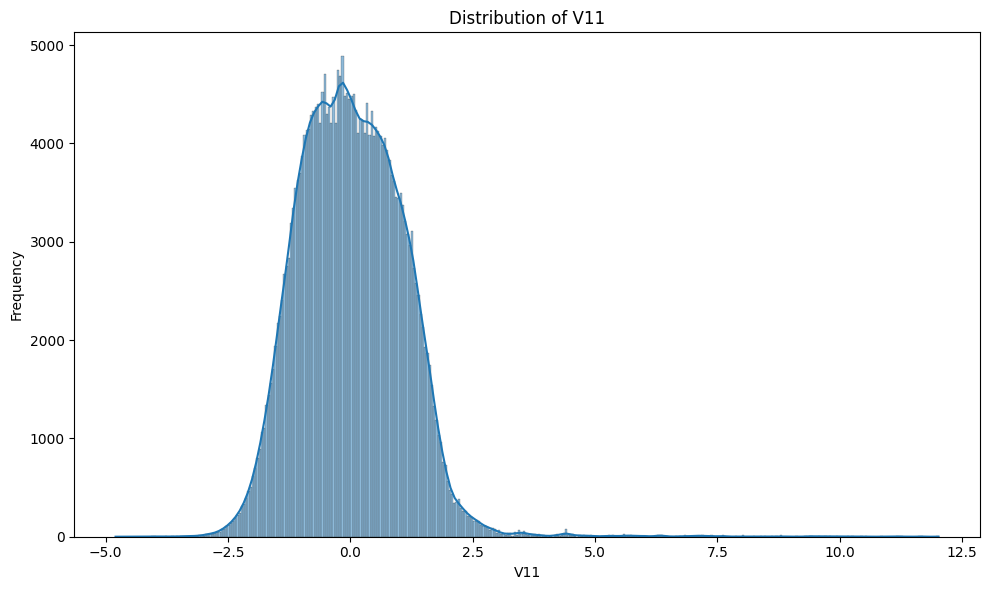

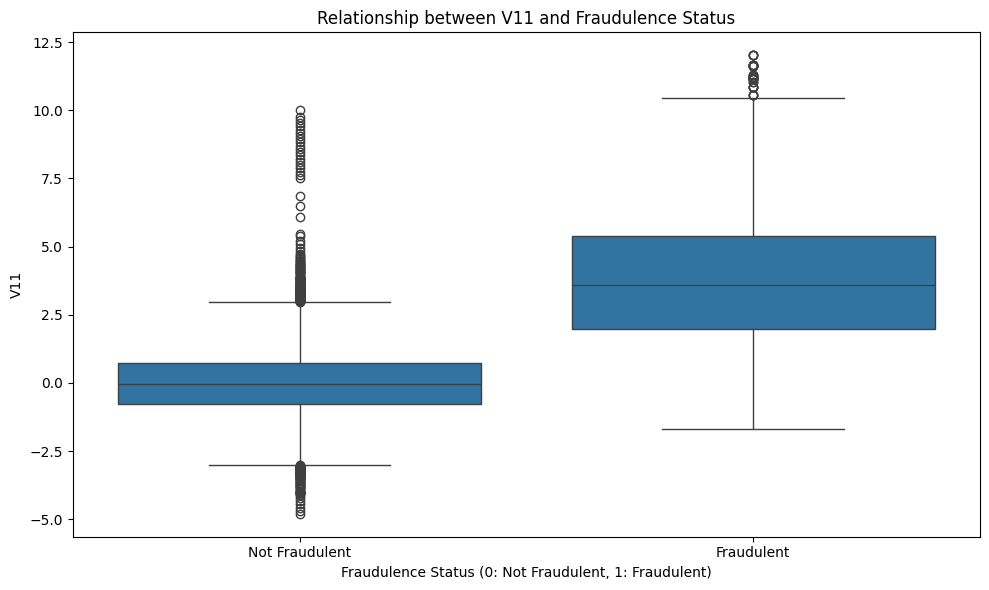


Analysis for column: V12

Descriptive statistics:


count    286315.000000
mean         -0.033073
std           1.147903
min         -18.683715
25%          -0.415203
50%           0.135297
75%           0.615625
max           7.848392
Name: V12, dtype: float64

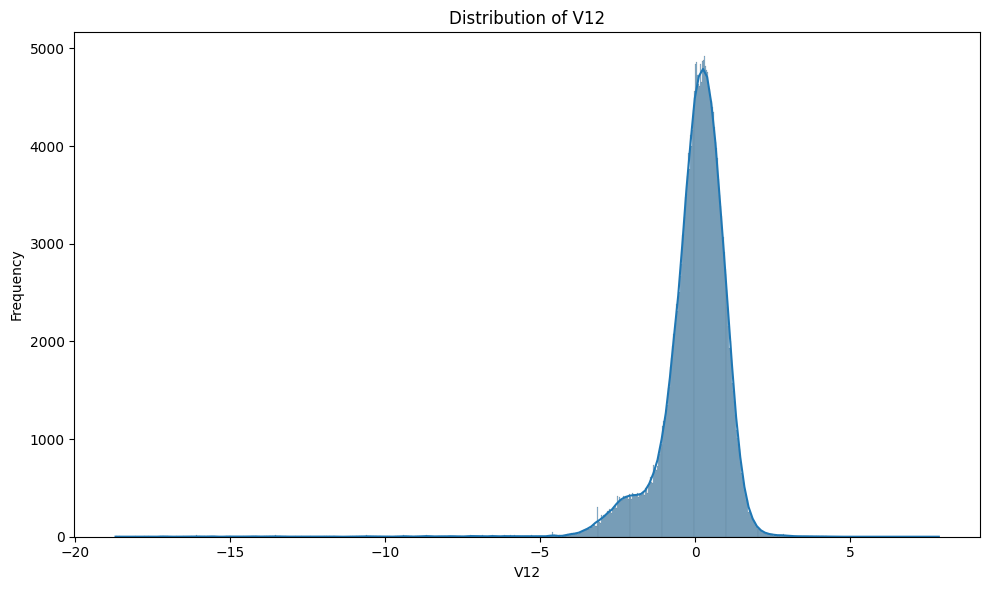

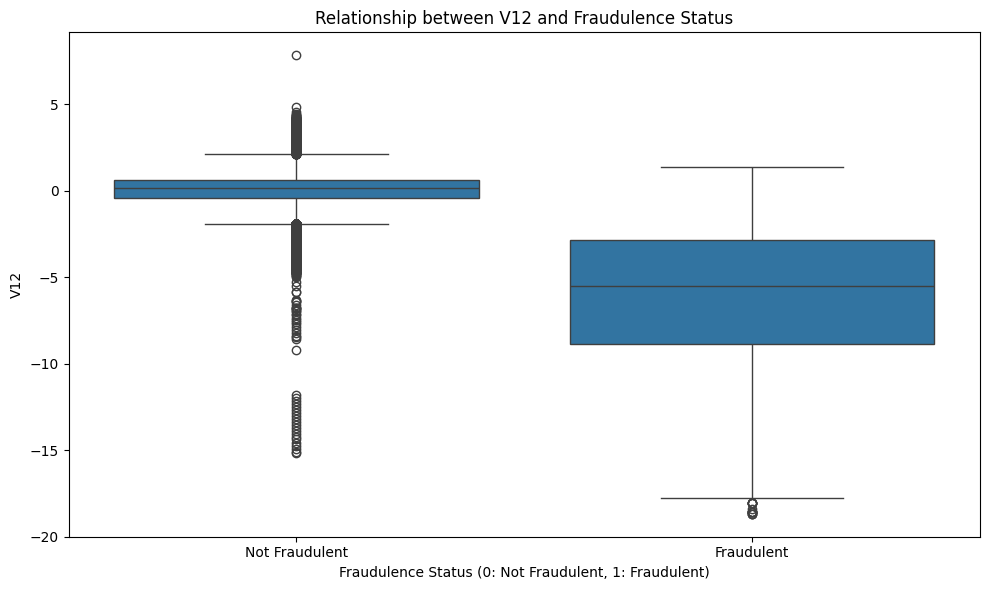


Analysis for column: V13

Descriptive statistics:


count    286315.000000
mean         -0.000300
std           0.996100
min          -5.791881
25%          -0.649853
50%          -0.013547
75%           0.663103
max           7.126883
Name: V13, dtype: float64

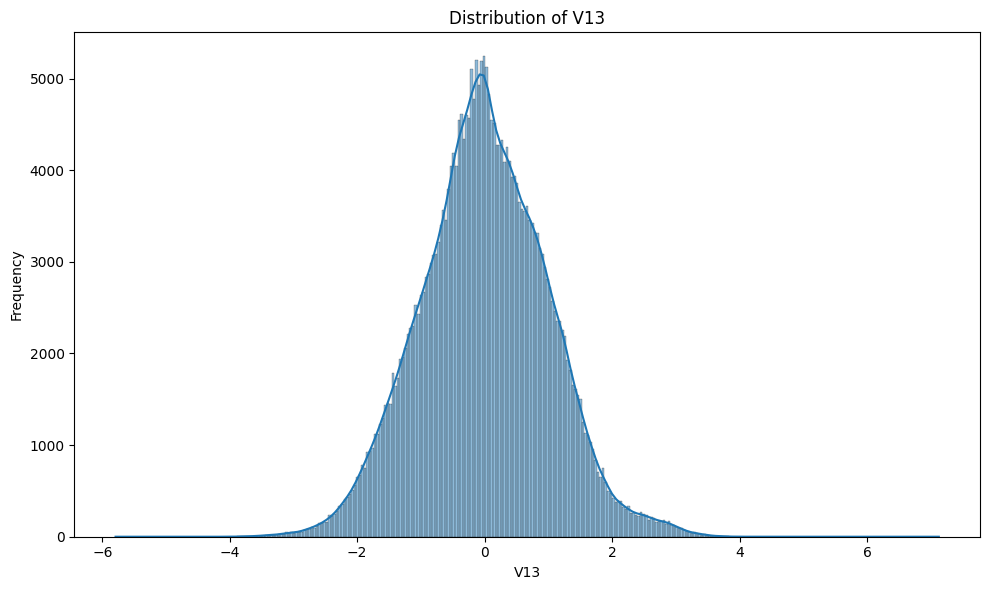

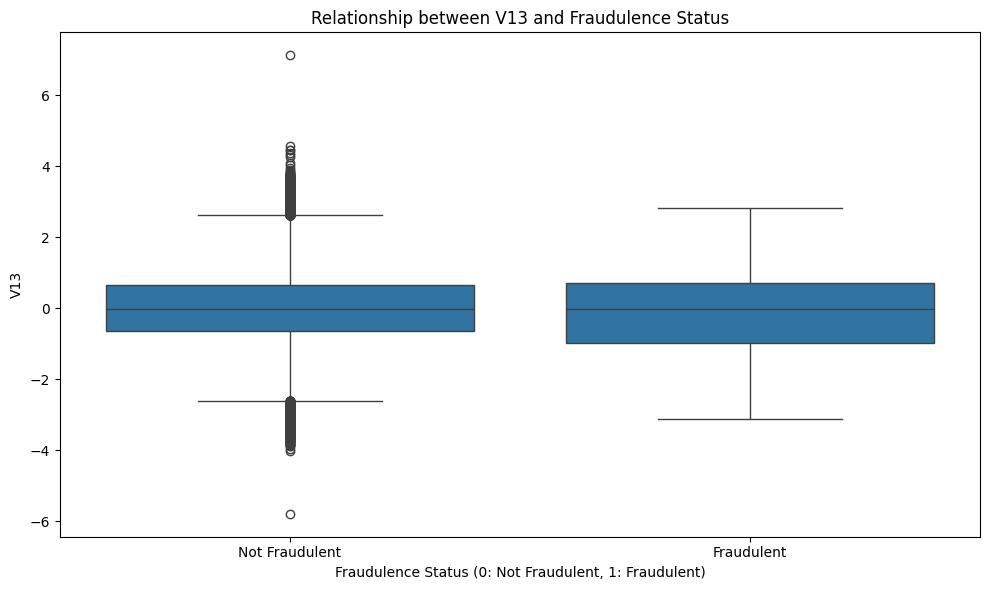


Analysis for column: V14

Descriptive statistics:


count    286315.000000
mean         -0.037293
std           1.130031
min         -19.214325
25%          -0.434084
50%           0.046862
75%           0.490590
max          10.526766
Name: V14, dtype: float64

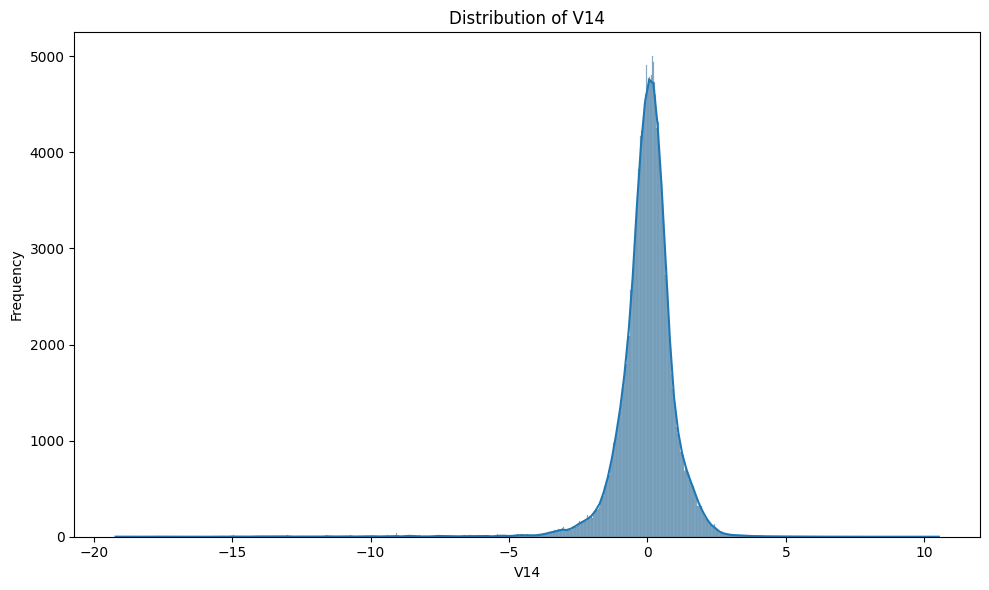

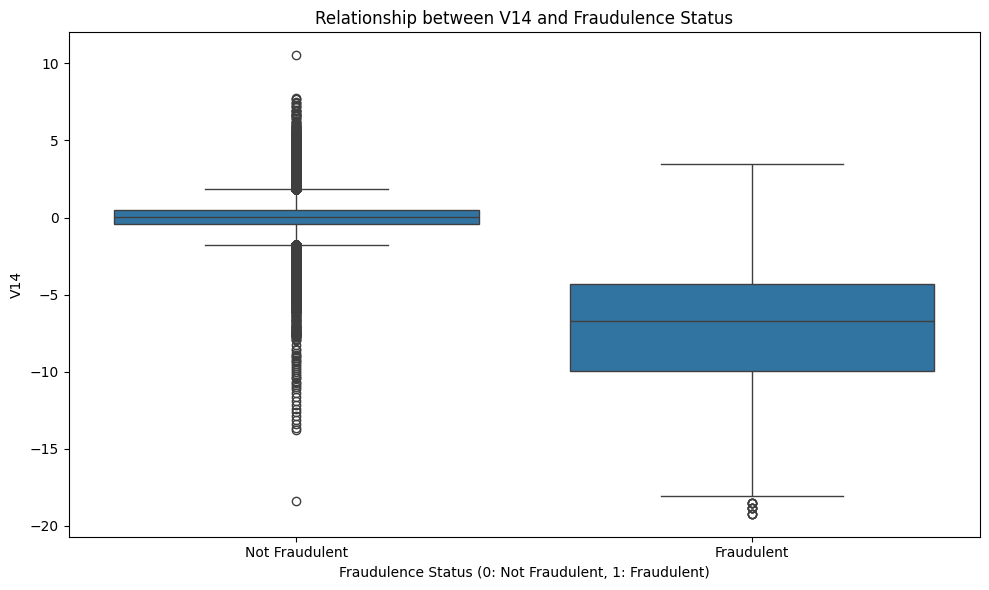


Analysis for column: V15

Descriptive statistics:


count    286315.000000
mean         -0.000430
std           0.915988
min          -4.498945
25%          -0.582884
50%           0.047537
75%           0.648497
max           8.877742
Name: V15, dtype: float64

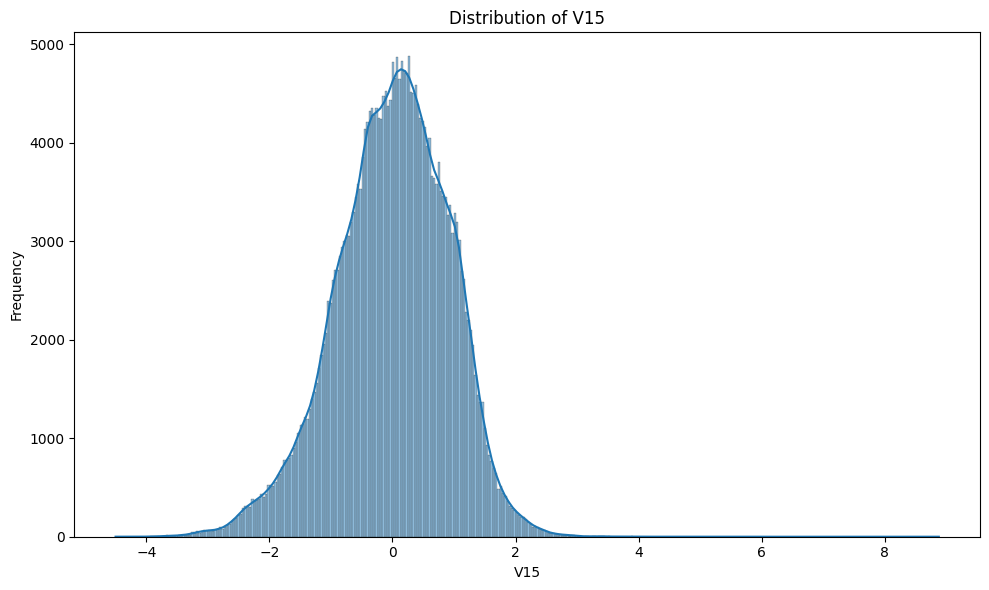

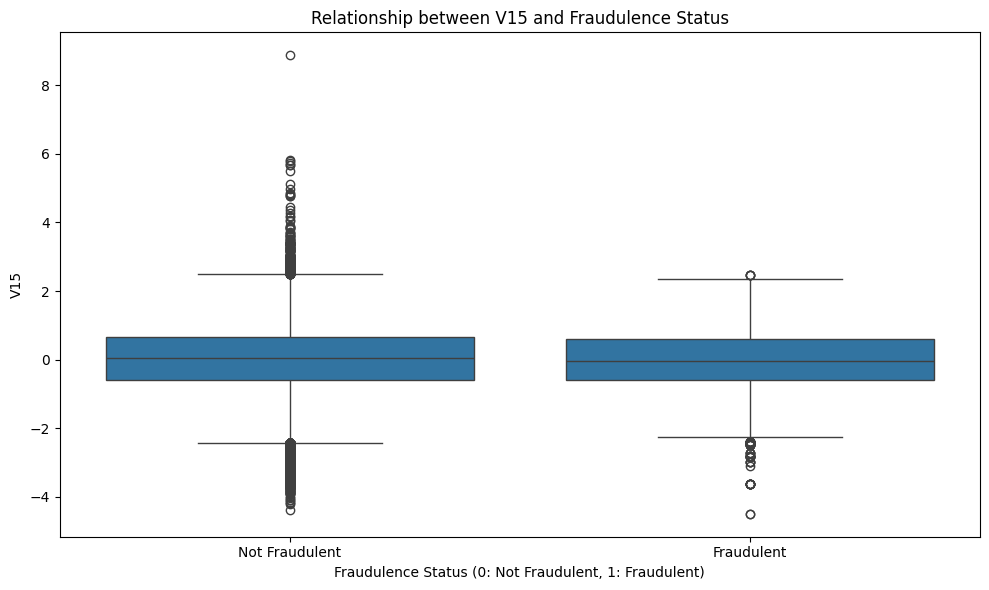


Analysis for column: V16

Descriptive statistics:


count    286315.000000
mean         -0.021966
std           0.967705
min         -14.129855
25%          -0.475833
50%           0.063201
75%           0.521604
max          17.315112
Name: V16, dtype: float64

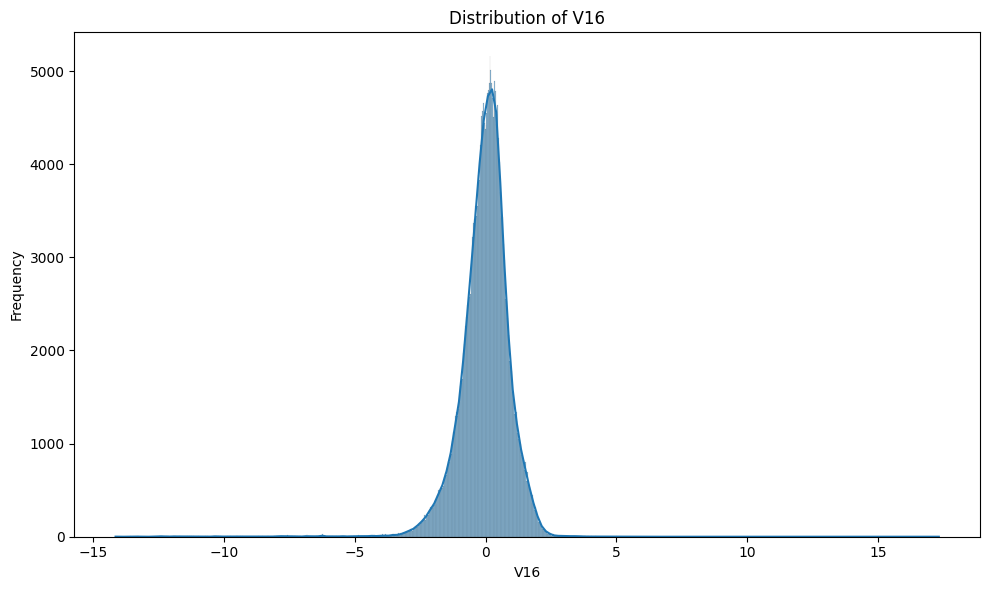

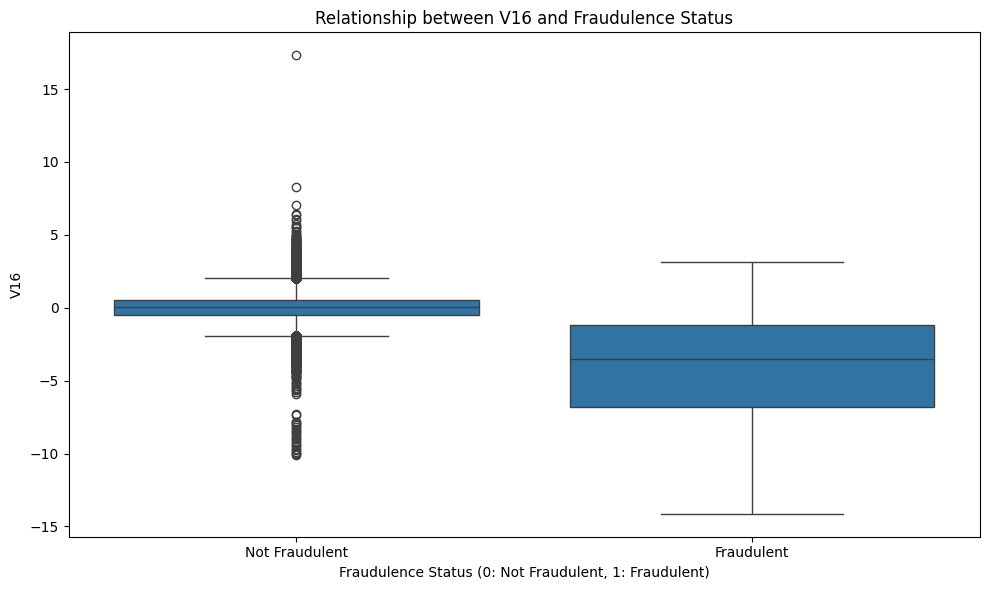


Analysis for column: V17

Descriptive statistics:


count    286315.000000
mean         -0.035151
std           1.100456
min         -25.162799
25%          -0.488649
50%          -0.068371
75%           0.398658
max           9.253526
Name: V17, dtype: float64

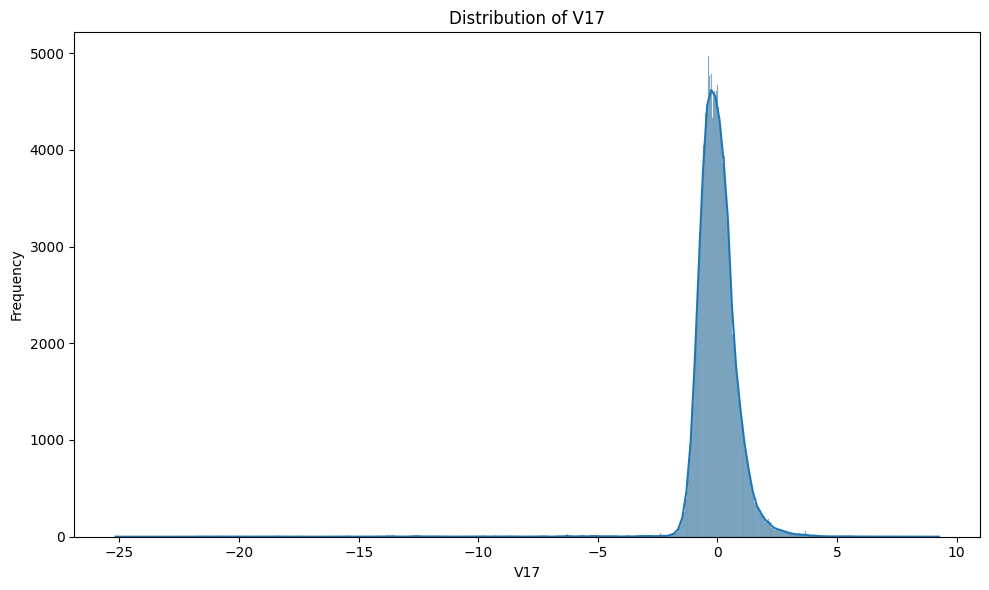

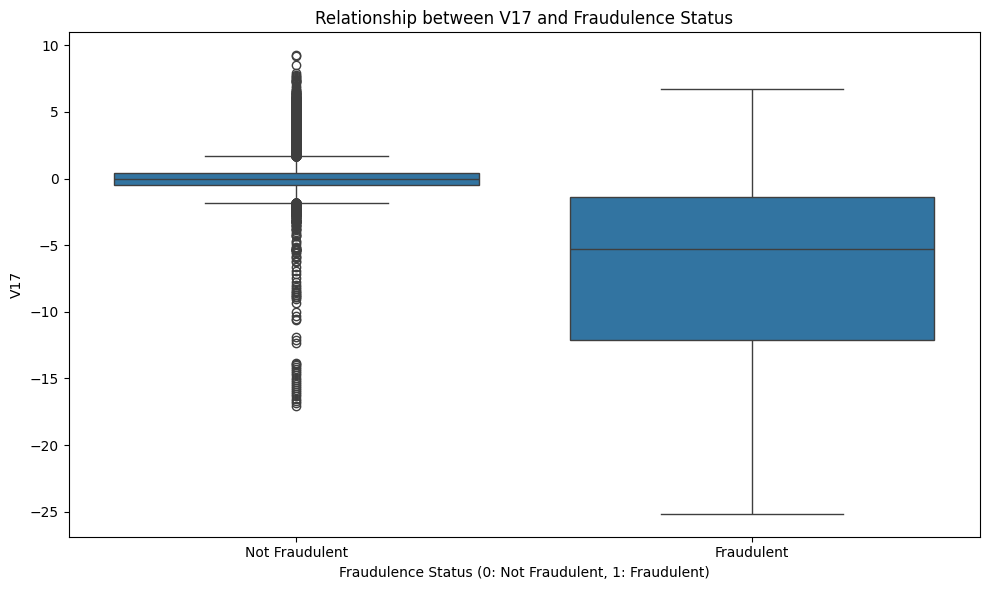


Analysis for column: V18

Descriptive statistics:


count    286315.000000
mean         -0.011777
std           0.877397
min          -9.498746
25%          -0.502948
50%          -0.006067
75%           0.499828
max           5.041069
Name: V18, dtype: float64

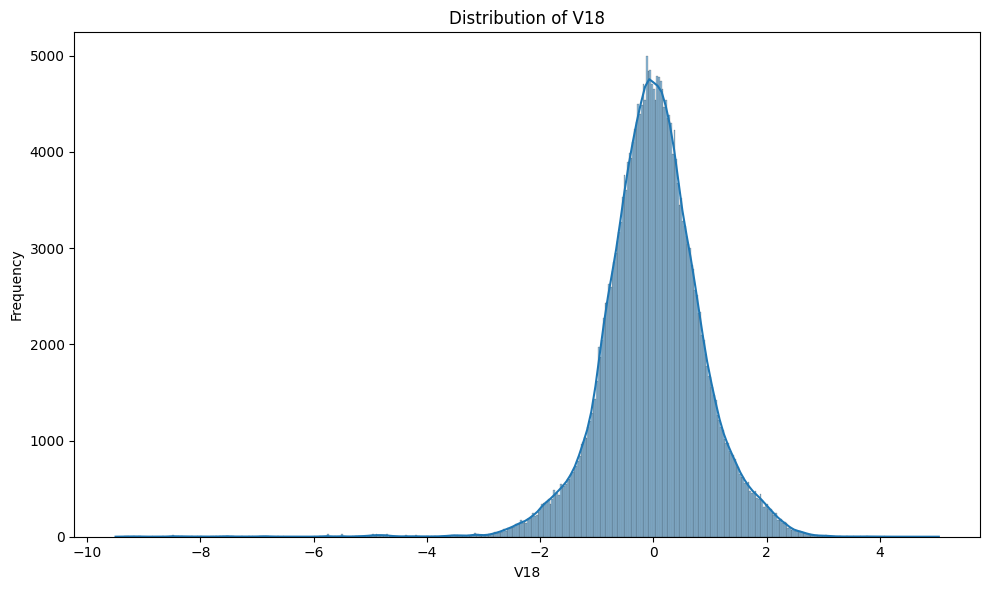

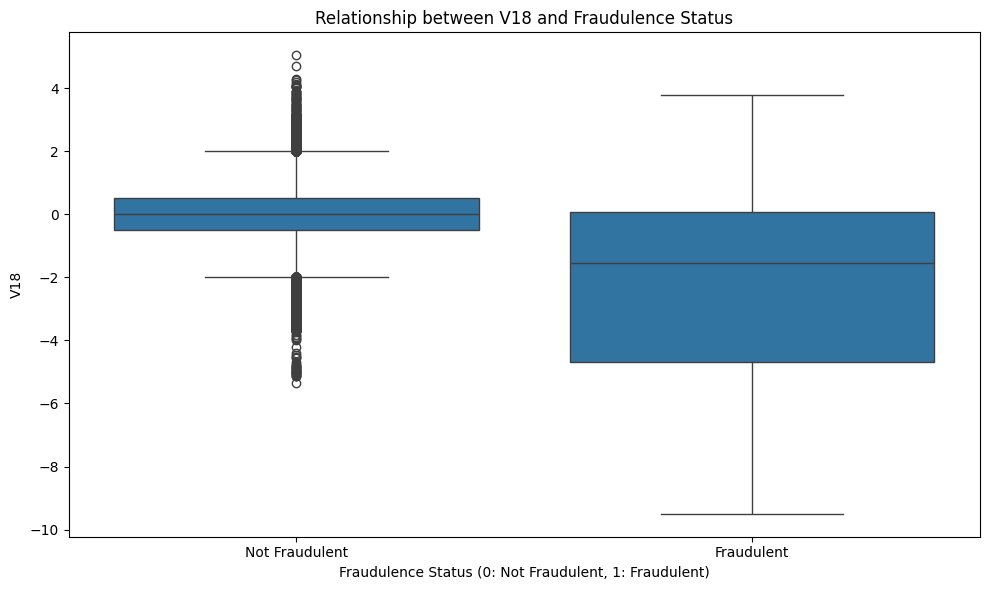


Analysis for column: V19

Descriptive statistics:


count    286315.000000
mean          0.003801
std           0.821054
min          -7.213527
25%          -0.455949
50%           0.005656
75%           0.462855
max           5.591971
Name: V19, dtype: float64

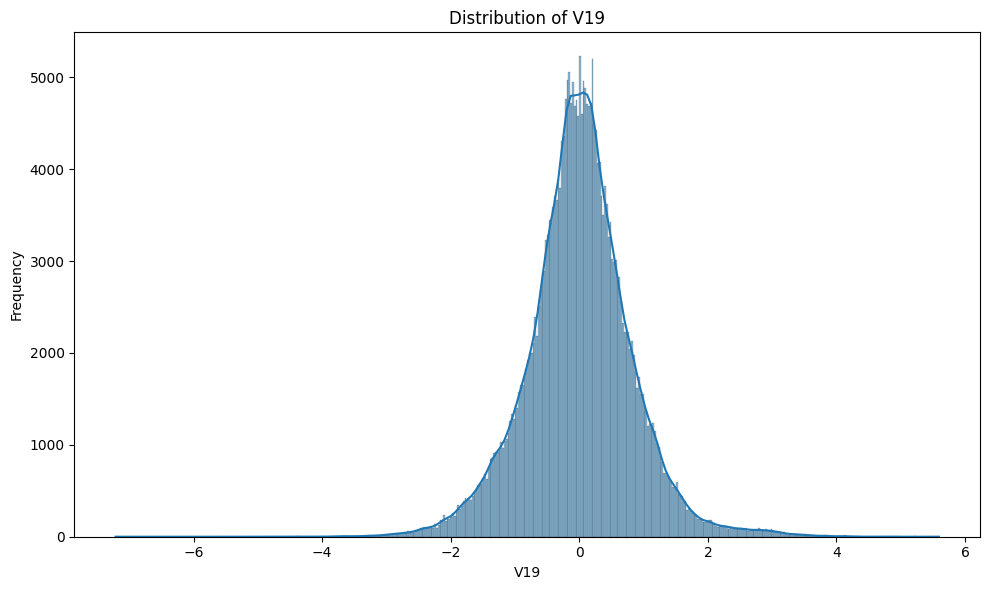

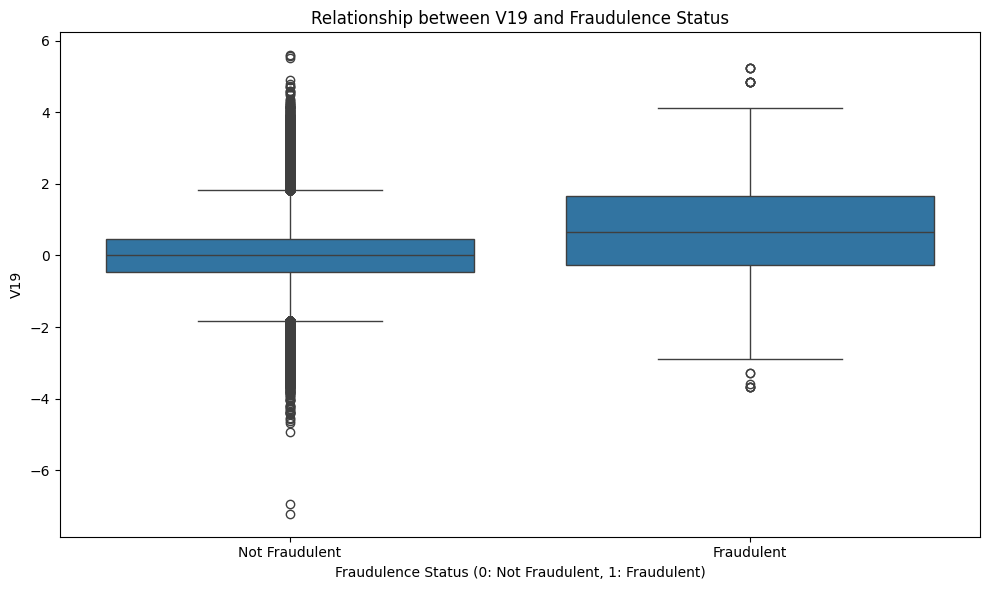


Analysis for column: V20

Descriptive statistics:


count    286315.000000
mean          0.001396
std           0.774501
min         -54.497720
25%          -0.211680
50%          -0.062040
75%           0.134791
max          39.420904
Name: V20, dtype: float64

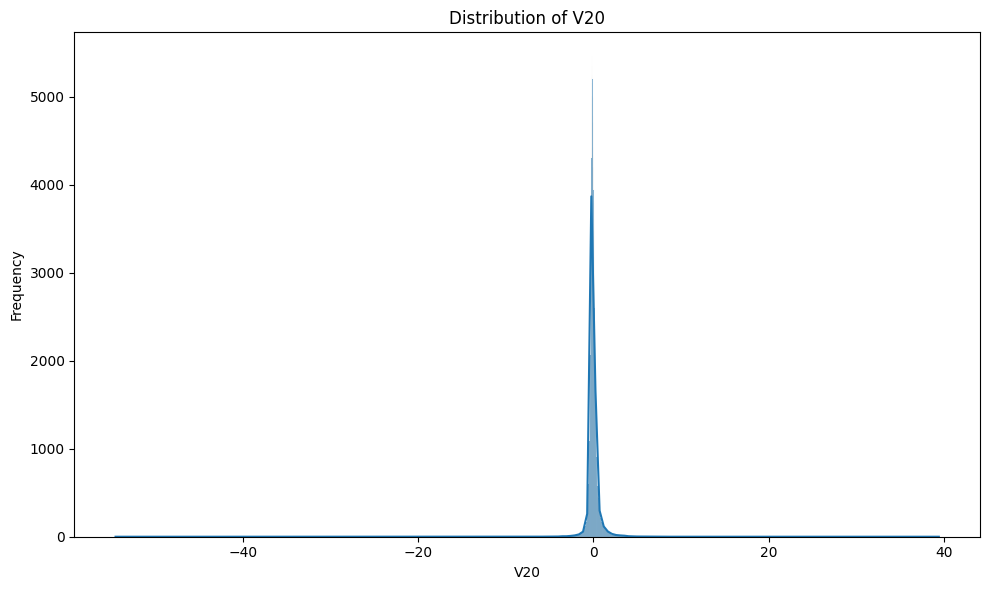

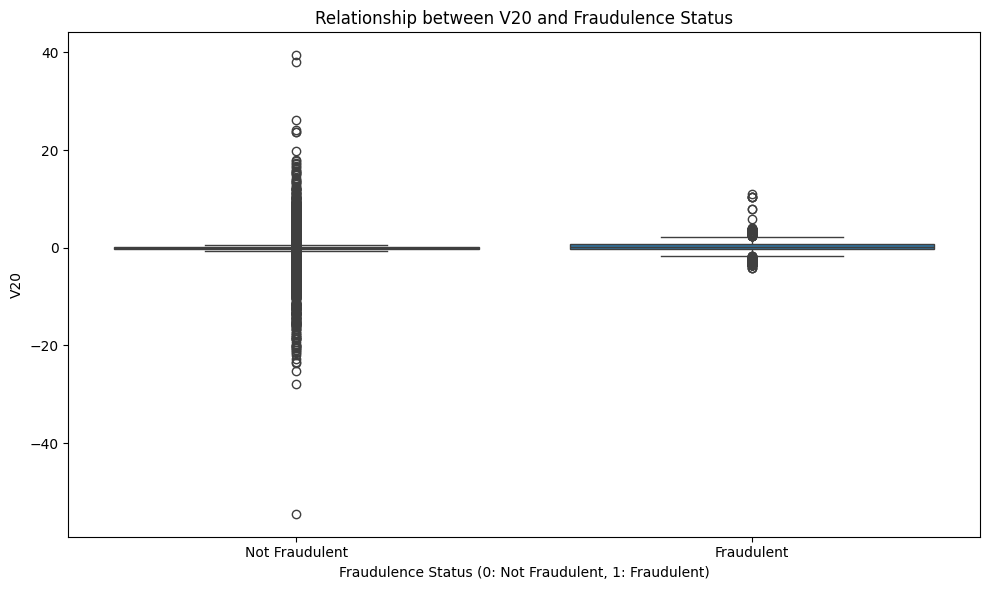


Analysis for column: V21

Descriptive statistics:


count    286315.000000
mean          0.005308
std           0.793311
min         -34.830382
25%          -0.228148
50%          -0.028469
75%           0.188609
max          27.202839
Name: V21, dtype: float64

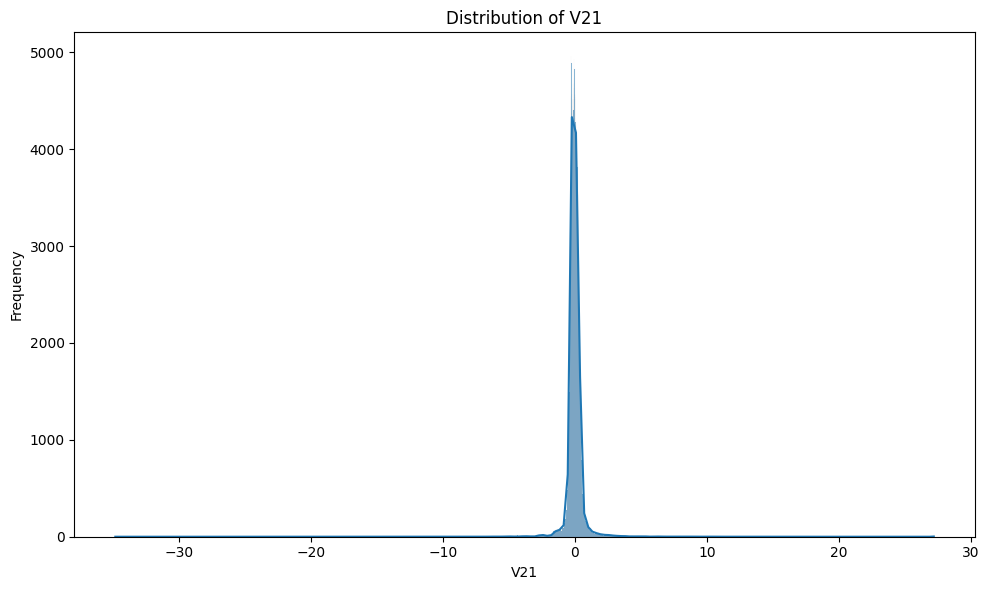

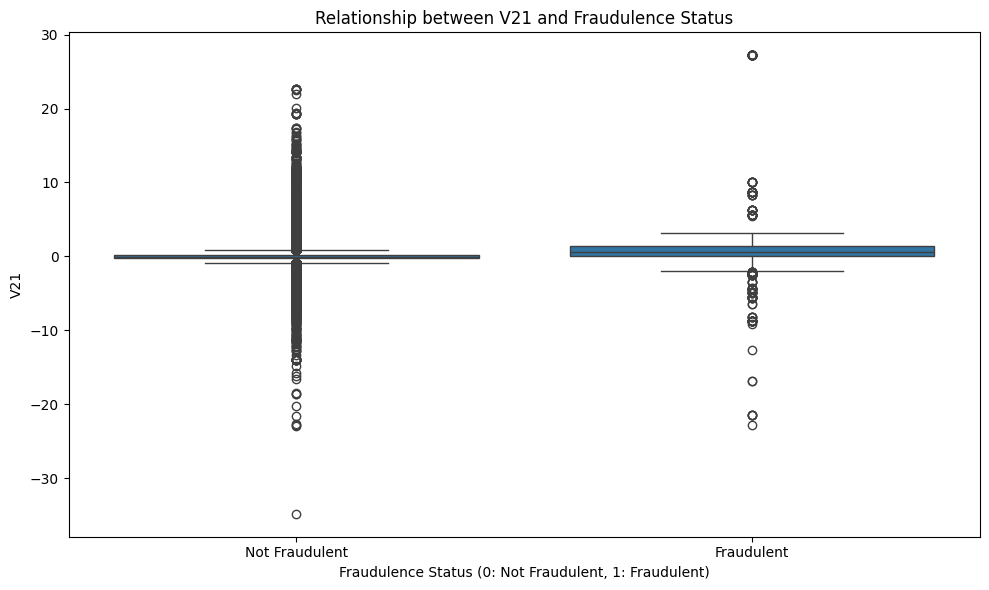


Analysis for column: V22

Descriptive statistics:


count    286315.000000
mean         -0.000239
std           0.732199
min         -10.933144
25%          -0.542344
50%           0.007077
75%           0.529161
max          10.503090
Name: V22, dtype: float64

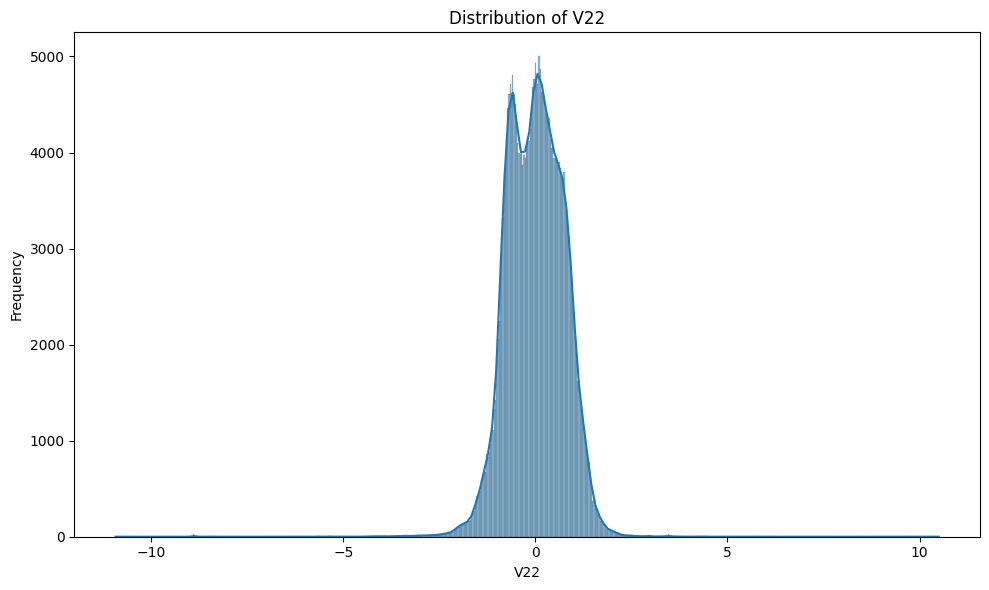

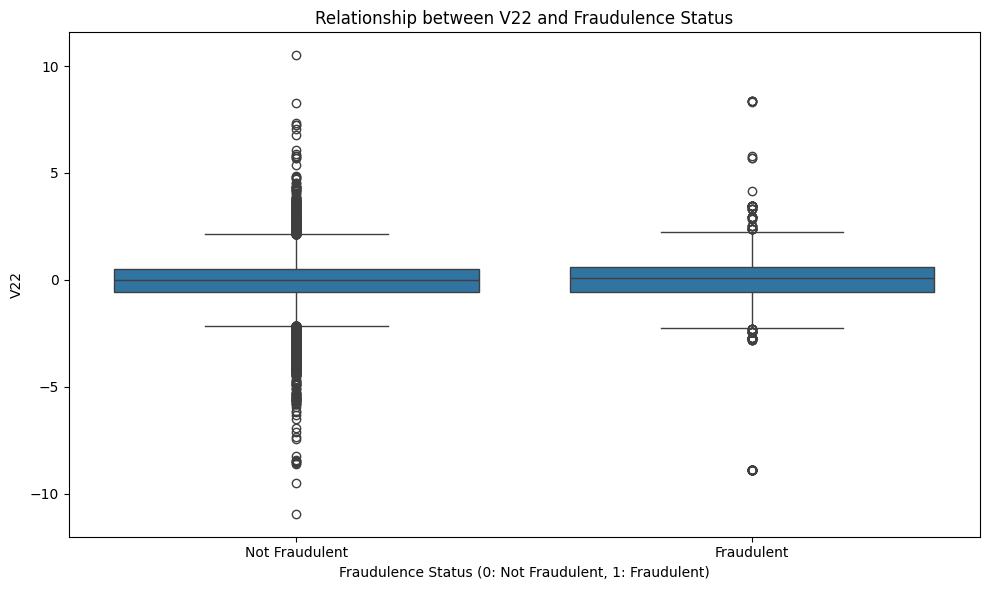


Analysis for column: V23

Descriptive statistics:


count    286315.000000
mean          0.000147
std           0.631161
min         -44.807735
25%          -0.162328
50%          -0.011301
75%           0.148145
max          22.528412
Name: V23, dtype: float64

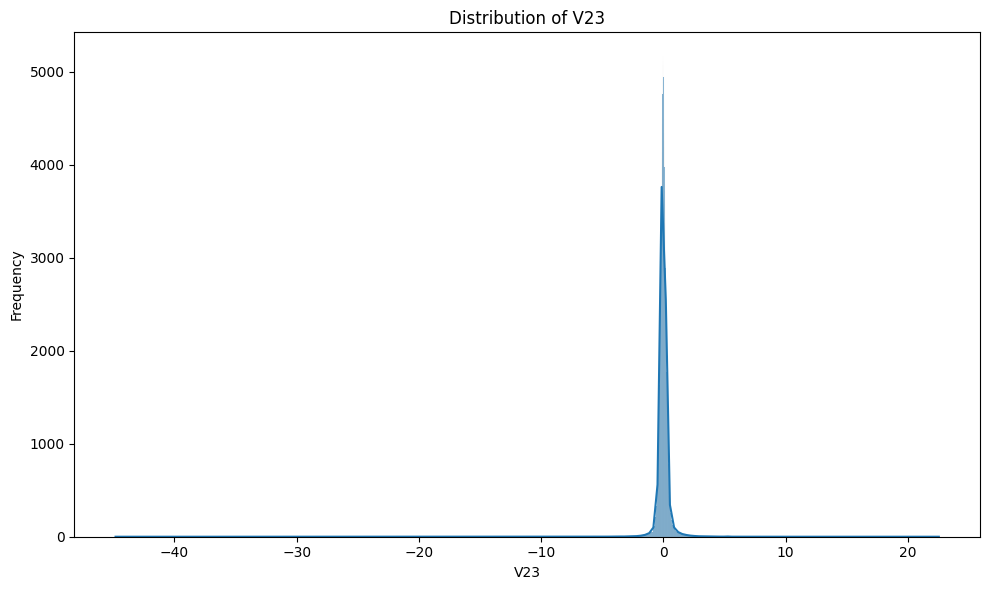

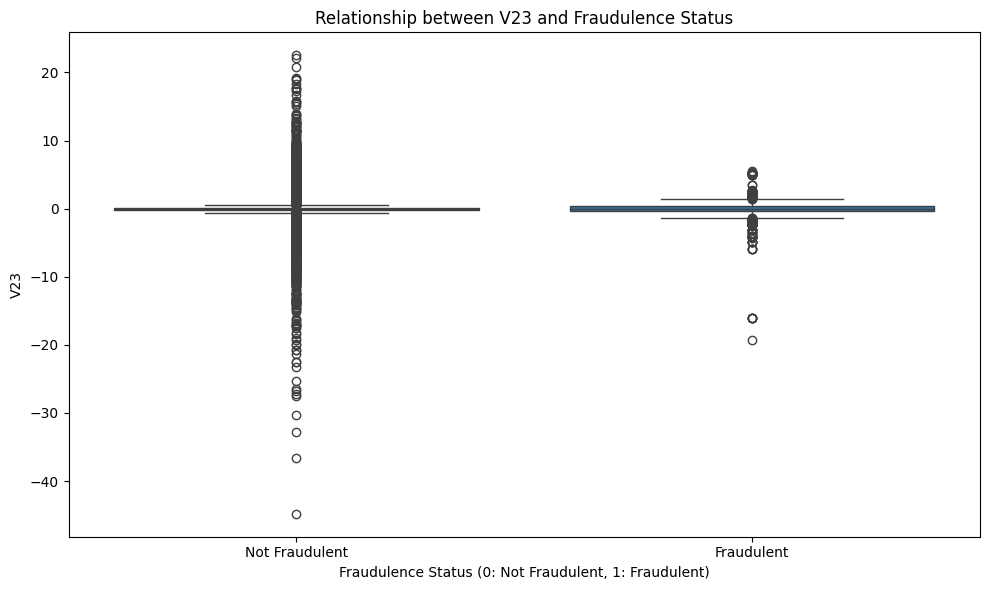


Analysis for column: V24

Descriptive statistics:


count    286315.000000
mean         -0.000671
std           0.605376
min          -2.836627
25%          -0.355409
50%           0.040631
75%           0.438711
max           4.584549
Name: V24, dtype: float64

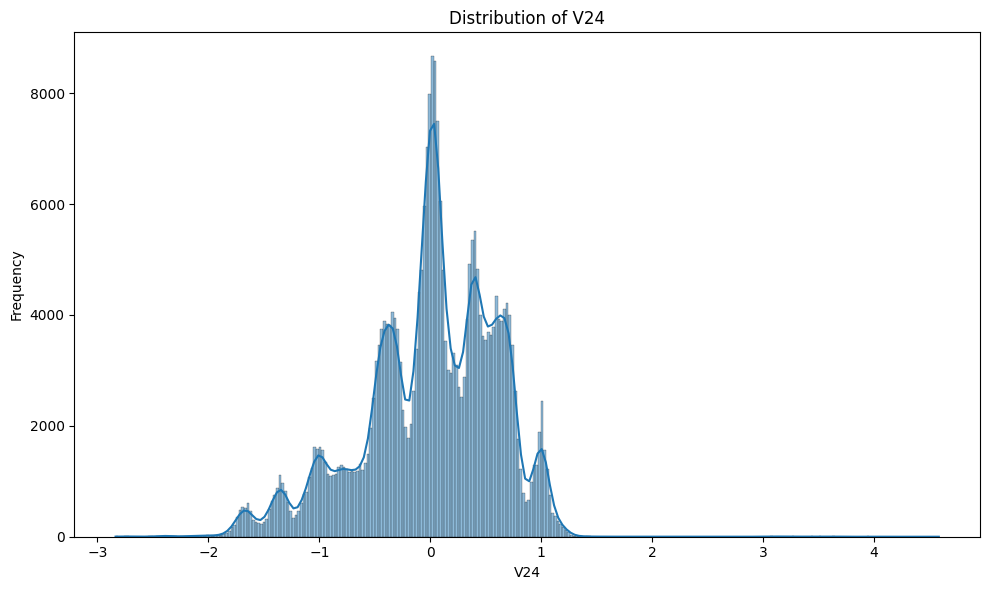

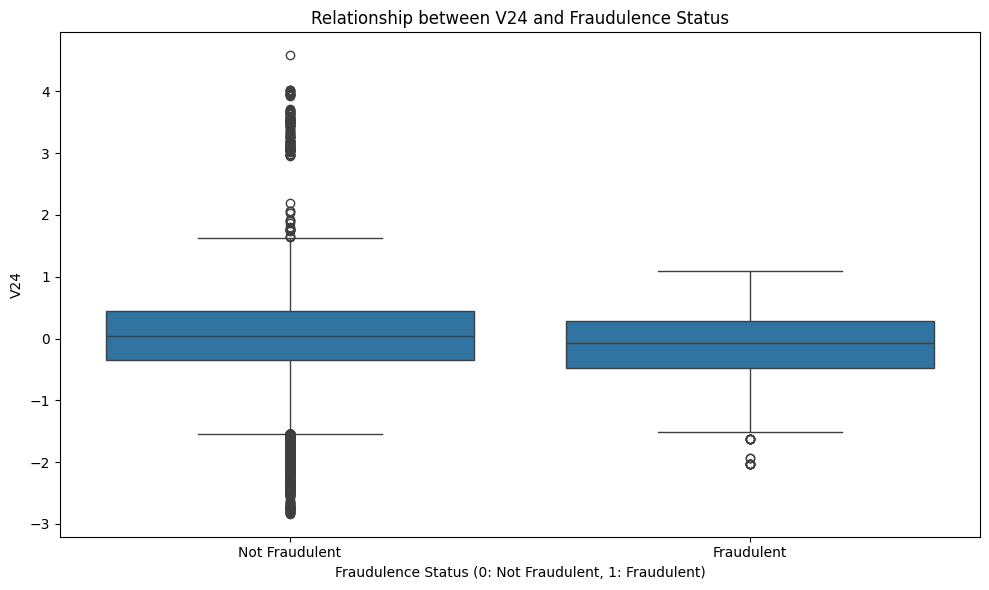


Analysis for column: V25

Descriptive statistics:


count    286315.000000
mean          0.000073
std           0.522728
min         -10.295397
25%          -0.317220
50%           0.016925
75%           0.351185
max           7.519589
Name: V25, dtype: float64

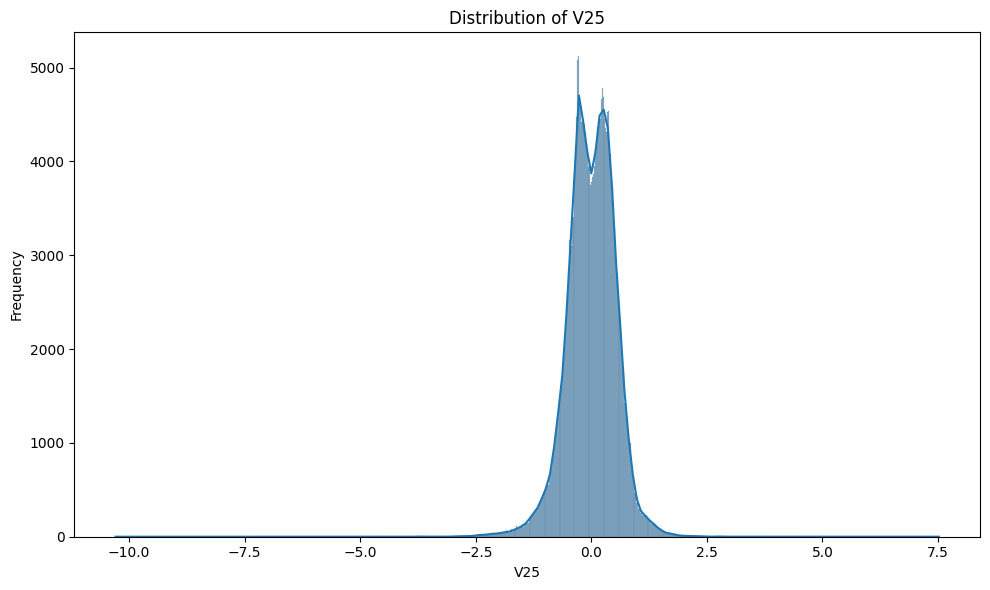

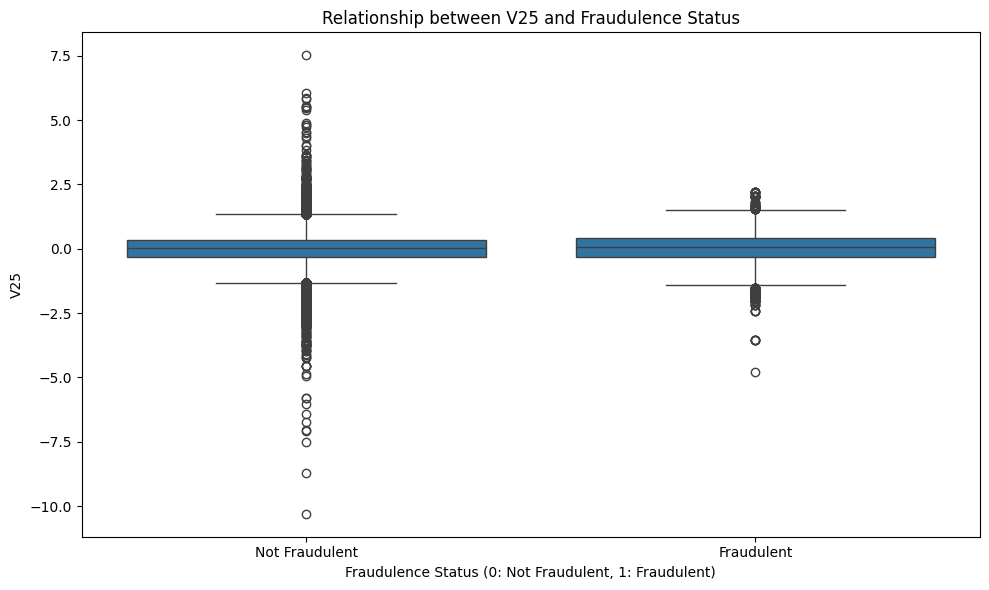


Analysis for column: V26

Descriptive statistics:


count    286315.000000
mean          0.000214
std           0.482259
min          -2.604551
25%          -0.326836
50%          -0.051817
75%           0.241833
max           3.517346
Name: V26, dtype: float64

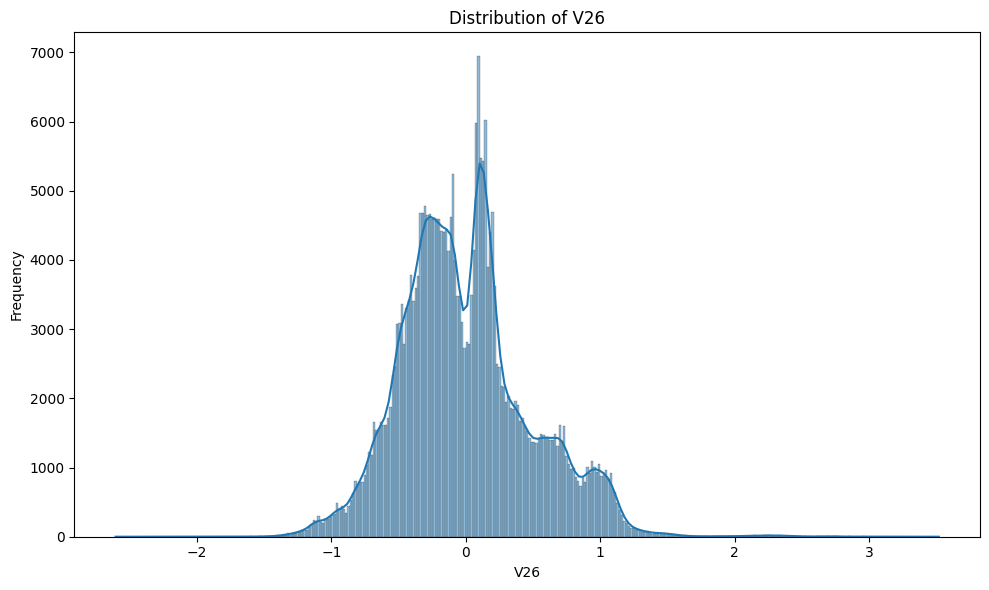

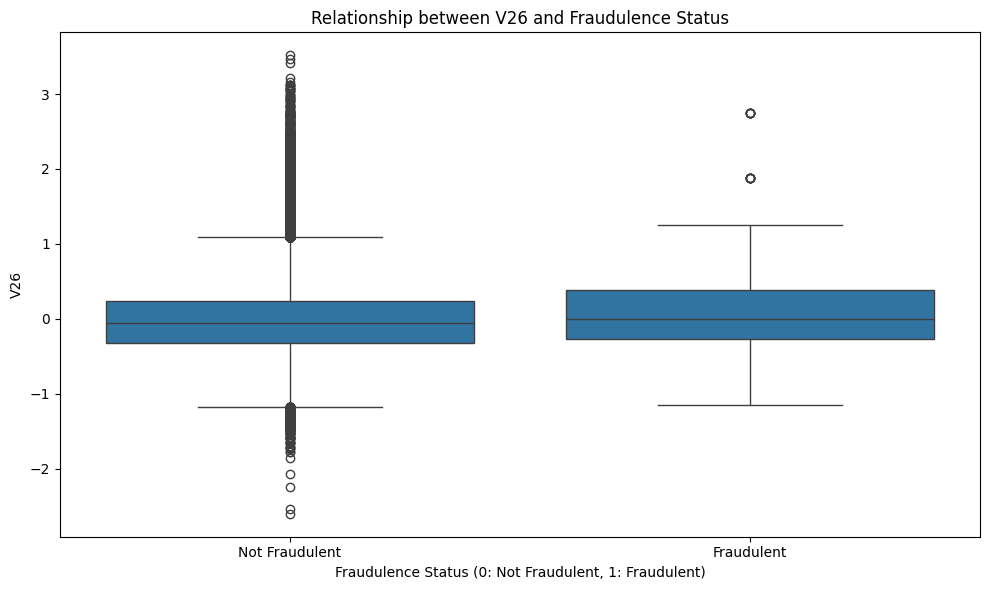


Analysis for column: V27

Descriptive statistics:


count    286315.000000
mean          0.000797
std           0.415420
min         -22.565679
25%          -0.070823
50%           0.001647
75%           0.092453
max          31.612198
Name: V27, dtype: float64

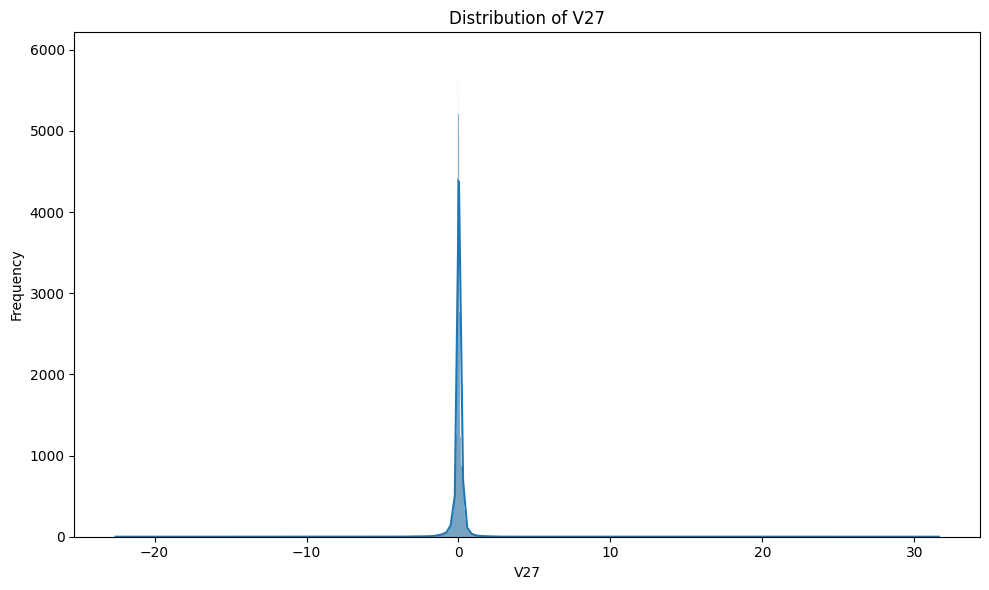

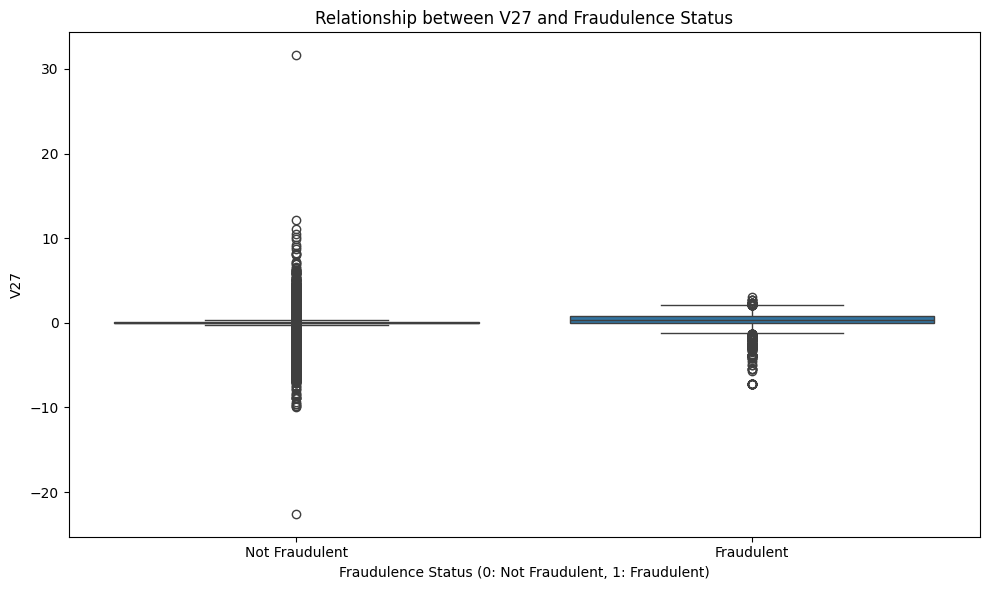


Analysis for column: V28

Descriptive statistics:


count    286315.000000
mean          0.000247
std           0.332052
min         -15.430084
25%          -0.053024
50%           0.011369
75%           0.079128
max          33.847808
Name: V28, dtype: float64

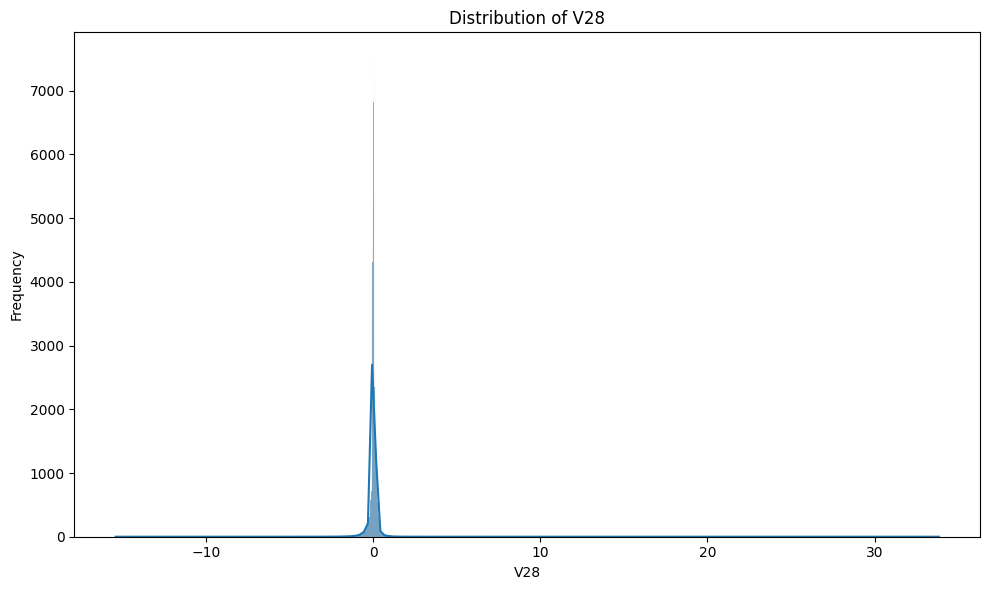

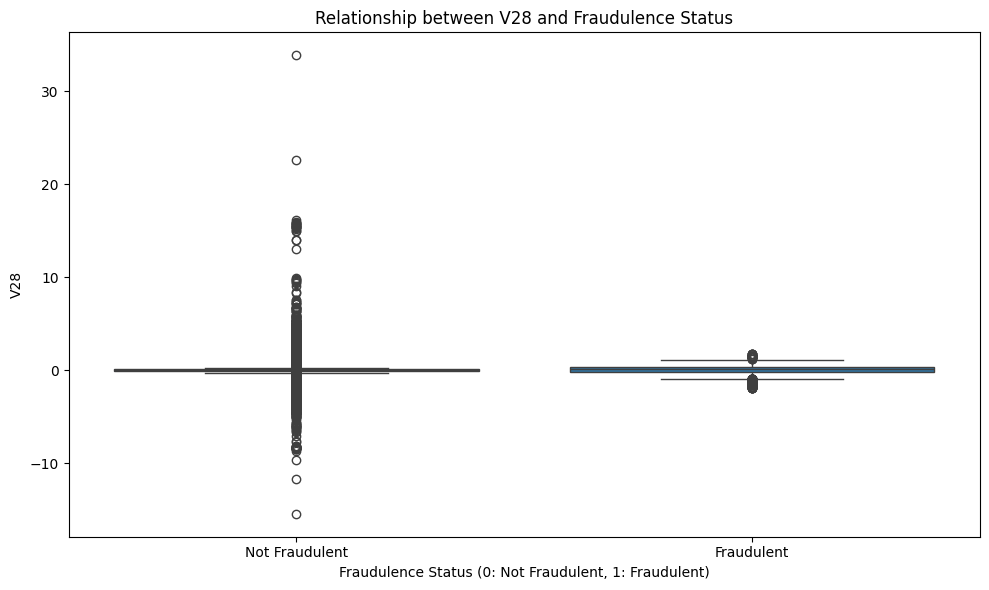


Analysis for column: Amount

Descriptive statistics:


count    286315.000000
mean         92.684657
std         368.354476
min           0.000000
25%           5.490000
50%          22.000000
75%          77.695000
max       25691.160000
Name: Amount, dtype: float64

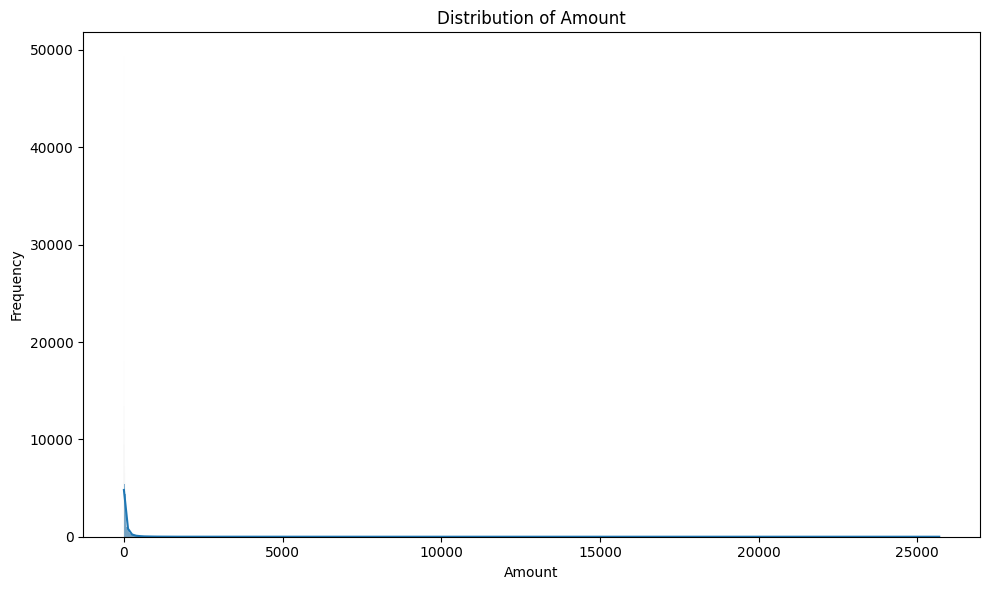

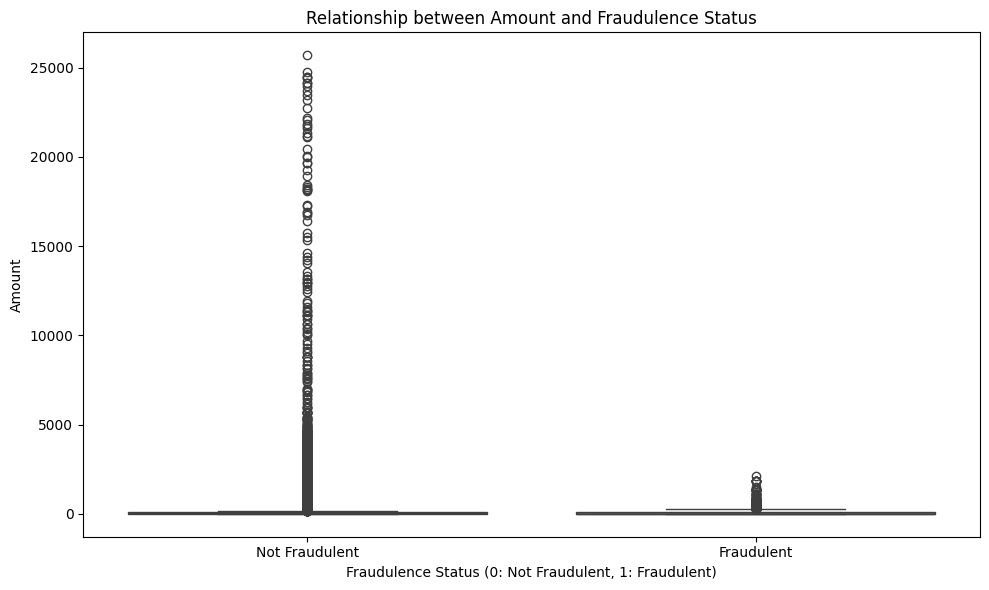


Analysis for column: age

Descriptive statistics:


count    286068.000000
mean         49.844261
std          18.113252
min          18.000000
25%          35.000000
50%          50.000000
75%          66.000000
max          79.000000
Name: age, dtype: float64

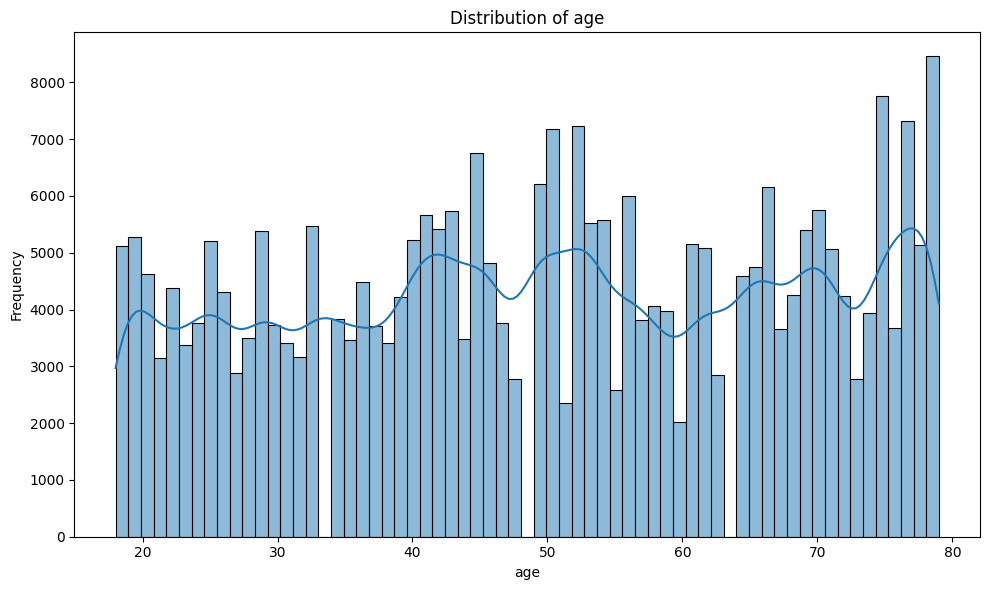

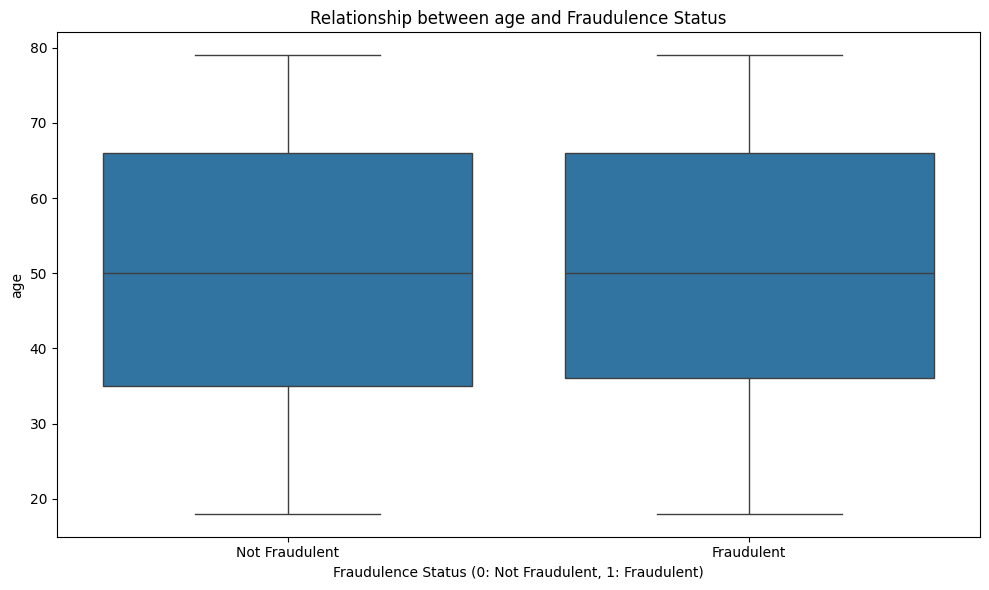


Analysis for column: credit_score

Descriptive statistics:


count    286068.000000
mean        652.938343
std         103.595359
min         300.000000
25%         587.000000
50%         657.000000
75%         726.000000
max         850.000000
Name: credit_score, dtype: float64

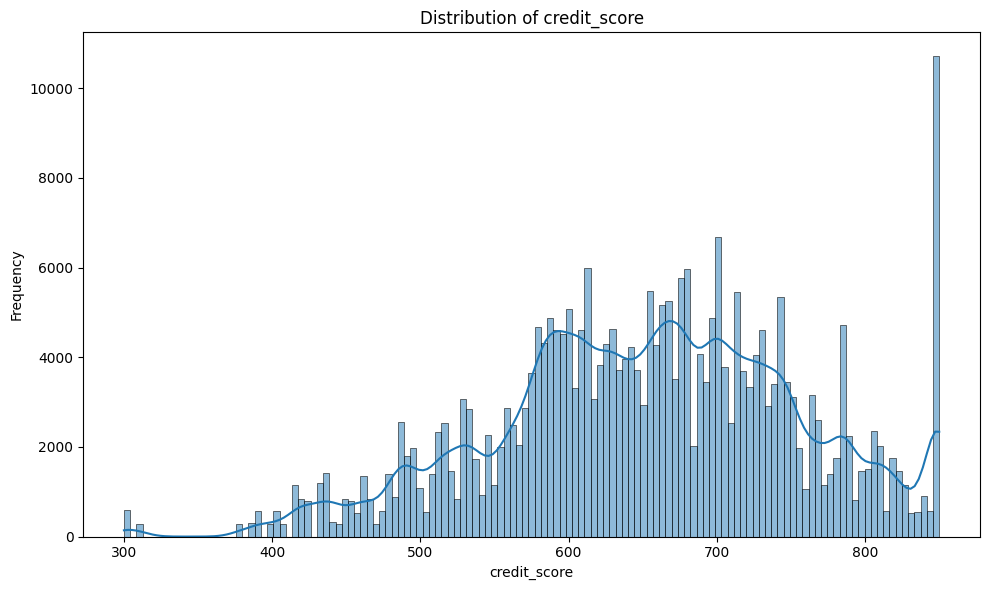

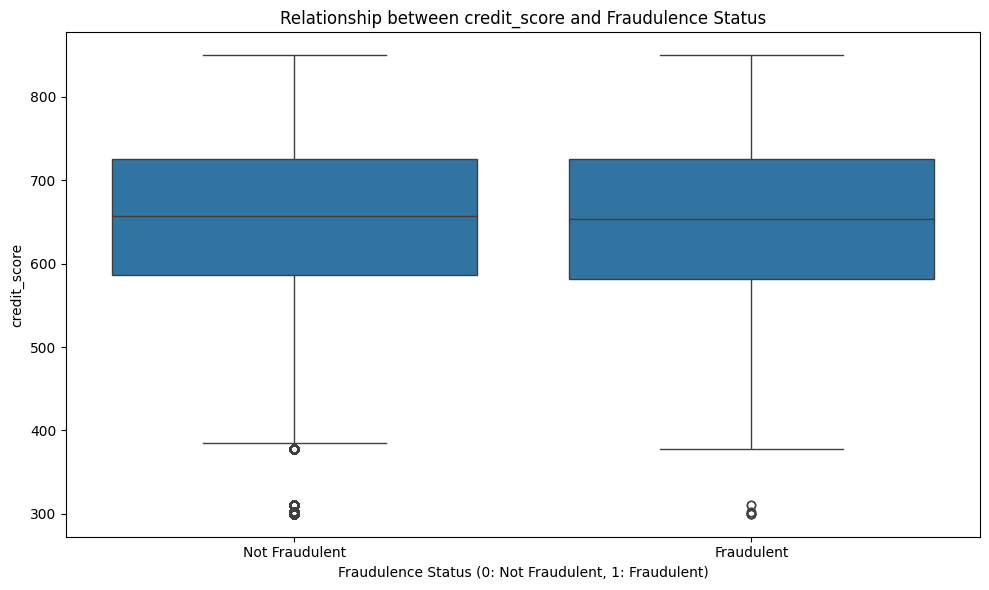


Analysis for column: hour

Descriptive statistics:


count    286315.000000
mean         14.032859
std           5.843513
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: hour, dtype: float64

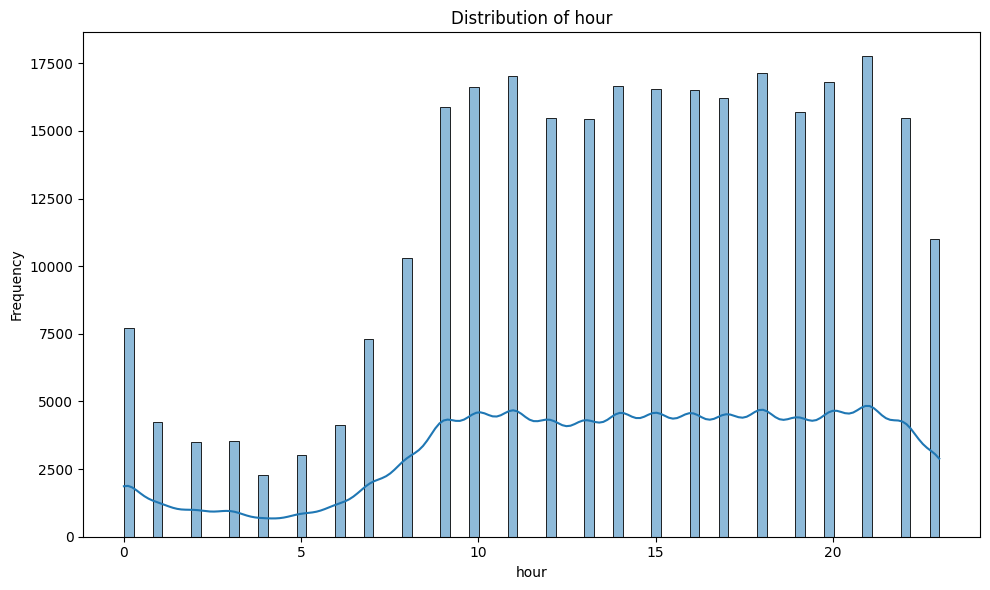

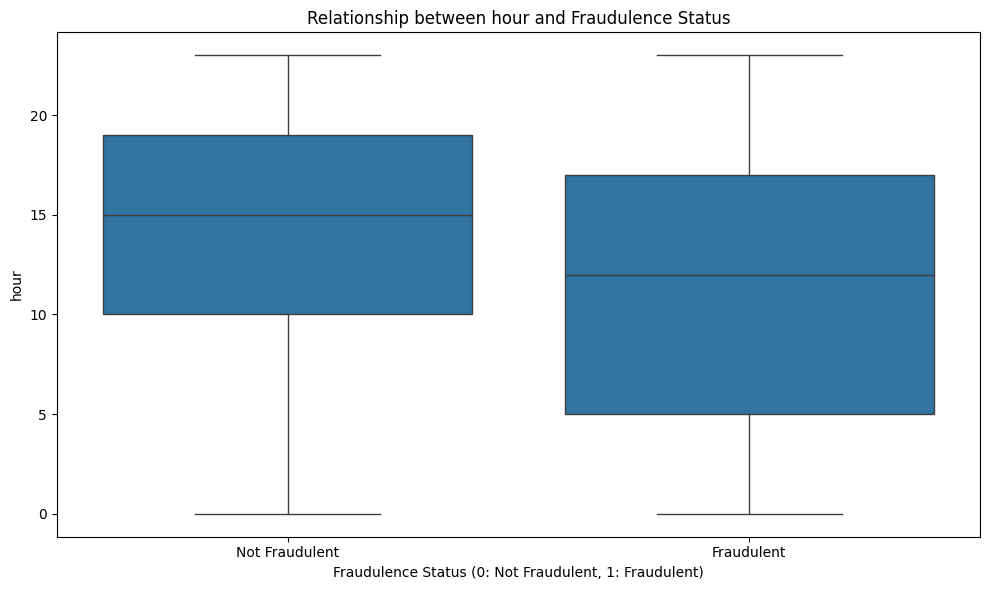

In [34]:
for col in numeric_df:
    print(f"\nAnalysis for column: {col}")

    # Calculate descriptive statistics
    print("\nDescriptive statistics:")
    display(df[col].describe())

    # Visualize distribution of the numeric variable
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Analyze relationship with survival_status
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Class', y=col)
    plt.title(f'Relationship between {col} and Fraudulence Status')
    plt.xlabel('Fraudulence Status (0: Not Fraudulent, 1: Fraudulent)')
    plt.ylabel(col)
    plt.xticks([0, 1], ['Not Fraudulent', 'Fraudulent'])
    plt.tight_layout()
    plt.show()

Numeric variables (V1–V28, Amount, age, credit_score) show patterns consistent with standardized PCA components, centered around zero with unit-scale variance. Transaction Amount is highly right-skewed, reflecting occasional high-value transactions, while age (18–79) and credit_score (300–850) fall within realistic ranges. Boxplots by Class reveal potential differences between fraudulent and non-fraudulent transactions.

### Categorical Variables

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


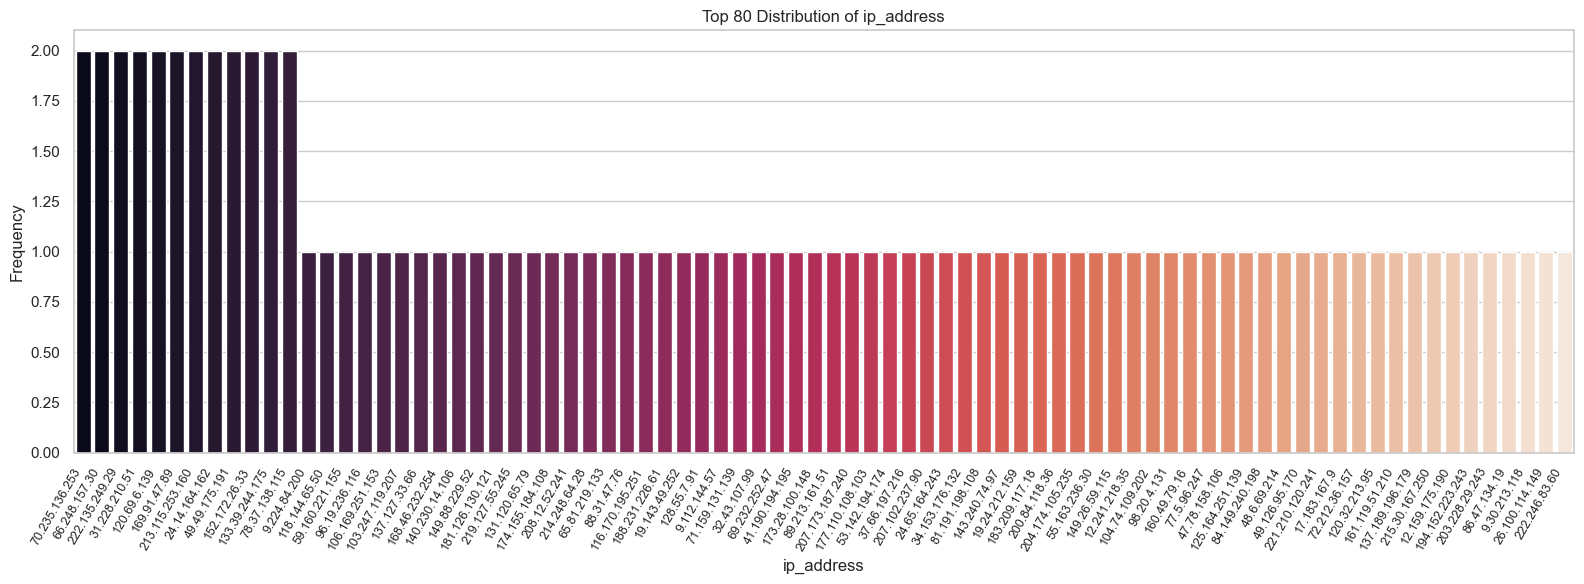

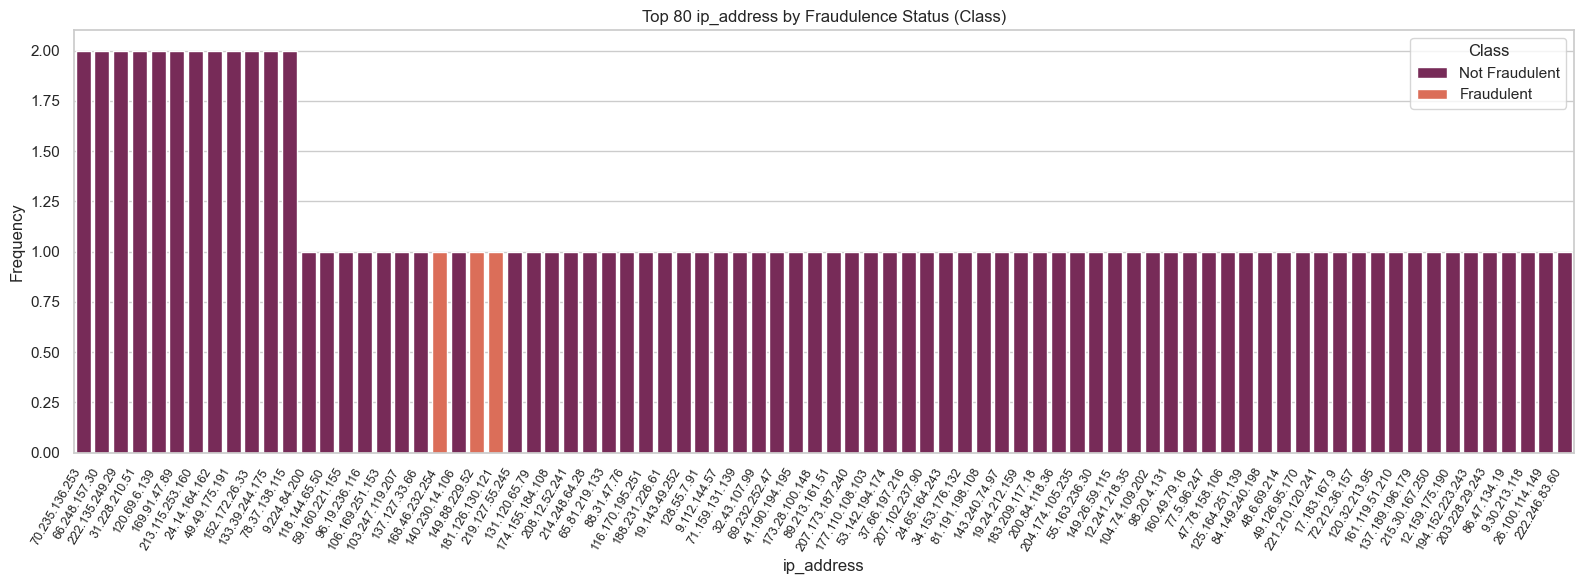

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


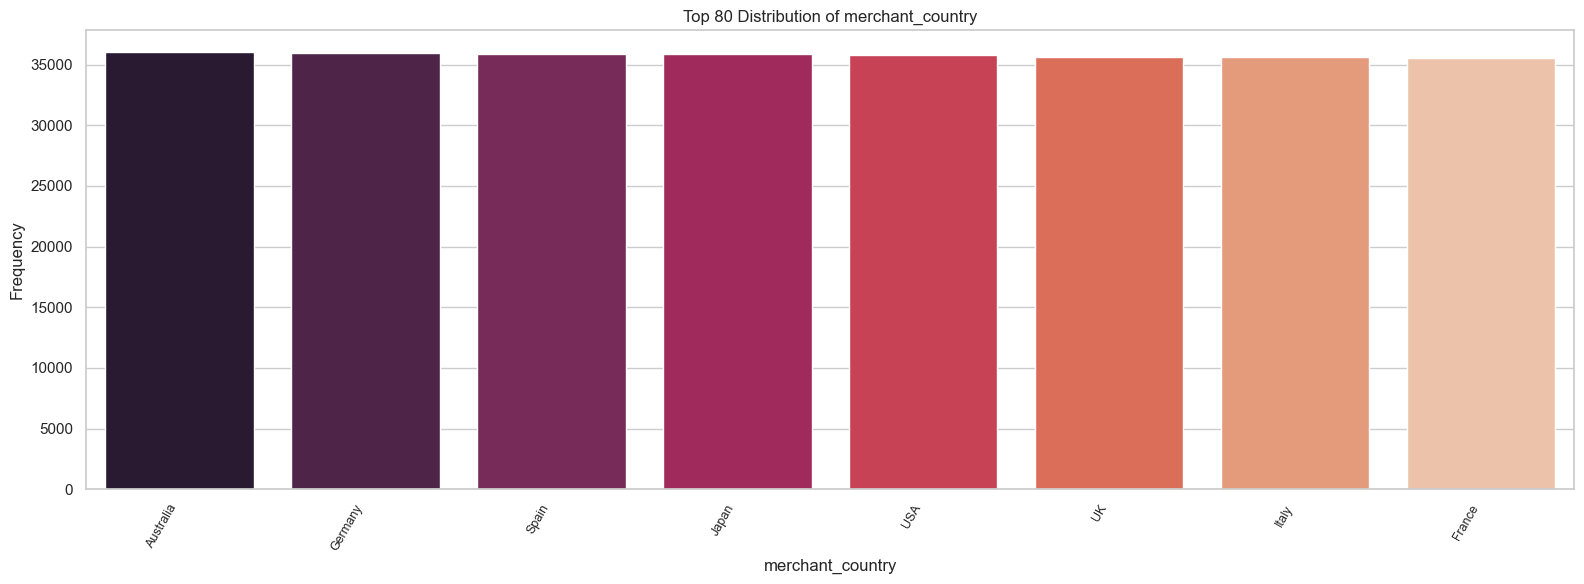

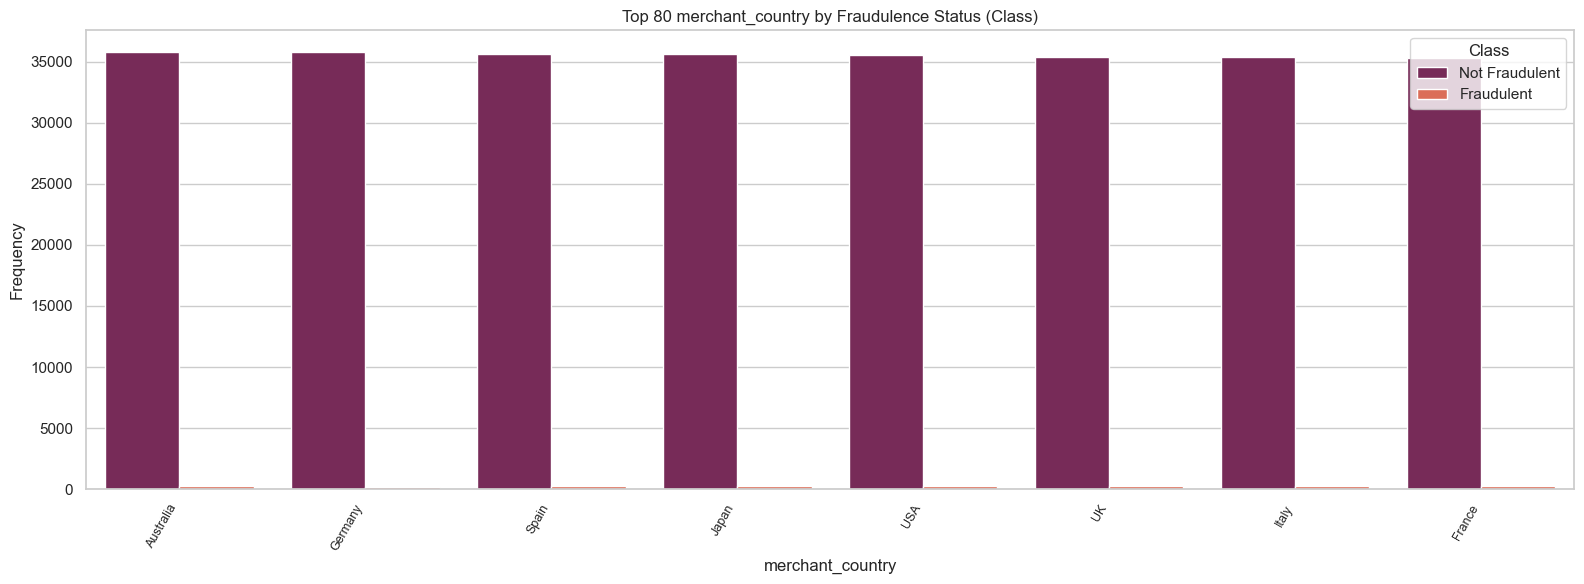

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


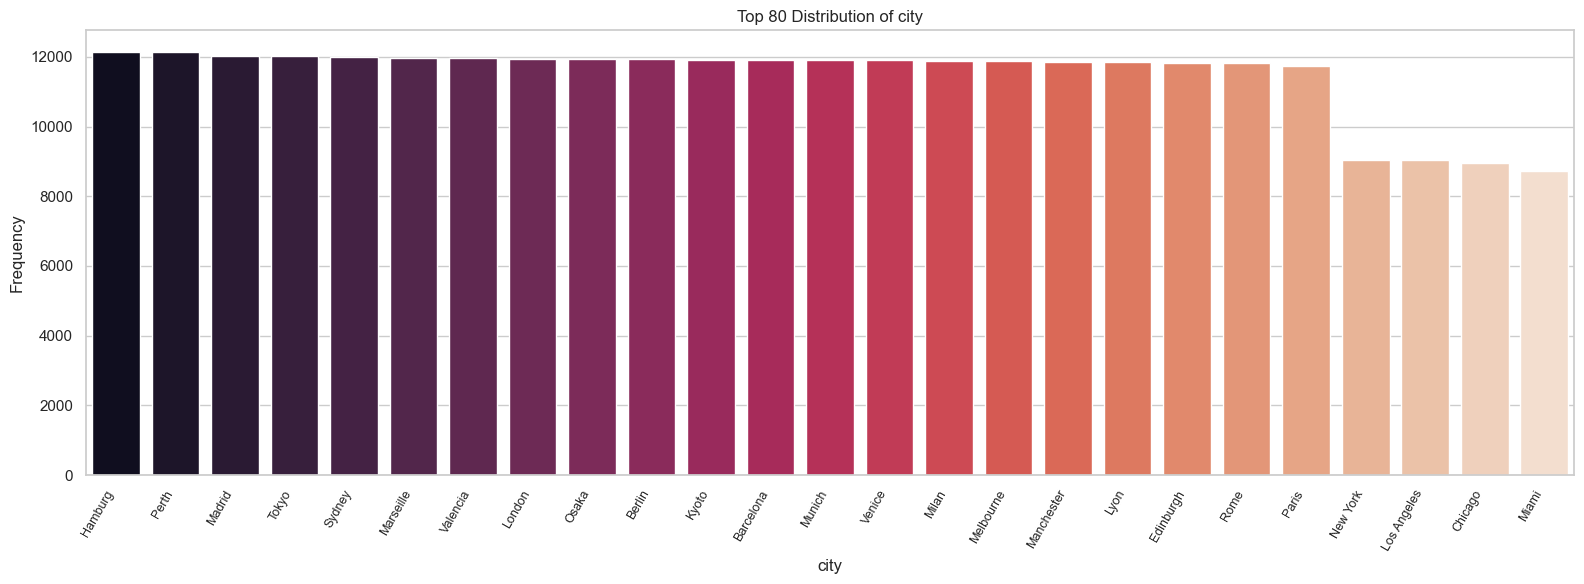

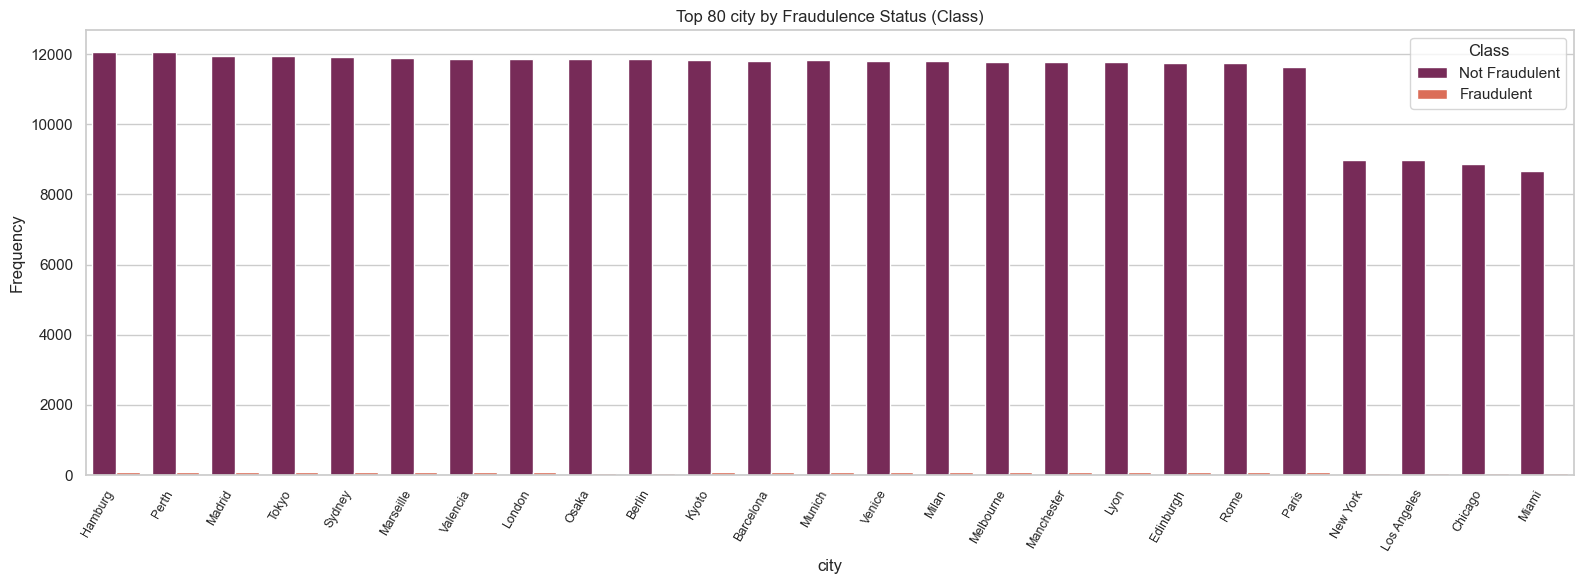

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


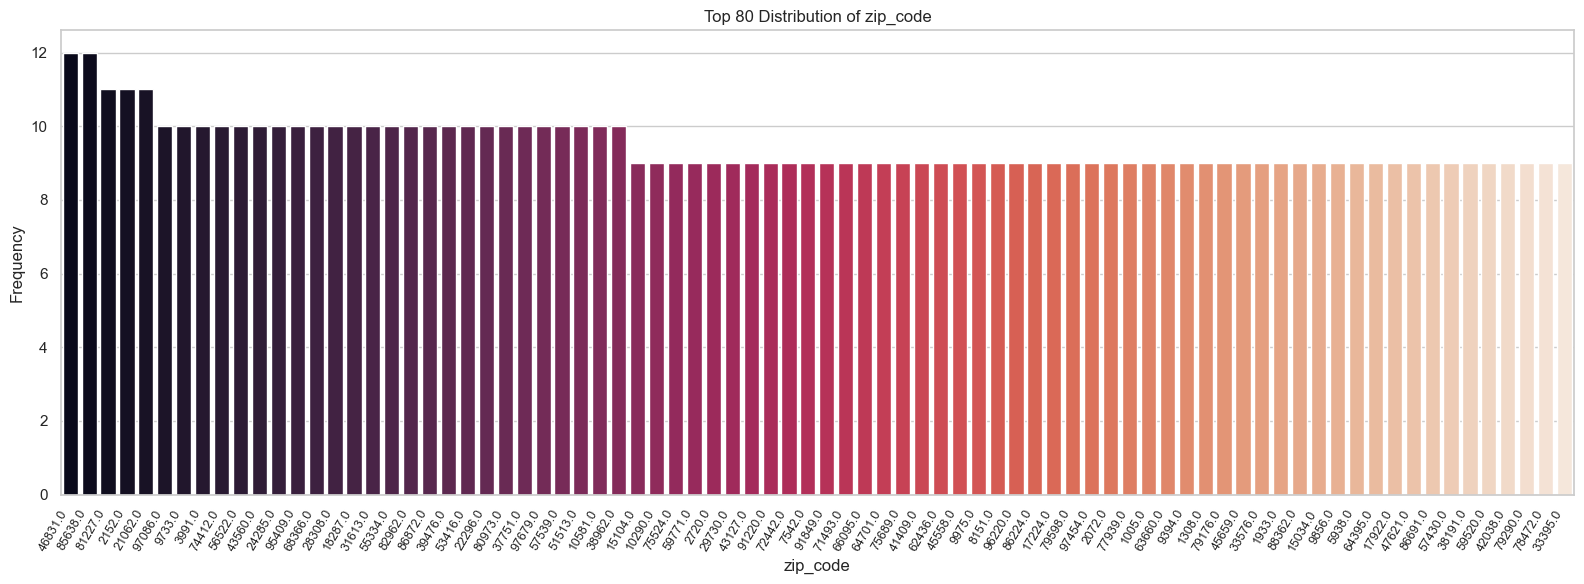

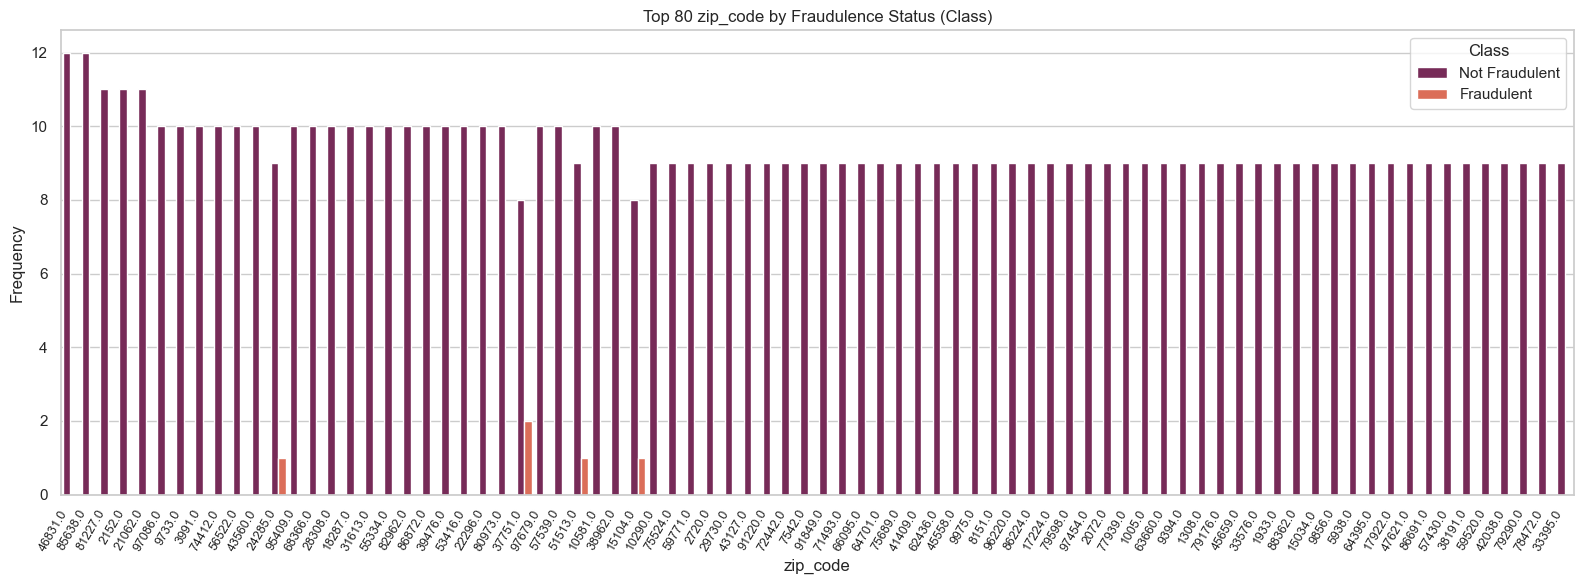

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


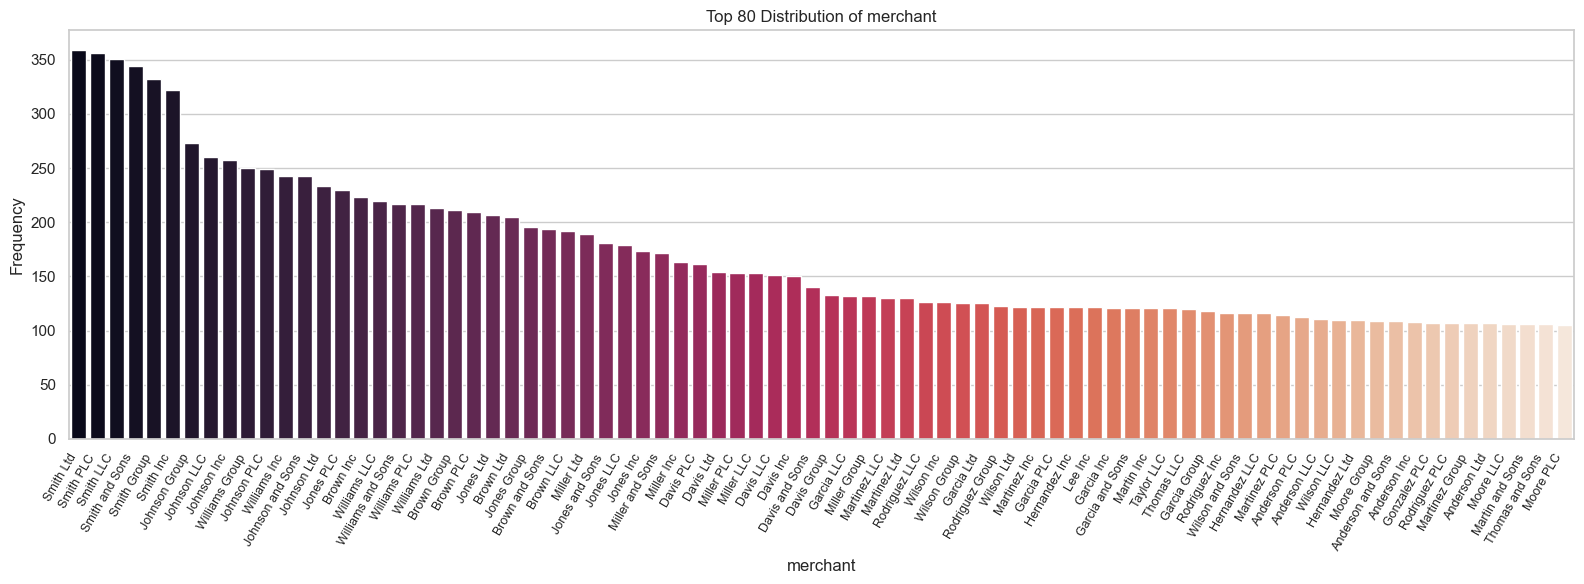

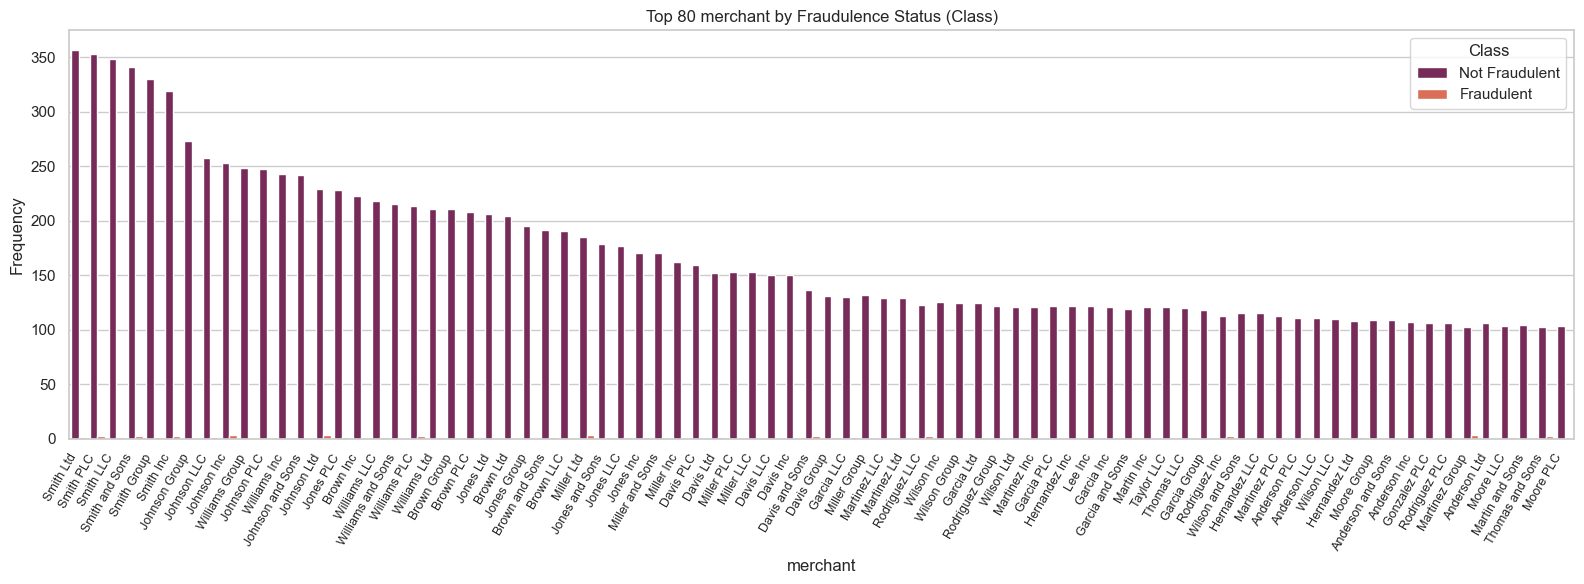

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


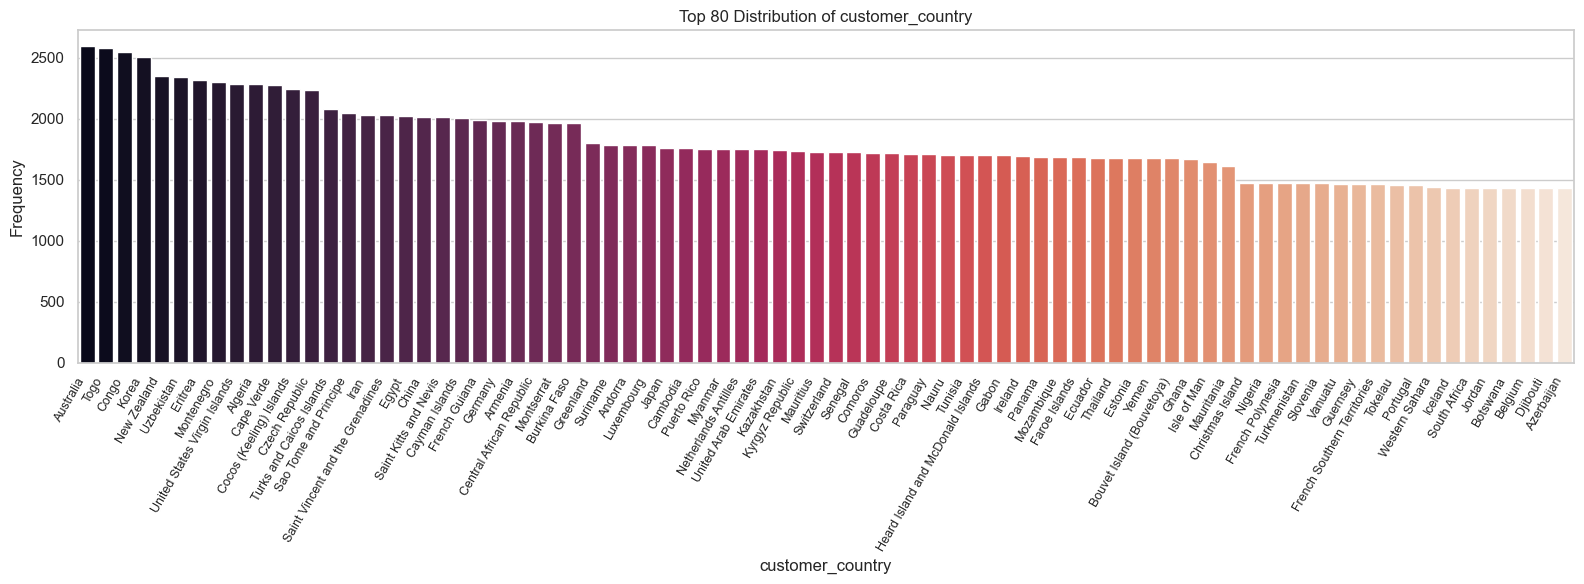

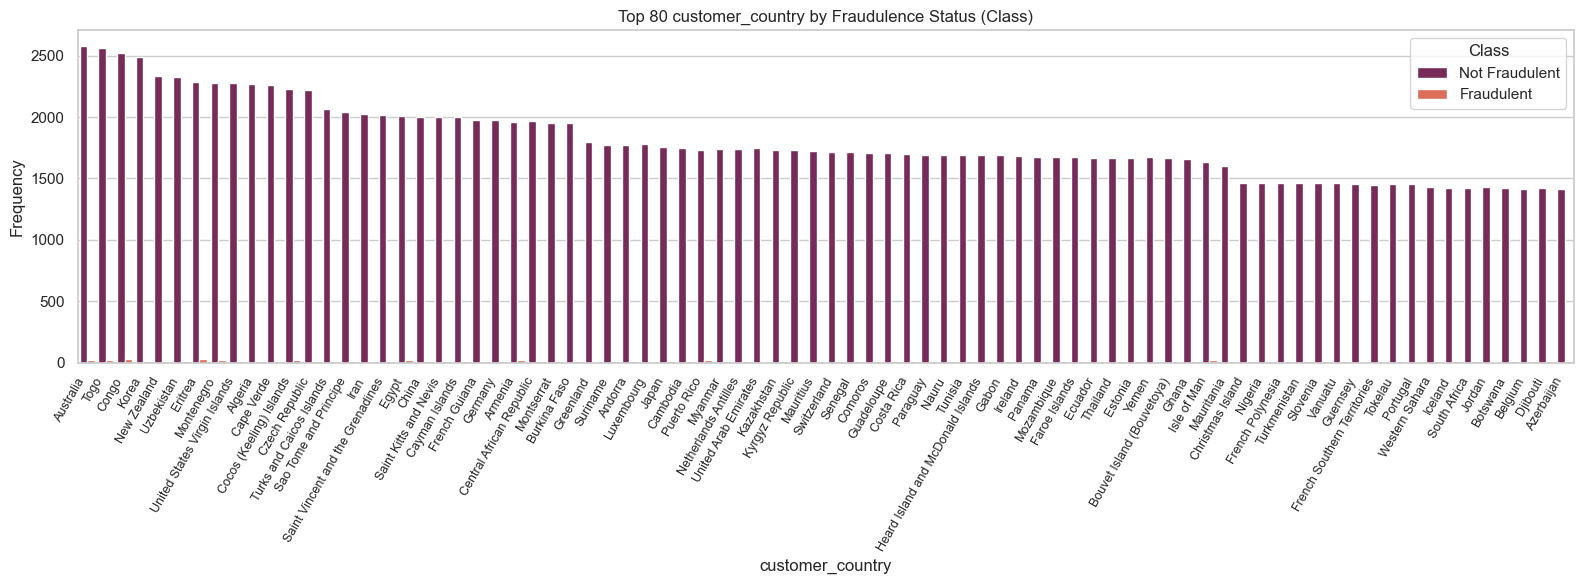

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


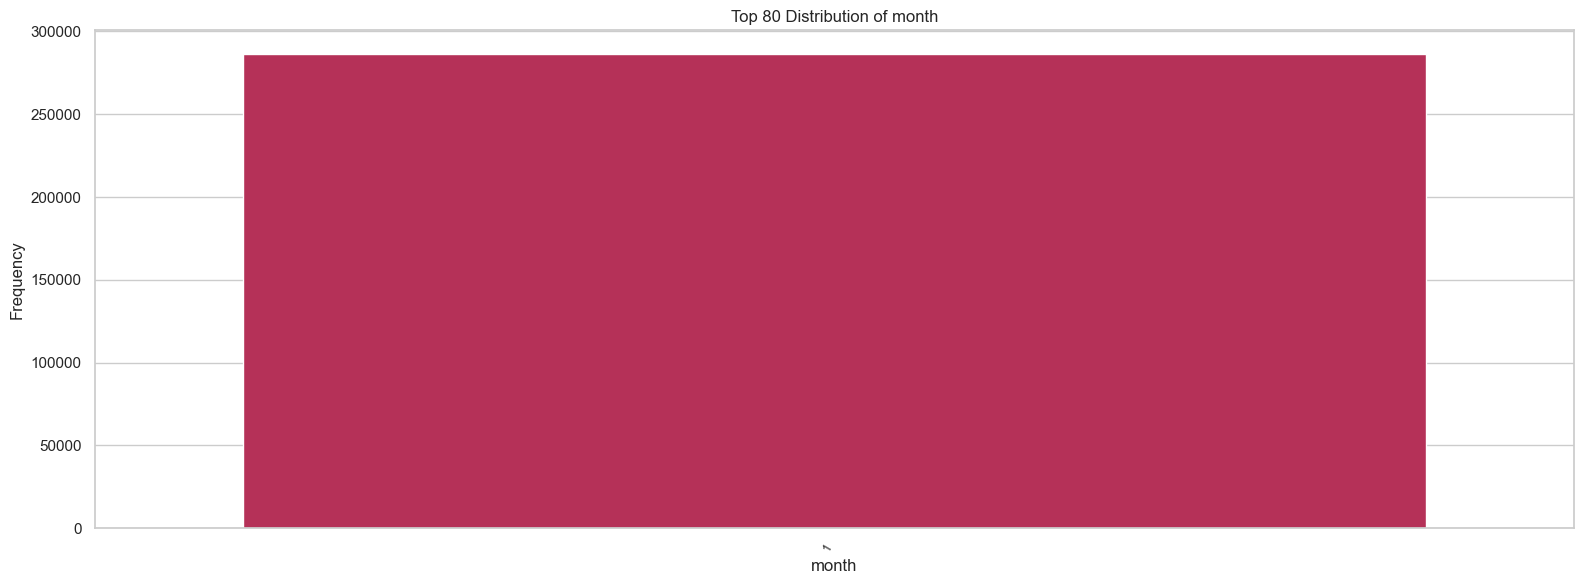

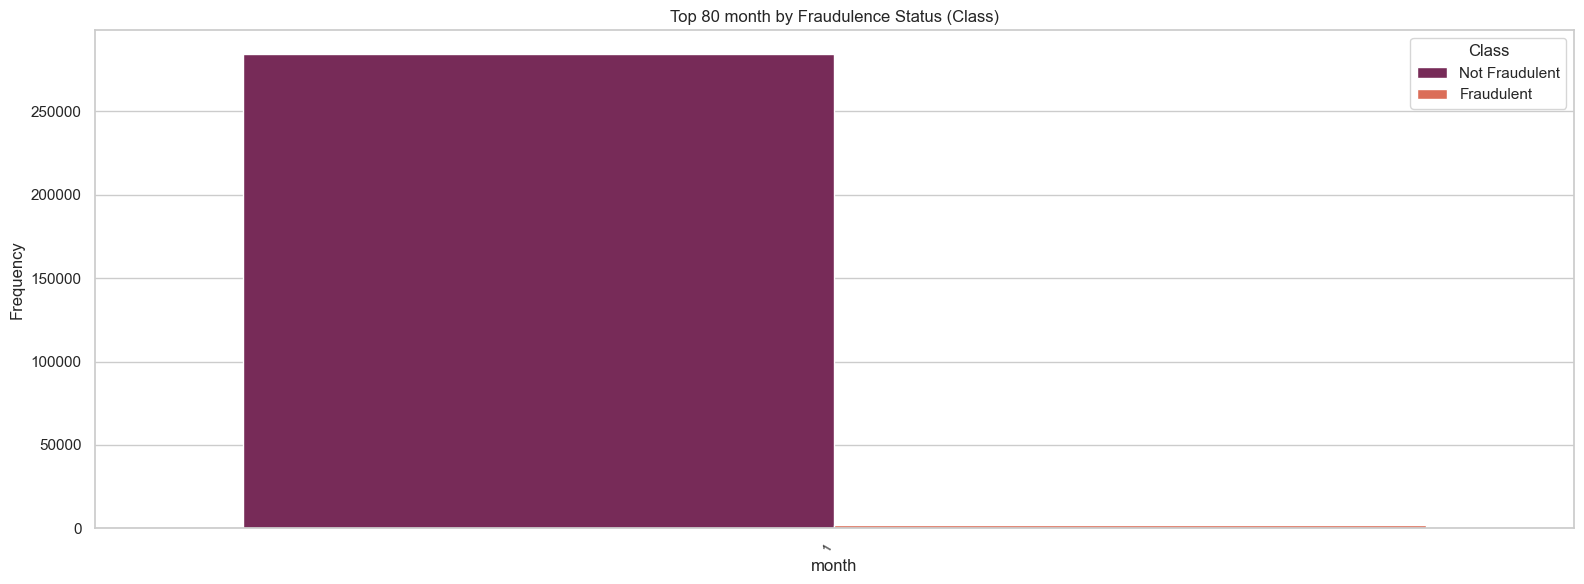

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


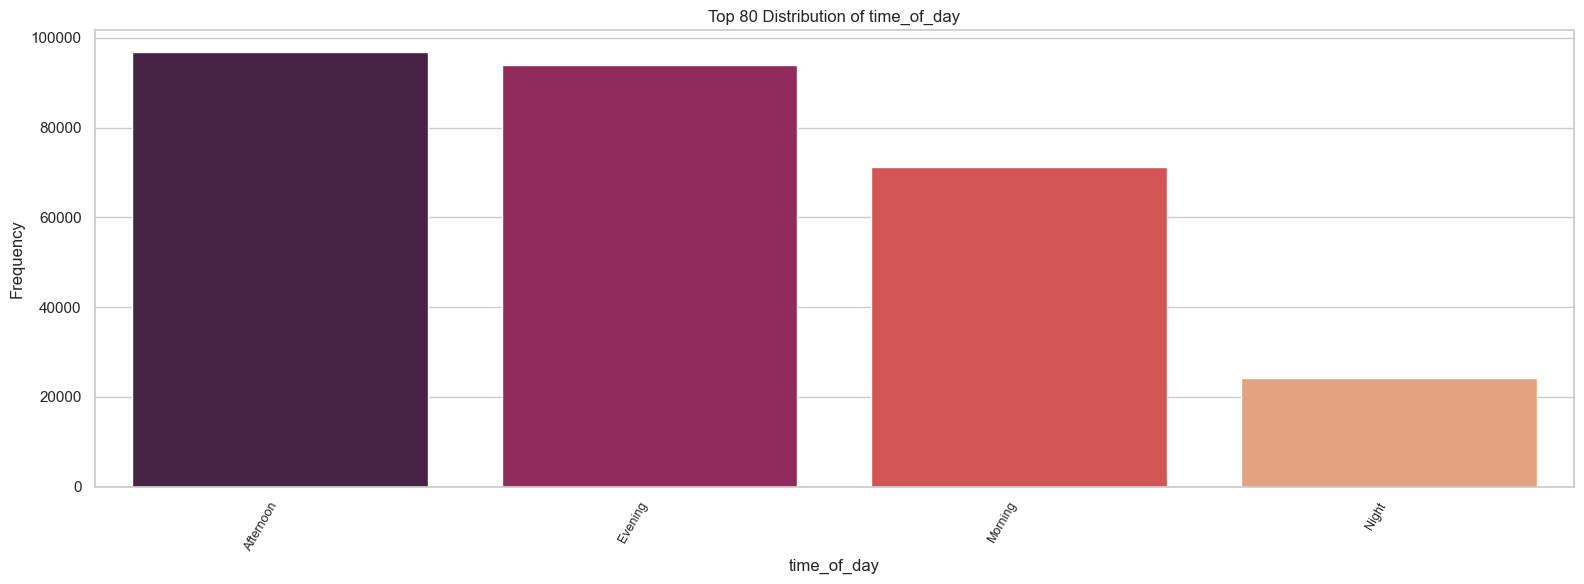

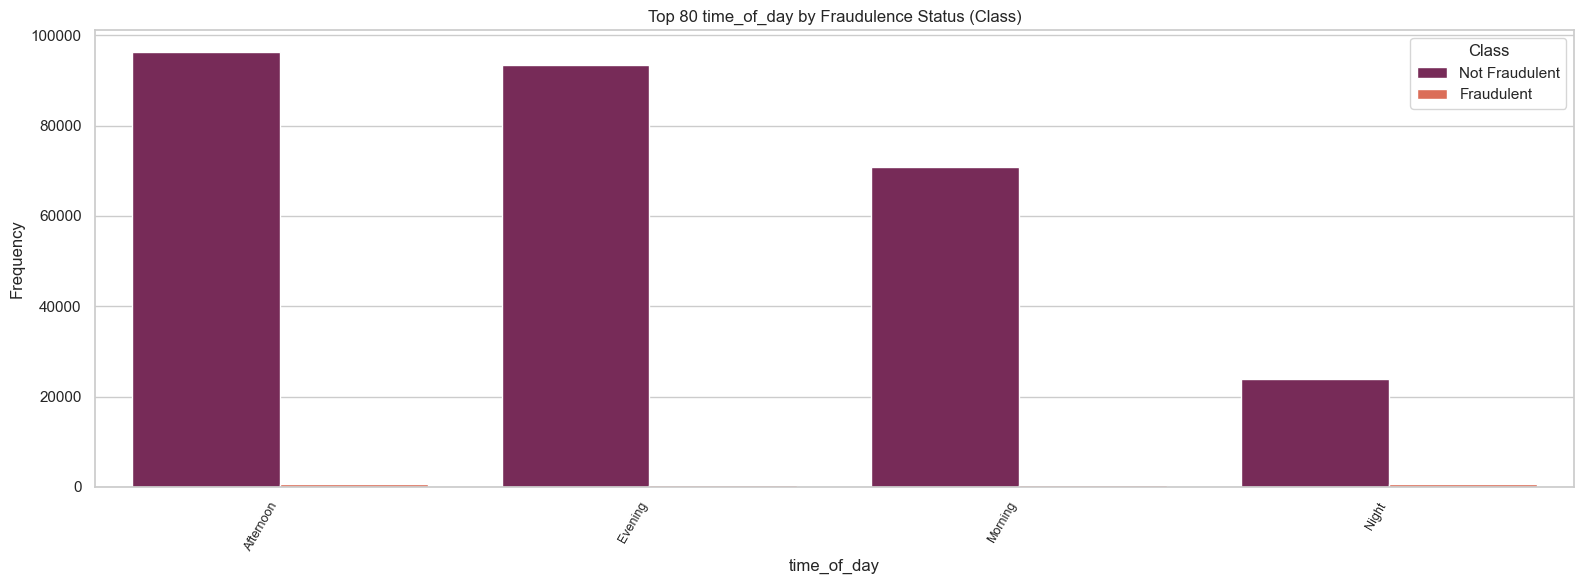

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


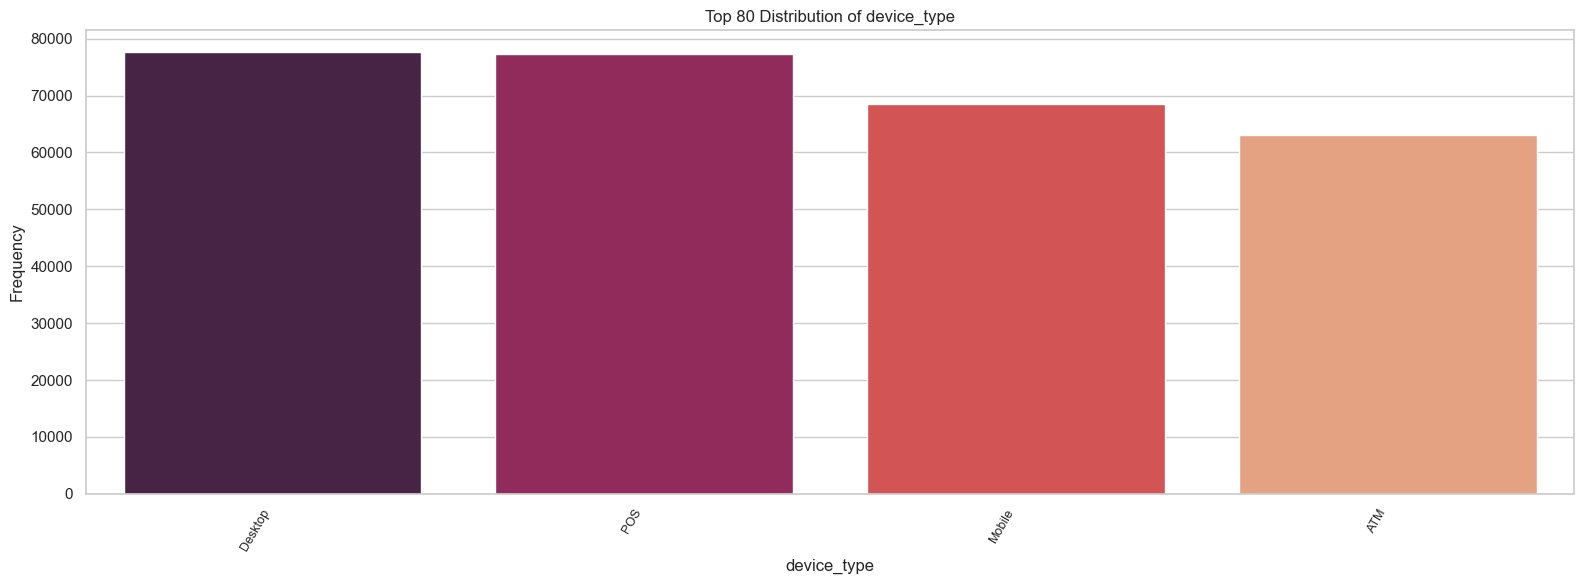

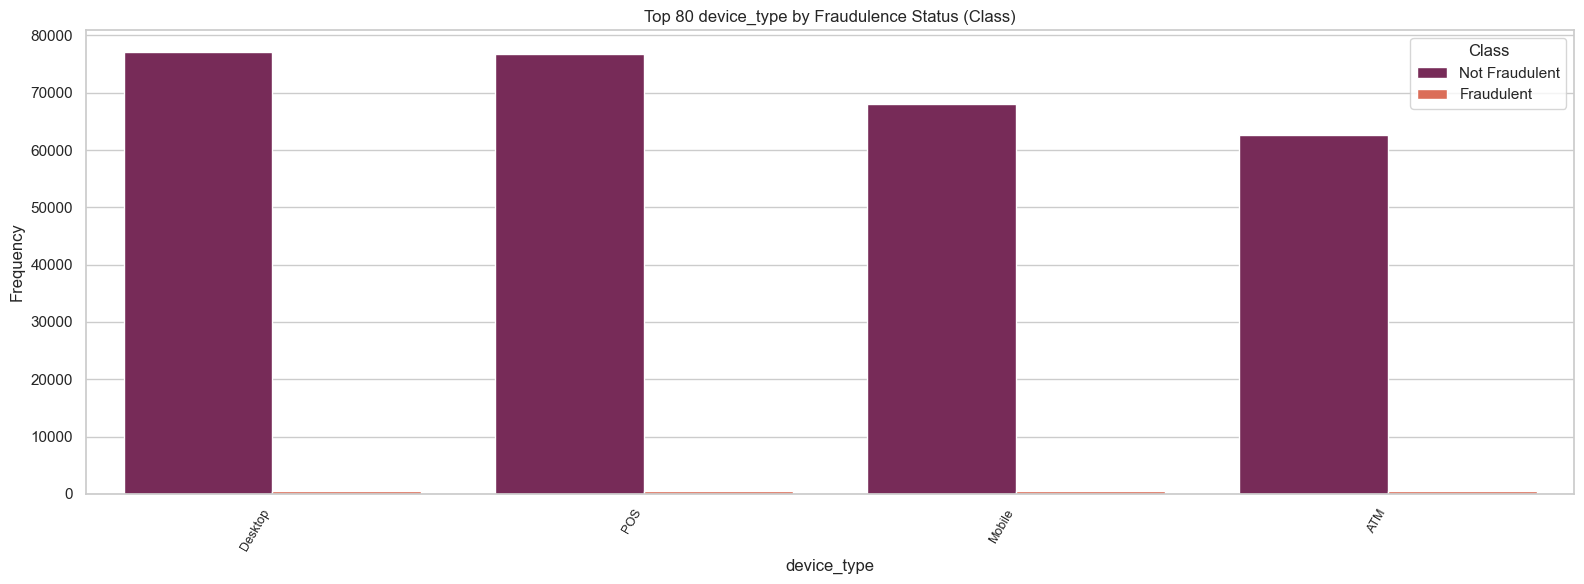

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


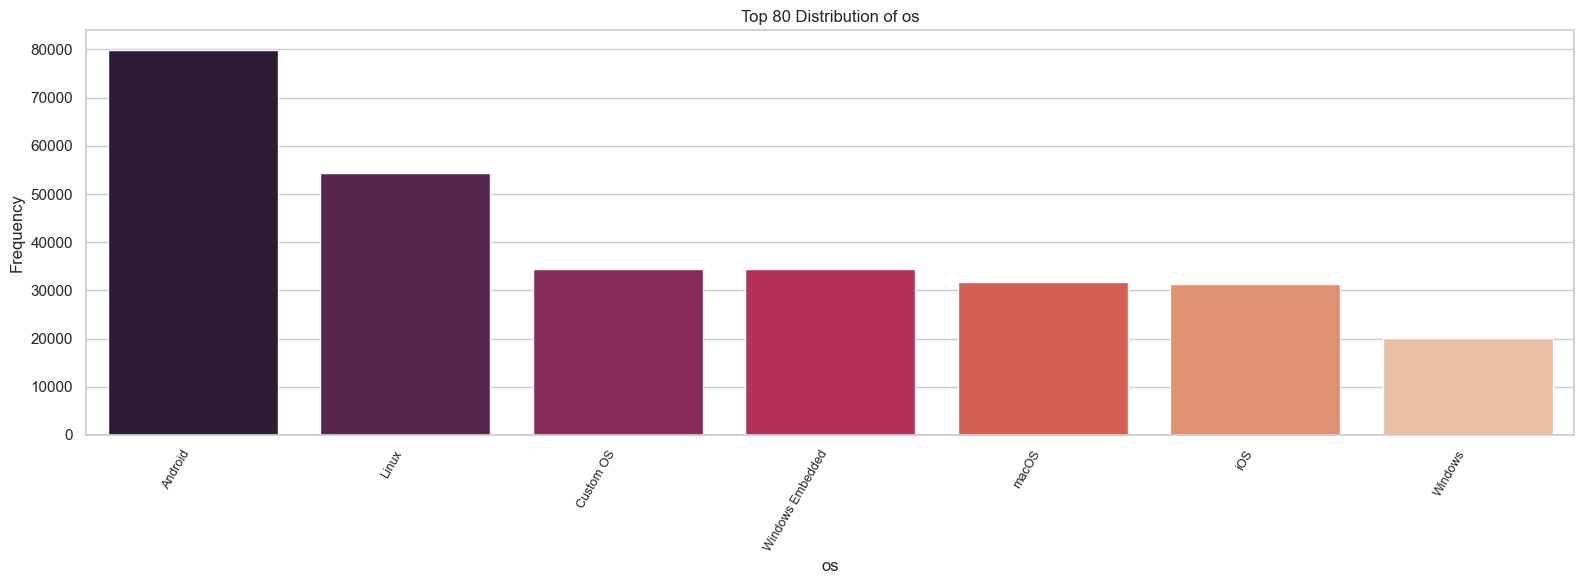

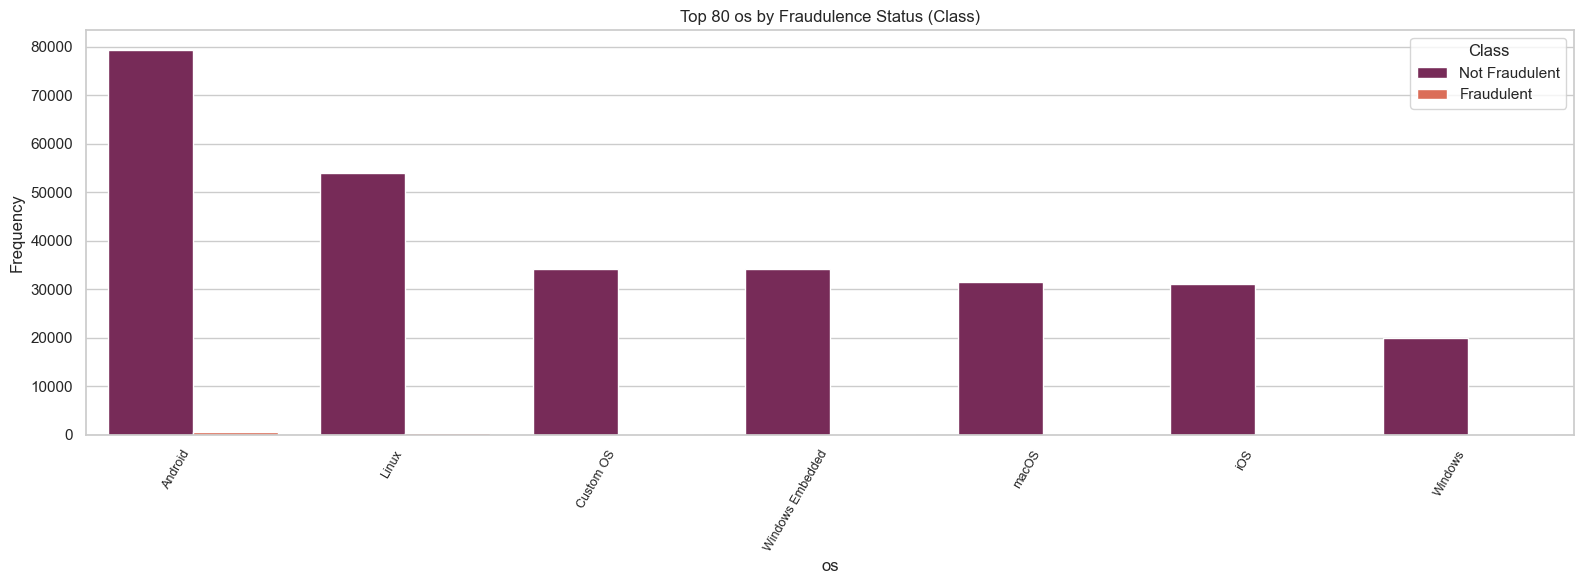

C:\Users\M6500QC\AppData\Local\Temp\ipykernel_25296\1421766817.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top, x=col, order=top30, palette="rocket")


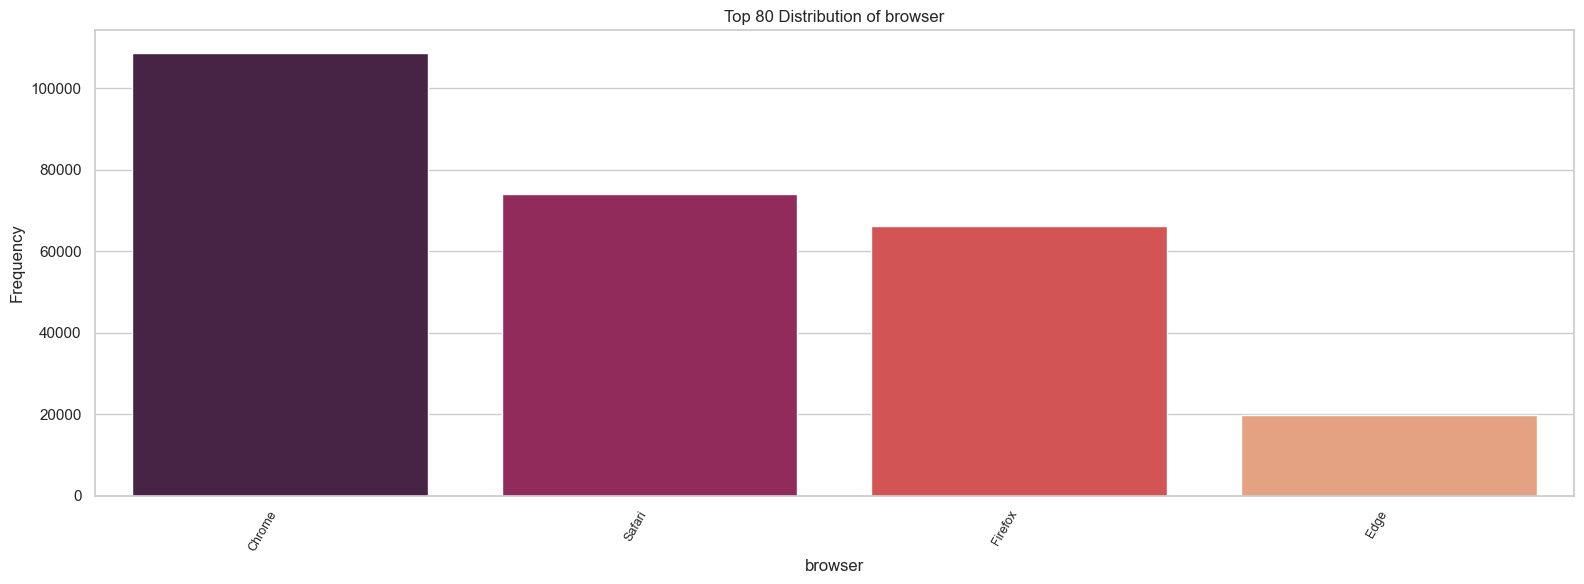

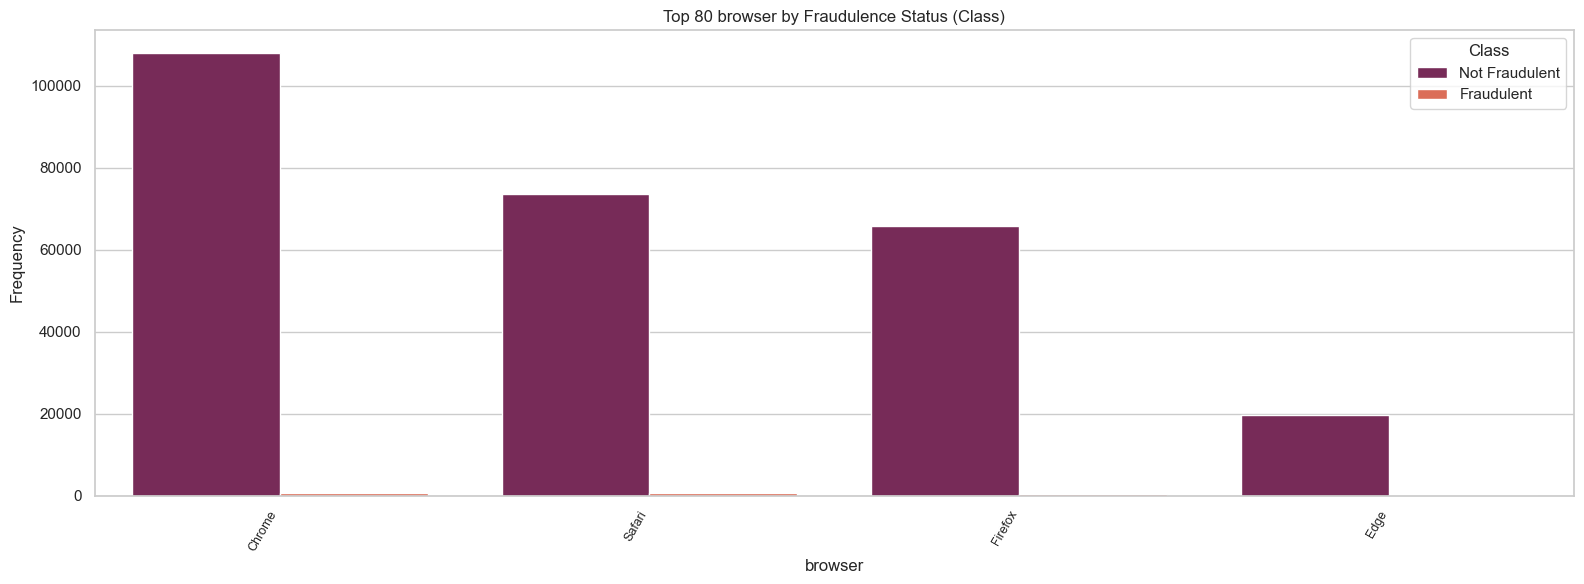

In [35]:
# From the variable info, some columns are described as binary or categorical
# but are stored as integers. We should also include these based on the description.
sns.set_theme(style="whitegrid")

for col in categoric_vars:
    # Top 30 categories by frequency
    top30 = df[col].value_counts().nlargest(80).index
    df_top = df[df[col].isin(top30)].copy()

    # 1) Distribution (top 80 only)
    plt.figure(figsize=(16, 6))
    sns.countplot(data=df_top, x=col, order=top30, palette="rocket")
    plt.title(f"Top 80 Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=60, ha="right", fontsize=9)
    plt.tight_layout()
    plt.show()

    # 2) Distribution by Class (top 80 only)
    plt.figure(figsize=(16, 6))
    sns.countplot(data=df_top, x=col, hue="Class", order=top30, palette="rocket")
    plt.title(f"Top 80 {col} by Fraudulence Status (Class)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=60, ha="right", fontsize=9)
    plt.legend(title="Class", labels=["Not Fraudulent", "Fraudulent"])
    plt.tight_layout()
    plt.show()


Categorical variables (e.g., country, device, browser, merchant) were analyzed through frequency plots focusing on the top categories and their relationship with Class, highlighting specific patterns across regions or transaction types.

### Binary Variables


Analysis for column: is_foreign_tx

Frequency of each category:


is_foreign_tx
1    285145
0      1170
Name: count, dtype: int64


Frequency by is_foreign_tx and fraudulence_status:


Class,0,1
is_foreign_tx,,
0,1163,7
1,283152,1993


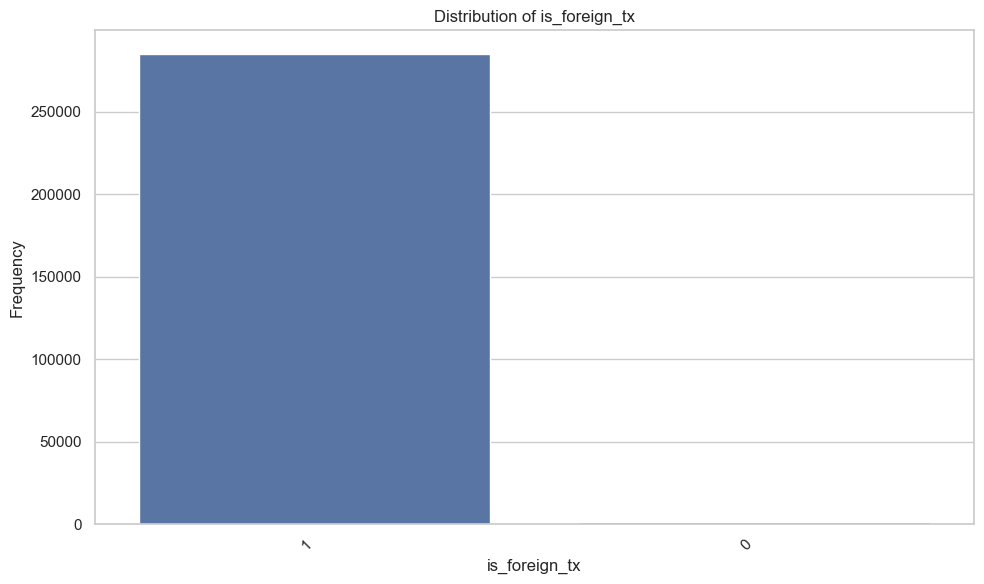

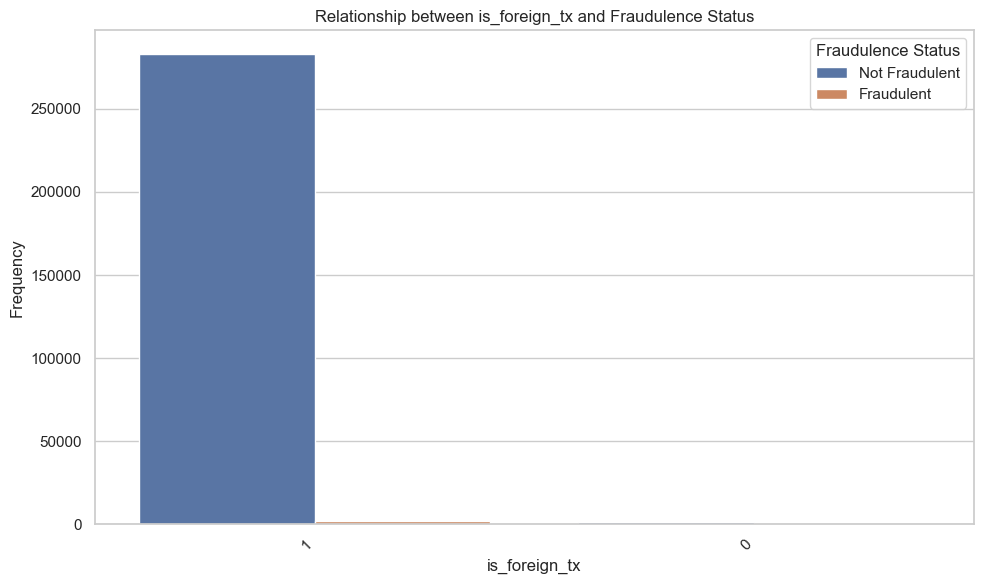


Analysis for column: is_night_tx

Frequency of each category:


is_night_tx
0    261975
1     24340
Name: count, dtype: int64


Frequency by is_night_tx and fraudulence_status:


Class,0,1
is_night_tx,,
0,260505,1470
1,23810,530


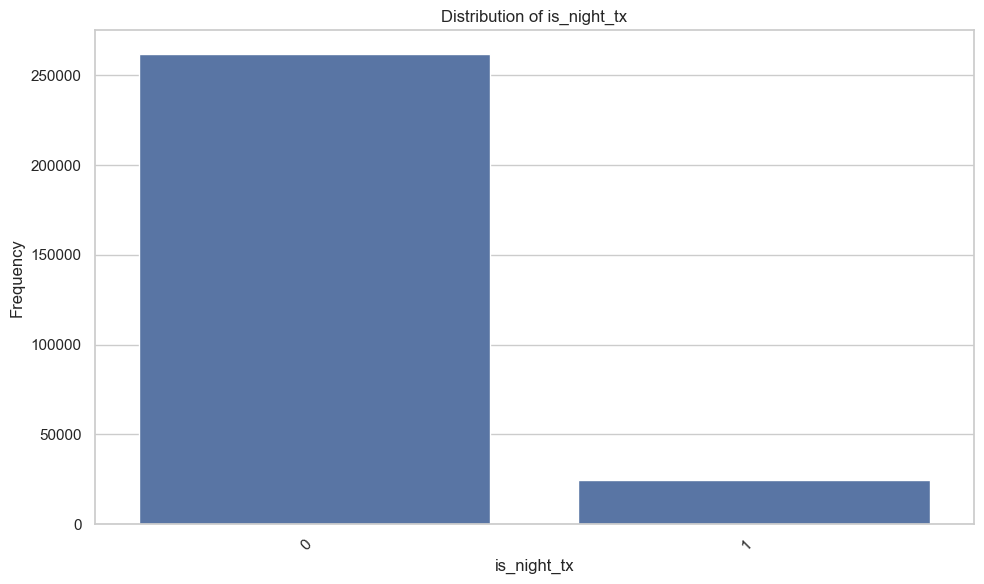

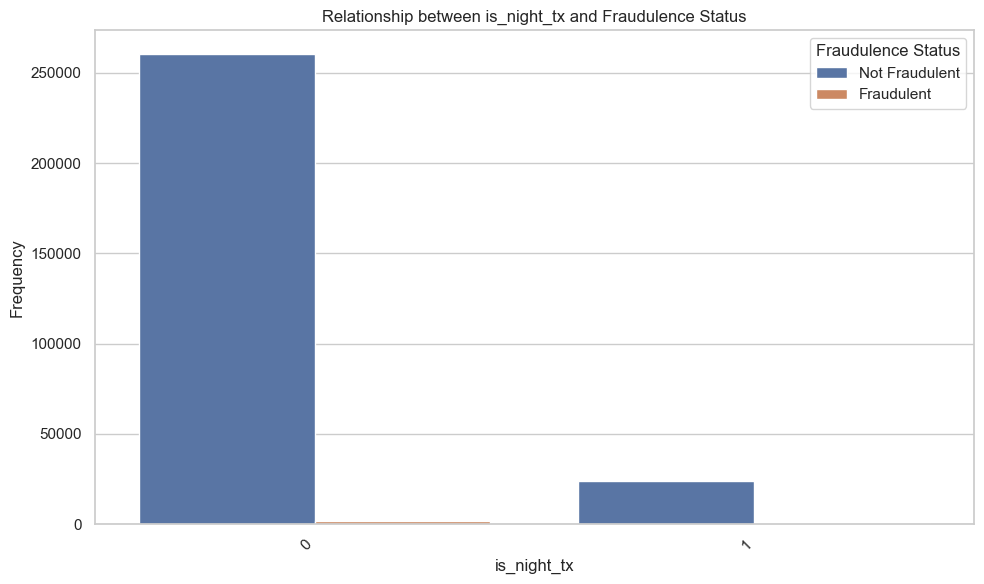


Analysis for column: is_high_amount

Frequency of each category:


is_high_amount
0    283358
1      2957
Name: count, dtype: int64


Frequency by is_high_amount and fraudulence_status:


Class,0,1
is_high_amount,,
0,281384,1974
1,2931,26


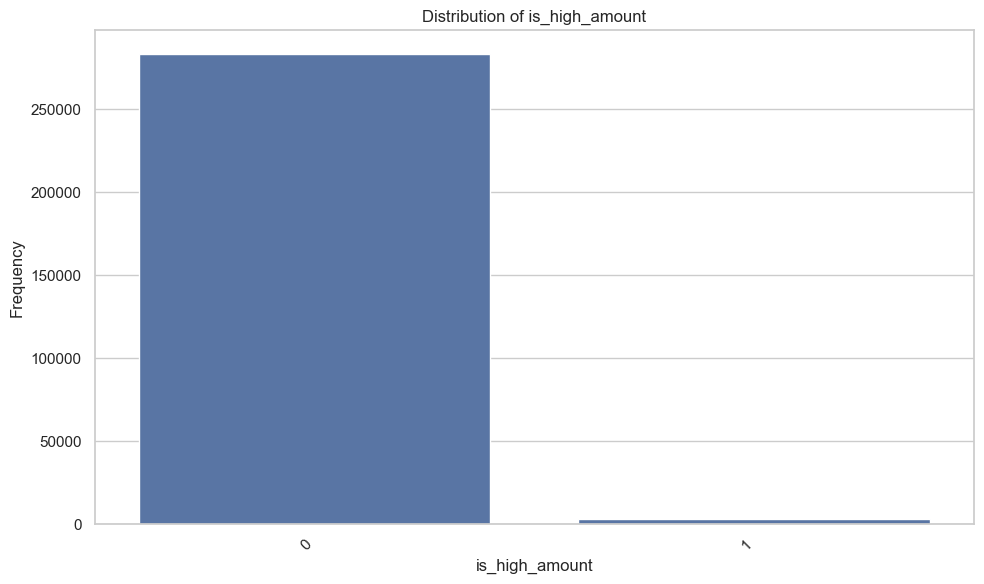

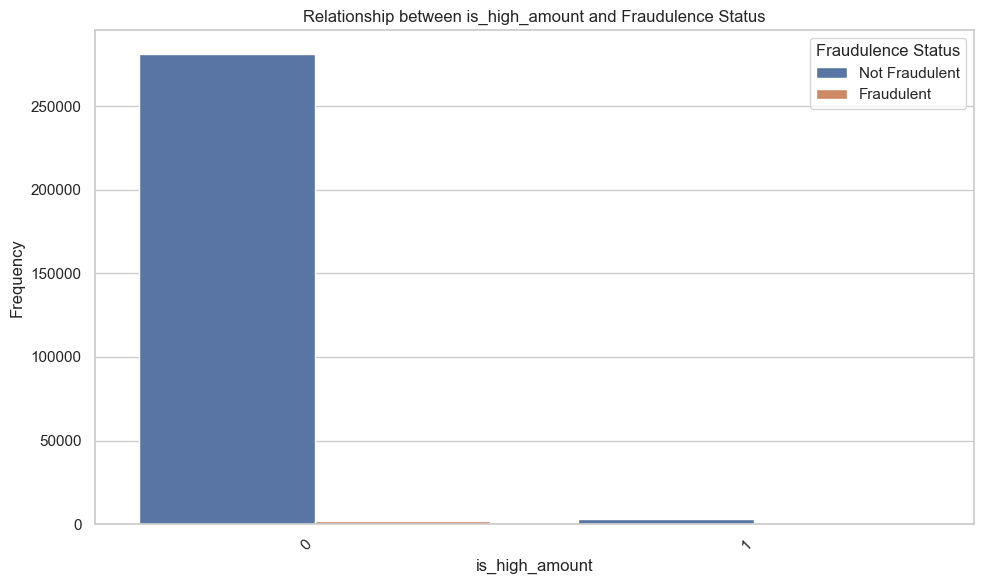


Analysis for column: day_of_week

Frequency of each category:


day_of_week
6    145647
0    140668
Name: count, dtype: int64


Frequency by day_of_week and fraudulence_status:


Class,0,1
day_of_week,,
0,139810,858
6,144505,1142


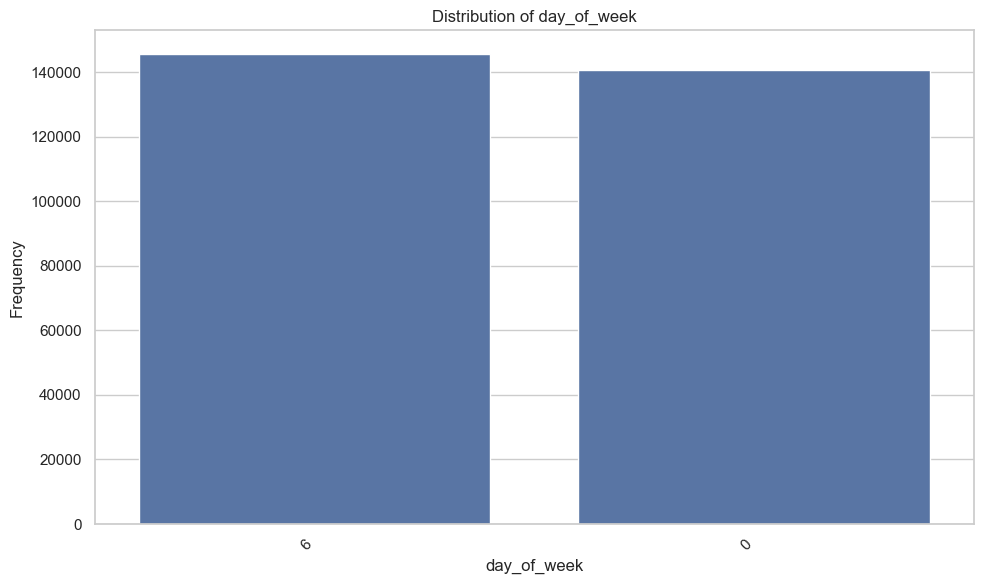

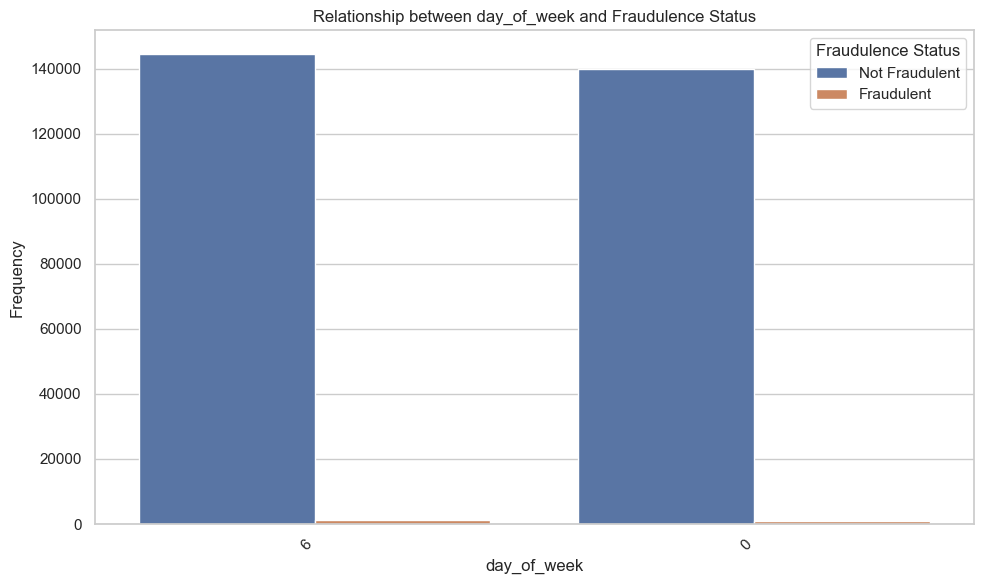


Analysis for column: is_weekend

Frequency of each category:


is_weekend
1    145647
0    140668
Name: count, dtype: int64


Frequency by is_weekend and fraudulence_status:


Class,0,1
is_weekend,,
0,139810,858
1,144505,1142


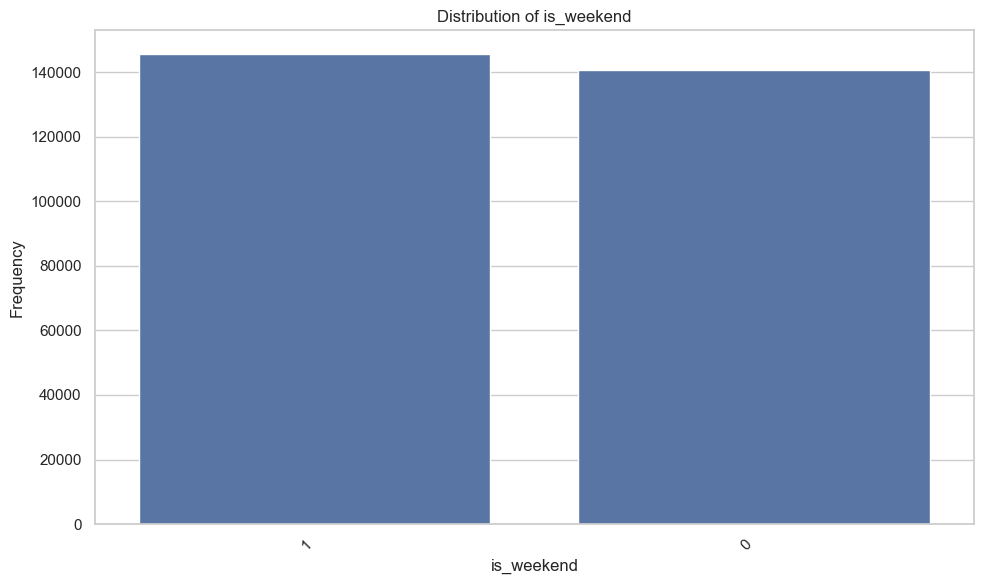

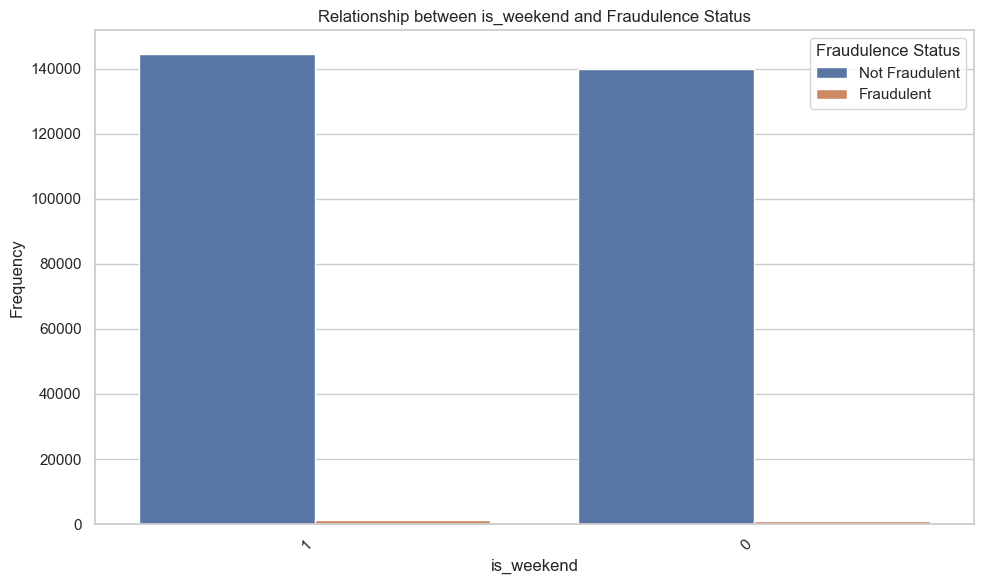


Analysis for column: is_mobile

Frequency of each category:


is_mobile
0    217844
1     68471
Name: count, dtype: int64


Frequency by is_mobile and fraudulence_status:


Class,0,1
is_mobile,,
0,216365,1479
1,67950,521


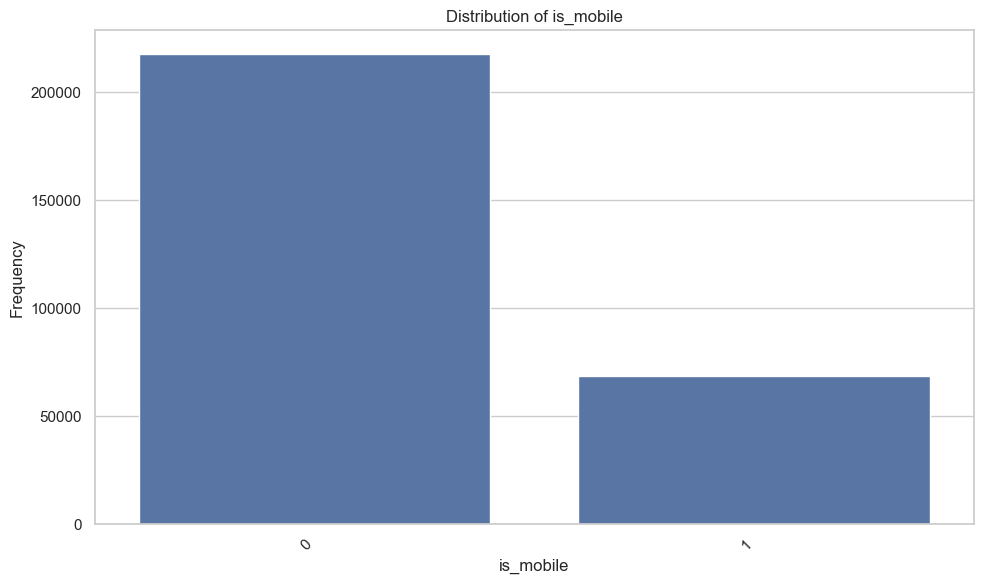

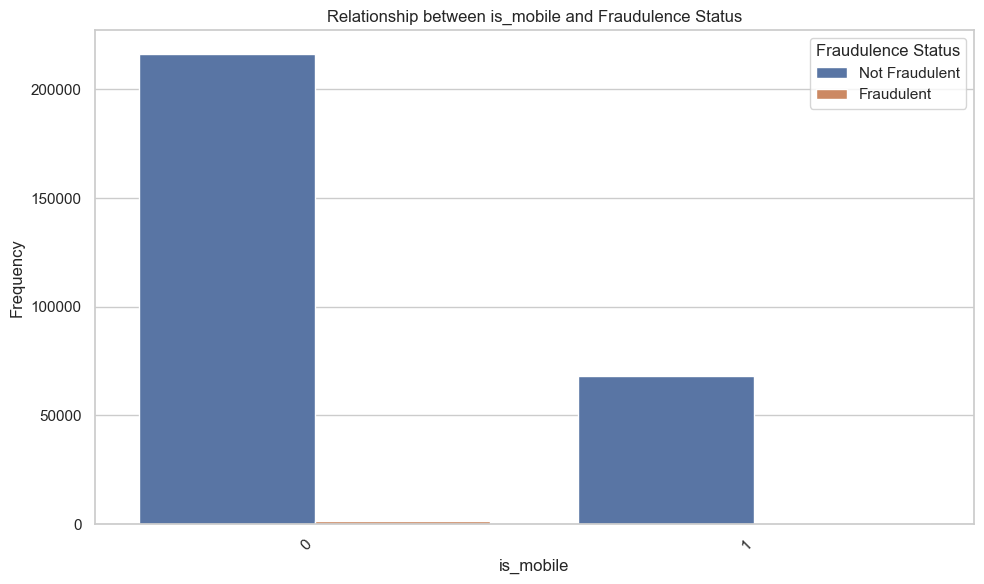

In [36]:
# From the variable info, some columns are described as binary
# but are stored as integers. We should also include these based on the description.
for col in binary_vars:
    print(f"\nAnalysis for column: {col}")


    # Calculate frequency of each category
    print("\nFrequency of each category:")
    display(df[col].value_counts())


    # Calculate frequency of each category in relation to fraudulence_status
    print(f"\nFrequency by {col} and fraudulence_status:")
    display(pd.crosstab(df[col], df['Class']))


    # Visualize distribution of binary variables
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    # Visualize relationship between binary variable and fraudulence_status
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Class', order=df[col].value_counts().index)
    plt.title(f'Relationship between {col} and Fraudulence Status')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Fraudulence Status', labels=['Not Fraudulent', 'Fraudulent'])
    plt.tight_layout()
    plt.show()


Binary variables (e.g., is_foreign_tx, is_night_tx, is_high_amount, is_weekend, is_mobile) display strong imbalances, such as the majority of transactions being foreign and only a small fraction flagged as high amount.

## Handle Missing Values

This section focuses on identifying and addressing missing data within the dataset to ensure completeness and reliability of subsequent analyses.

First, we assessed the extent of missing values across all features, calculating both absolute counts and percentages. Visual inspection through a heatmap helped reveal any patterns or dependencies in missingness.

Since the dataset was constructed using a left join with the customer table, some transactions lacked customer information. We analyzed whether these incomplete records contained fraudulent transactions and confirmed that they did not. Consequently, these 247 rows were safely removed.

For the remaining missing values, categorical features such as zip_code, browser, email, and phone were imputed with the placeholder "Unknown".

,Missing Values,Percentage
zip_code,28632,10.000175
browser,17356,6.061855
email,14461,5.050731
phone,5863,2.047745
name,247,0.086269
age,247,0.086269
customer_country,247,0.086269
credit_score,247,0.086269
join_date,247,0.086269


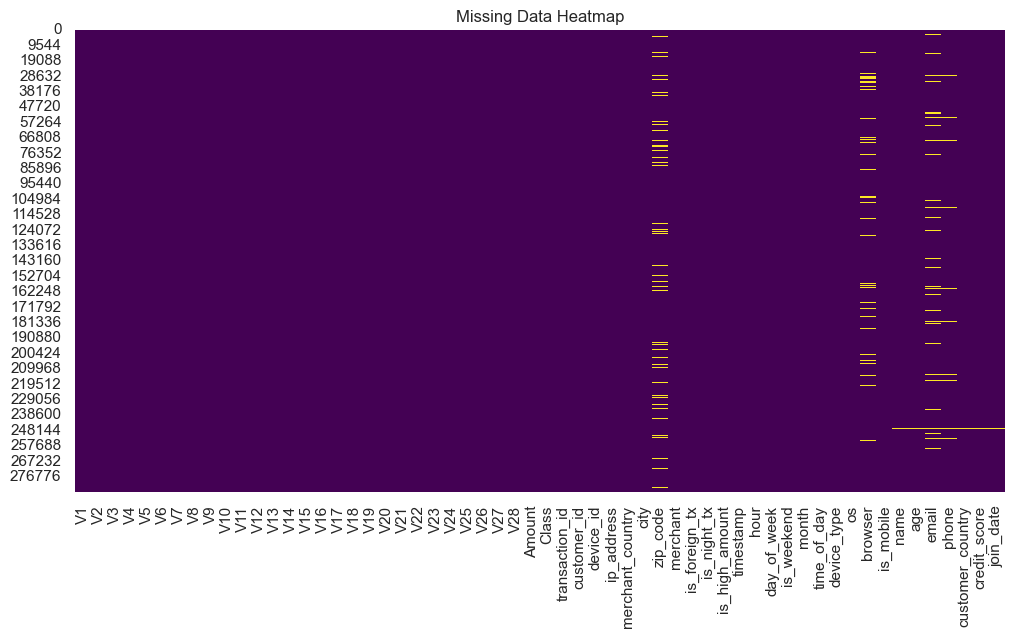

In [37]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
display(missing_info)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

Class
0    247
Name: count, dtype: int64


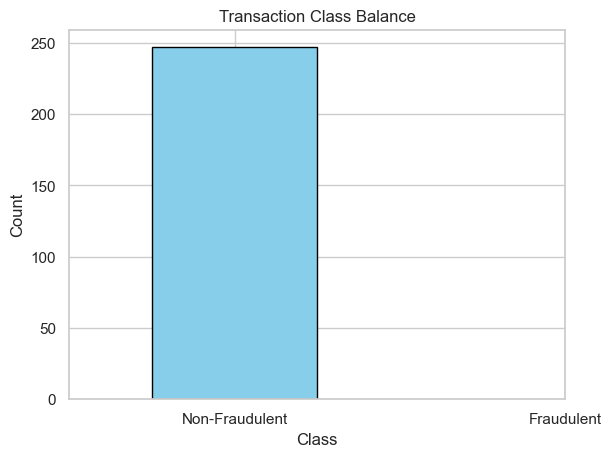

In [38]:
# Since we have performed a left join when merging the dataset customer in order
# to not get rid of transactions without solid reasons we are going to check wether
# the rows that have been left without customer information consist of any fraudulent transactions
no_customer_df = df[df['name'].isna()]
print(no_customer_df["Class"].value_counts())
no_customer_df["Class"].value_counts().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Transaction Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Non-Fraudulent", "Fraudulent"], rotation=0)
plt.show()

In [39]:
# Since there are no fraudulent transactions we get rid of these 247 rows
df = df.dropna(subset=['name'])

In [40]:
# We check missing values again
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
display(missing_info)

,Missing Values,Percentage
zip_code,28549,9.979795
browser,17341,6.061845
email,14214,4.968749
phone,5616,1.963170


In [41]:
df["zip_code"] = df["zip_code"].fillna('Unknown')
df["browser"] = df["browser"].fillna('Unknown')
df["email"] = df["email"].fillna('Unknown')
df["phone"] = df["phone"].fillna('Unknown')

## Outliers analysis

Outlier detection was performed to identify anomalous values that could distort the statistical properties of the dataset or bias predictive modeling. Using the Interquartile Range (IQR) method, we quantified the number and percentage of outliers for each numerical feature, summarizing them in a dedicated table.

In addition, negative values were checked across all numerical variables, and none were deemed invalid based on the context of the data. The variable age was validated to ensure all entries fell within realistic bounds (18 to 79 years old).

Finally, categorical and binary variables were examined to confirm that all encoded categories and binary indicators (0/1) aligned with their expected domains, ensuring overall data quality and consistency before correlation and feature analysis.

### Numeric Variables

In [42]:
outlier_summary = []

for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append((col, n_outliers, n_outliers/len(df)*100))

outlier_df = pd.DataFrame(outlier_summary, columns=["Feature", "Outliers", "% Outliers"]).sort_values(by="% Outliers", ascending=False)
display(outlier_df.head(15))

,Feature,Outliers,% Outliers
26,V27,39666,13.865934
28,Amount,32038,11.199435
27,V28,30830,10.777158
19,V20,28214,9.862690
7,V8,24624,8.607744
5,V6,23320,8.151908
22,V23,18890,6.603325
11,V12,16290,5.694450
13,V14,15190,5.309926
20,V21,15169,5.302585


In [43]:
# We check for any negative values in numeric variables
neg_check = (numeric_df < 0).any()
print("Columns with negative values:")
print(neg_check[neg_check == True])

Columns with negative values:
V1     True
V2     True
V3     True
V4     True
V5     True
V6     True
V7     True
V8     True
V9     True
V10    True
V11    True
V12    True
V13    True
V14    True
V15    True
V16    True
V17    True
V18    True
V19    True
V20    True
V21    True
V22    True
V23    True
V24    True
V25    True
V26    True
V27    True
V28    True
dtype: bool


In [44]:
# We make sure all the ages are in reasonable intervales
print(df.loc[df["age"] < 18])
print(df.loc[df["age"] > 100])
# We see age ranges between 18 to 79

Empty DataFrame
Columns: [V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class, transaction_id, customer_id, device_id, ip_address, merchant_country, city, zip_code, merchant, is_foreign_tx, is_night_tx, is_high_amount, timestamp, hour, day_of_week, is_weekend, month, time_of_day, device_type, os, browser, is_mobile, name, age, email, phone, customer_country, credit_score, join_date]
Index: []

[0 rows x 58 columns]
Empty DataFrame
Columns: [V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, Class, transaction_id, customer_id, device_id, ip_address, merchant_country, city, zip_code, merchant, is_foreign_tx, is_night_tx, is_high_amount, timestamp, hour, day_of_week, is_weekend, month, time_of_day, device_type, os, browser, is_mobile, name, age, email, phone, customer_country, credit_score, join_date]
Index: []

### Categorical and Binary variables

In [45]:
# We make sure categorical variables have their corresponding categories
# and binary variables only have 0 1 values
cat_bin_df = pd.concat([categoric_df, binary_df], axis=1)

for col in cat_bin_df:
    print(f"\nColumn: {col}")
    print("Data type:", df[col].dtype)
    unique_values = df[col].unique()[:10]
    print("Unique values:", unique_values)
    print("Number of unique values:", df[col].nunique())
    print("Missing values:", df[col].isna().sum())



Column: ip_address
Data type: object
Unique values: ['83.63.232.13' '89.213.161.51' '140.231.3.186' '40.46.209.108'
 '174.155.184.108' '192.170.58.147' '7.127.18.29' '124.40.2.172'
 '9.224.84.200' '118.144.65.50']
Number of unique values: 286056
Missing values: 0

Column: merchant_country
Data type: object
Unique values: ['Australia' 'France' 'Germany' 'Italy' 'USA' 'UK' 'Spain' 'Japan']
Number of unique values: 8
Missing values: 0

Column: city
Data type: object
Unique values: ['Perth' 'Lyon' 'Berlin' 'Melbourne' 'Sydney' 'Venice' 'Milan' 'New York'
 'Edinburgh' 'Rome']
Number of unique values: 25
Missing values: 0

Column: zip_code
Data type: object
Unique values: ['Unknown' 57376.0 19277.0 93260.0 97401.0 41433.0 24803.0 97673.0 80906.0
 14782.0]
Number of unique values: 91908
Missing values: 0

Column: merchant
Data type: object
Unique values: ['Davis-Parker' 'Garcia-Mitchell' 'Mccann-Snow' 'Jones Inc'
 'Rodriguez Inc' 'Cisneros, Chapman and Ortiz' 'Peck-Peters'
 'Zhang-Bridges' '

## Correlation analysis (Multivariate EDA)

After exploring each variable individually, this section focuses on examining the relationships between numerical features.  
Understanding correlations helps identify redundant variables (those that provide similar information) and detect potential dependencies between features that may influence the model’s performance.  
First, we compute the correlation among all numeric variables to visualize how strongly they are related to each other.

In [46]:
# We frequency encode our nominal features
corr_df = pd.concat([numeric_df, categoric_df, binary_df, target_df], axis=1)
for col in categoric_vars:
    freq_map = corr_df[col].value_counts(normalize=True)
    corr_df[col] = corr_df[col].map(freq_map)

categoric_encoded_df = corr_df[categoric_vars]

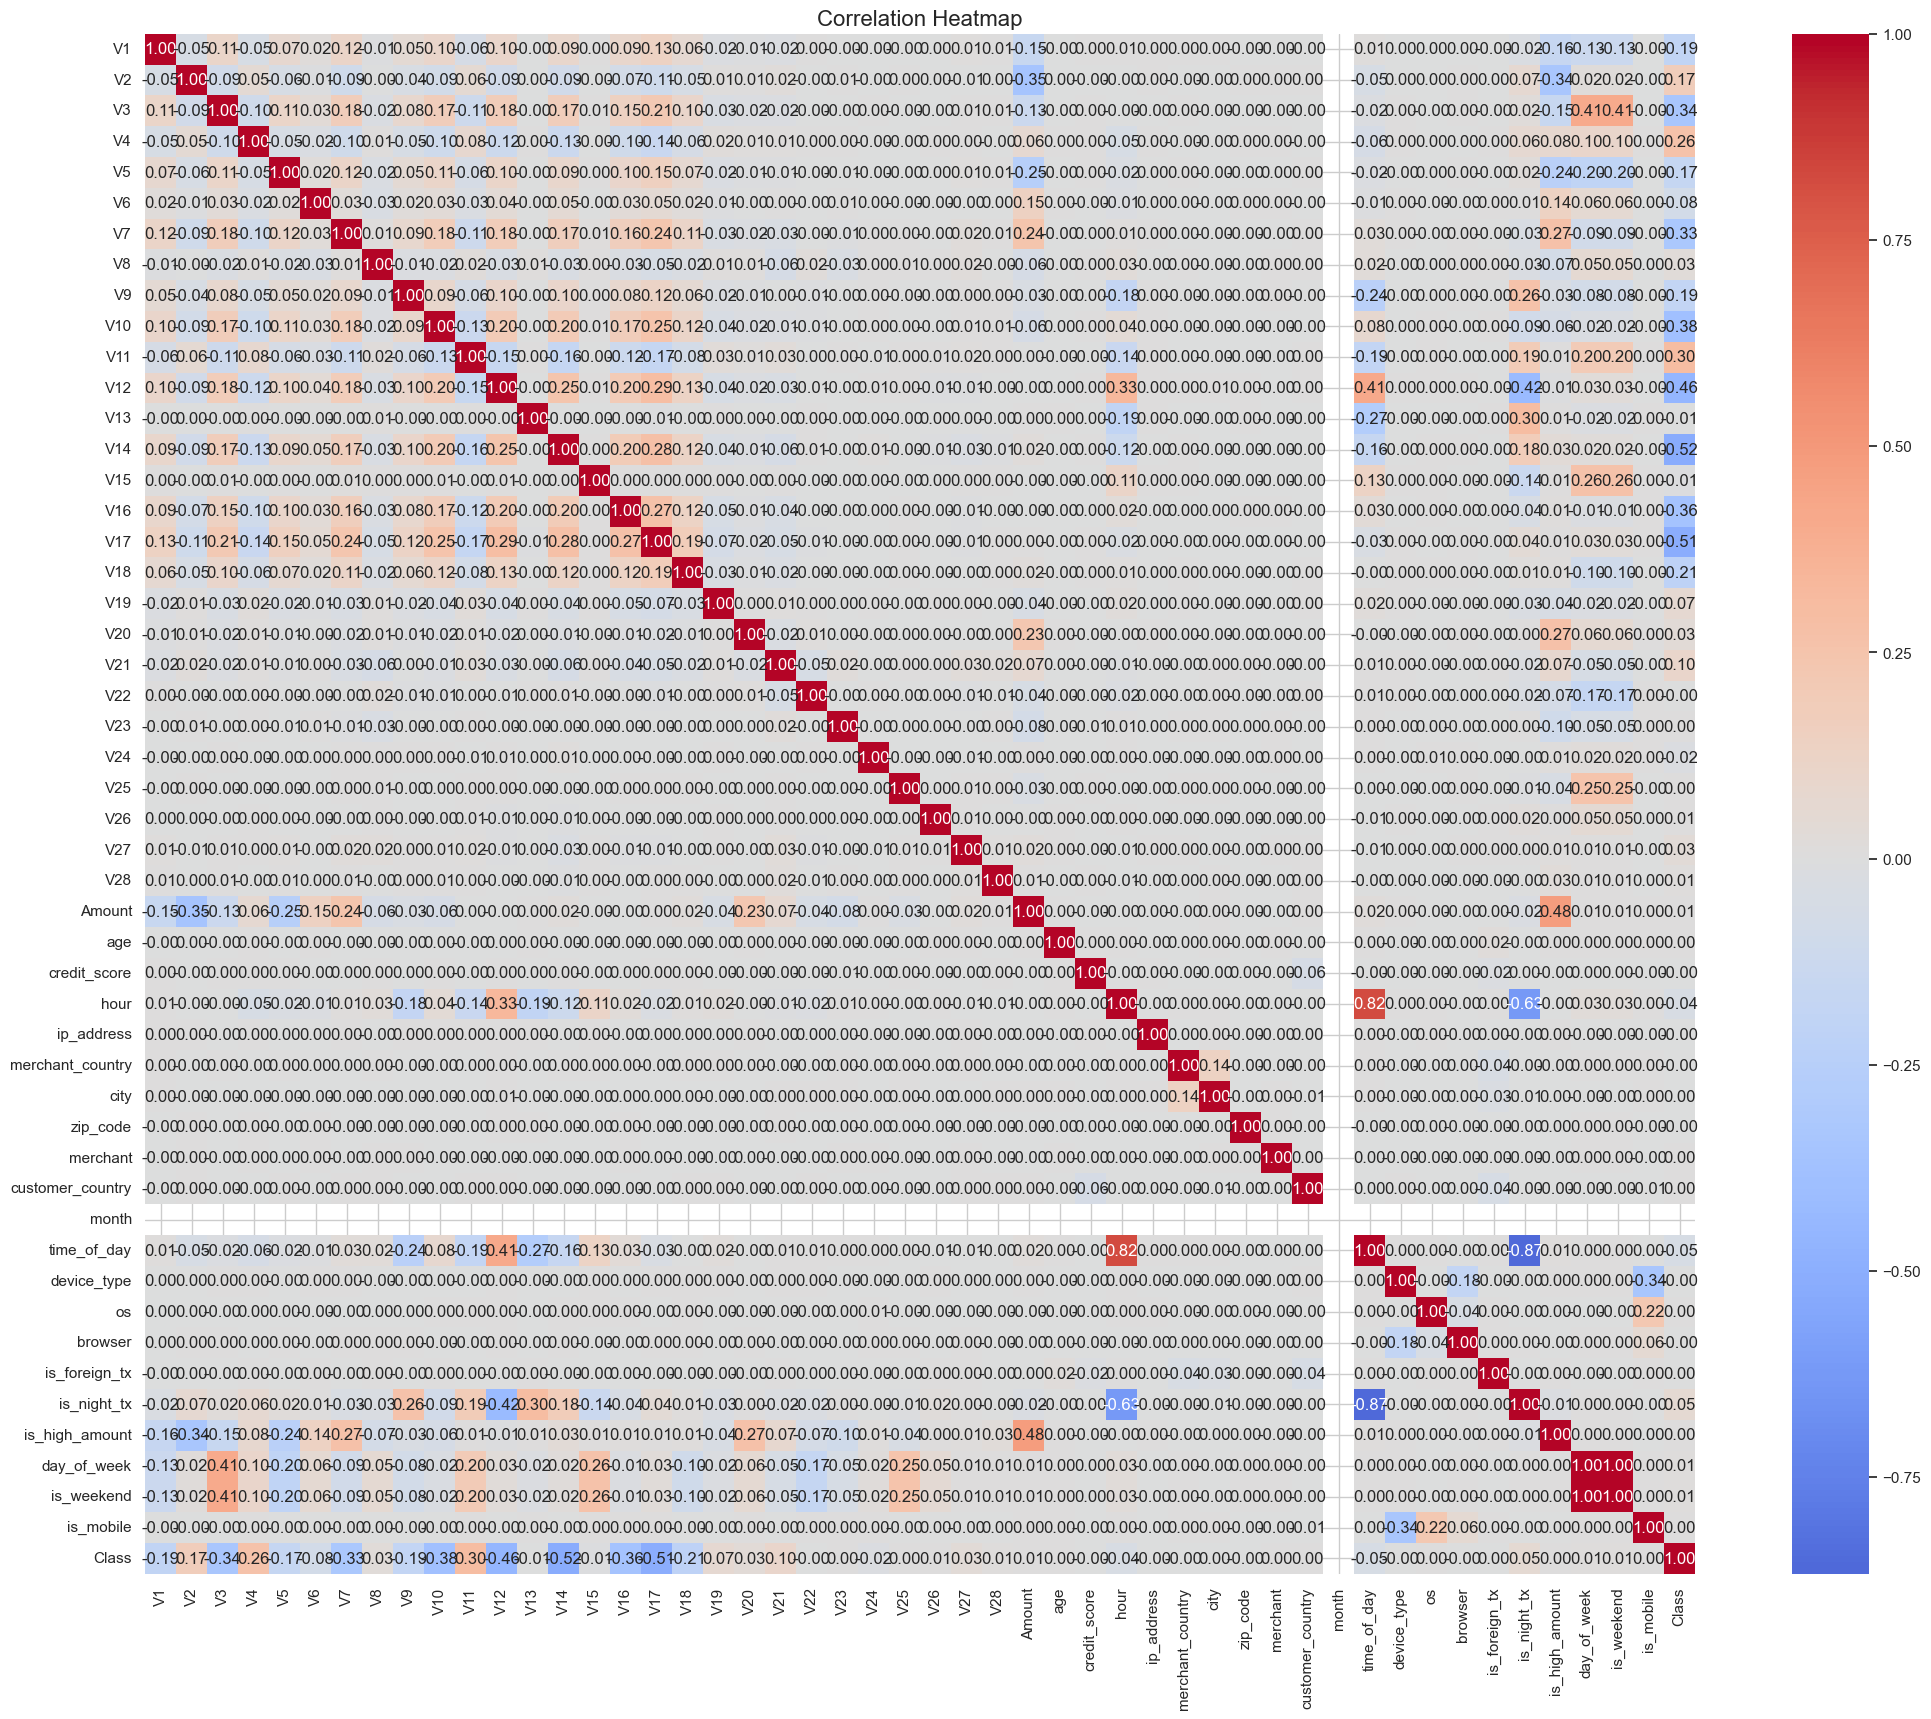

In [47]:
# We compute the correlation matrix
plt.figure(figsize=(25,20))
corr_matrix = corr_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

,corr_with_Class
V14,-0.520768
V17,-0.505826
V12,-0.456031
V10,-0.384409
V16,-0.358911
V3,-0.341601
V7,-0.325591
V11,0.296992
V4,0.257155
V18,-0.212860


,corr_with_Class
age,0.002940
credit_score,-0.002856
os,0.002320
is_high_amount,0.002217
merchant,0.002020
merchant_country,-0.001639
zip_code,-0.001516
V23,0.001459
customer_country,0.001420
device_type,-0.001010


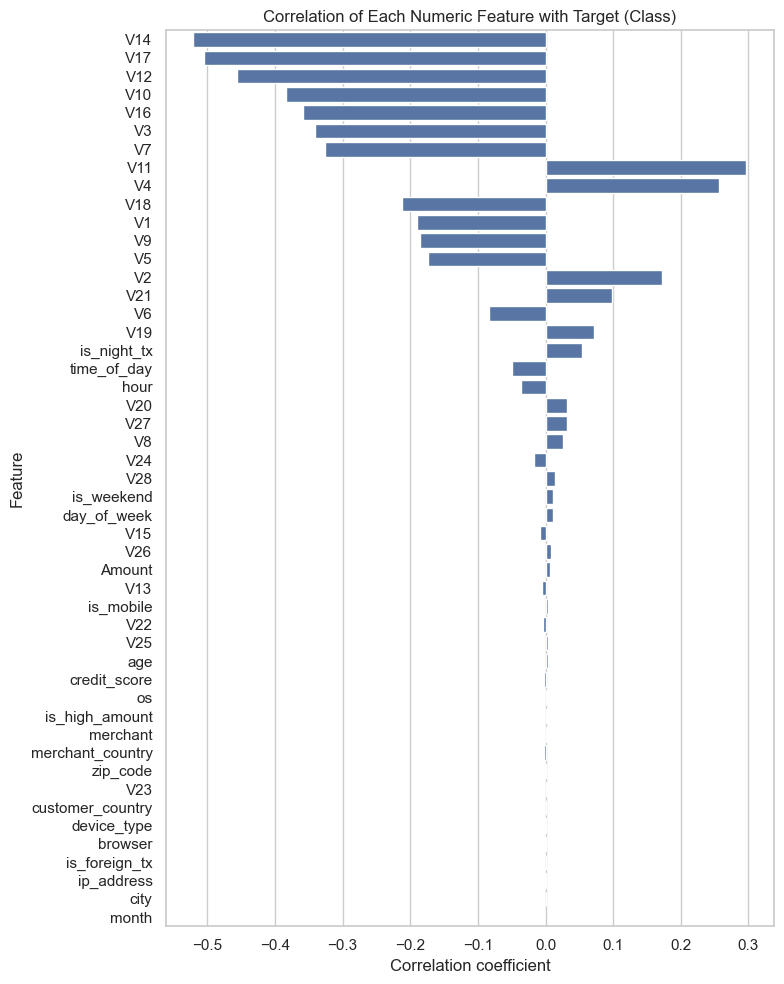

In [48]:
# Keep only numeric columns (Class must be numeric 0/1)
# Correlation matrix and correlation vs target
target_corr = corr_matrix['Class'].drop(labels=['Class'])

# Sort by absolute correlation magnitude (most informative first)
target_corr_sorted = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

# Show top/bottom features
display(target_corr_sorted.head(15).to_frame('corr_with_Class'))
display(target_corr_sorted.tail(15).to_frame('corr_with_Class'))

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(
    x=target_corr_sorted.values,
    y=target_corr_sorted.index
)
plt.title("Correlation of Each Numeric Feature with Target (Class)")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Study the assumed PCA variables

Now we take a look into the variables we suspect come from a PCA.

In [49]:
pca_vars = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
pca_df = df[pca_vars]

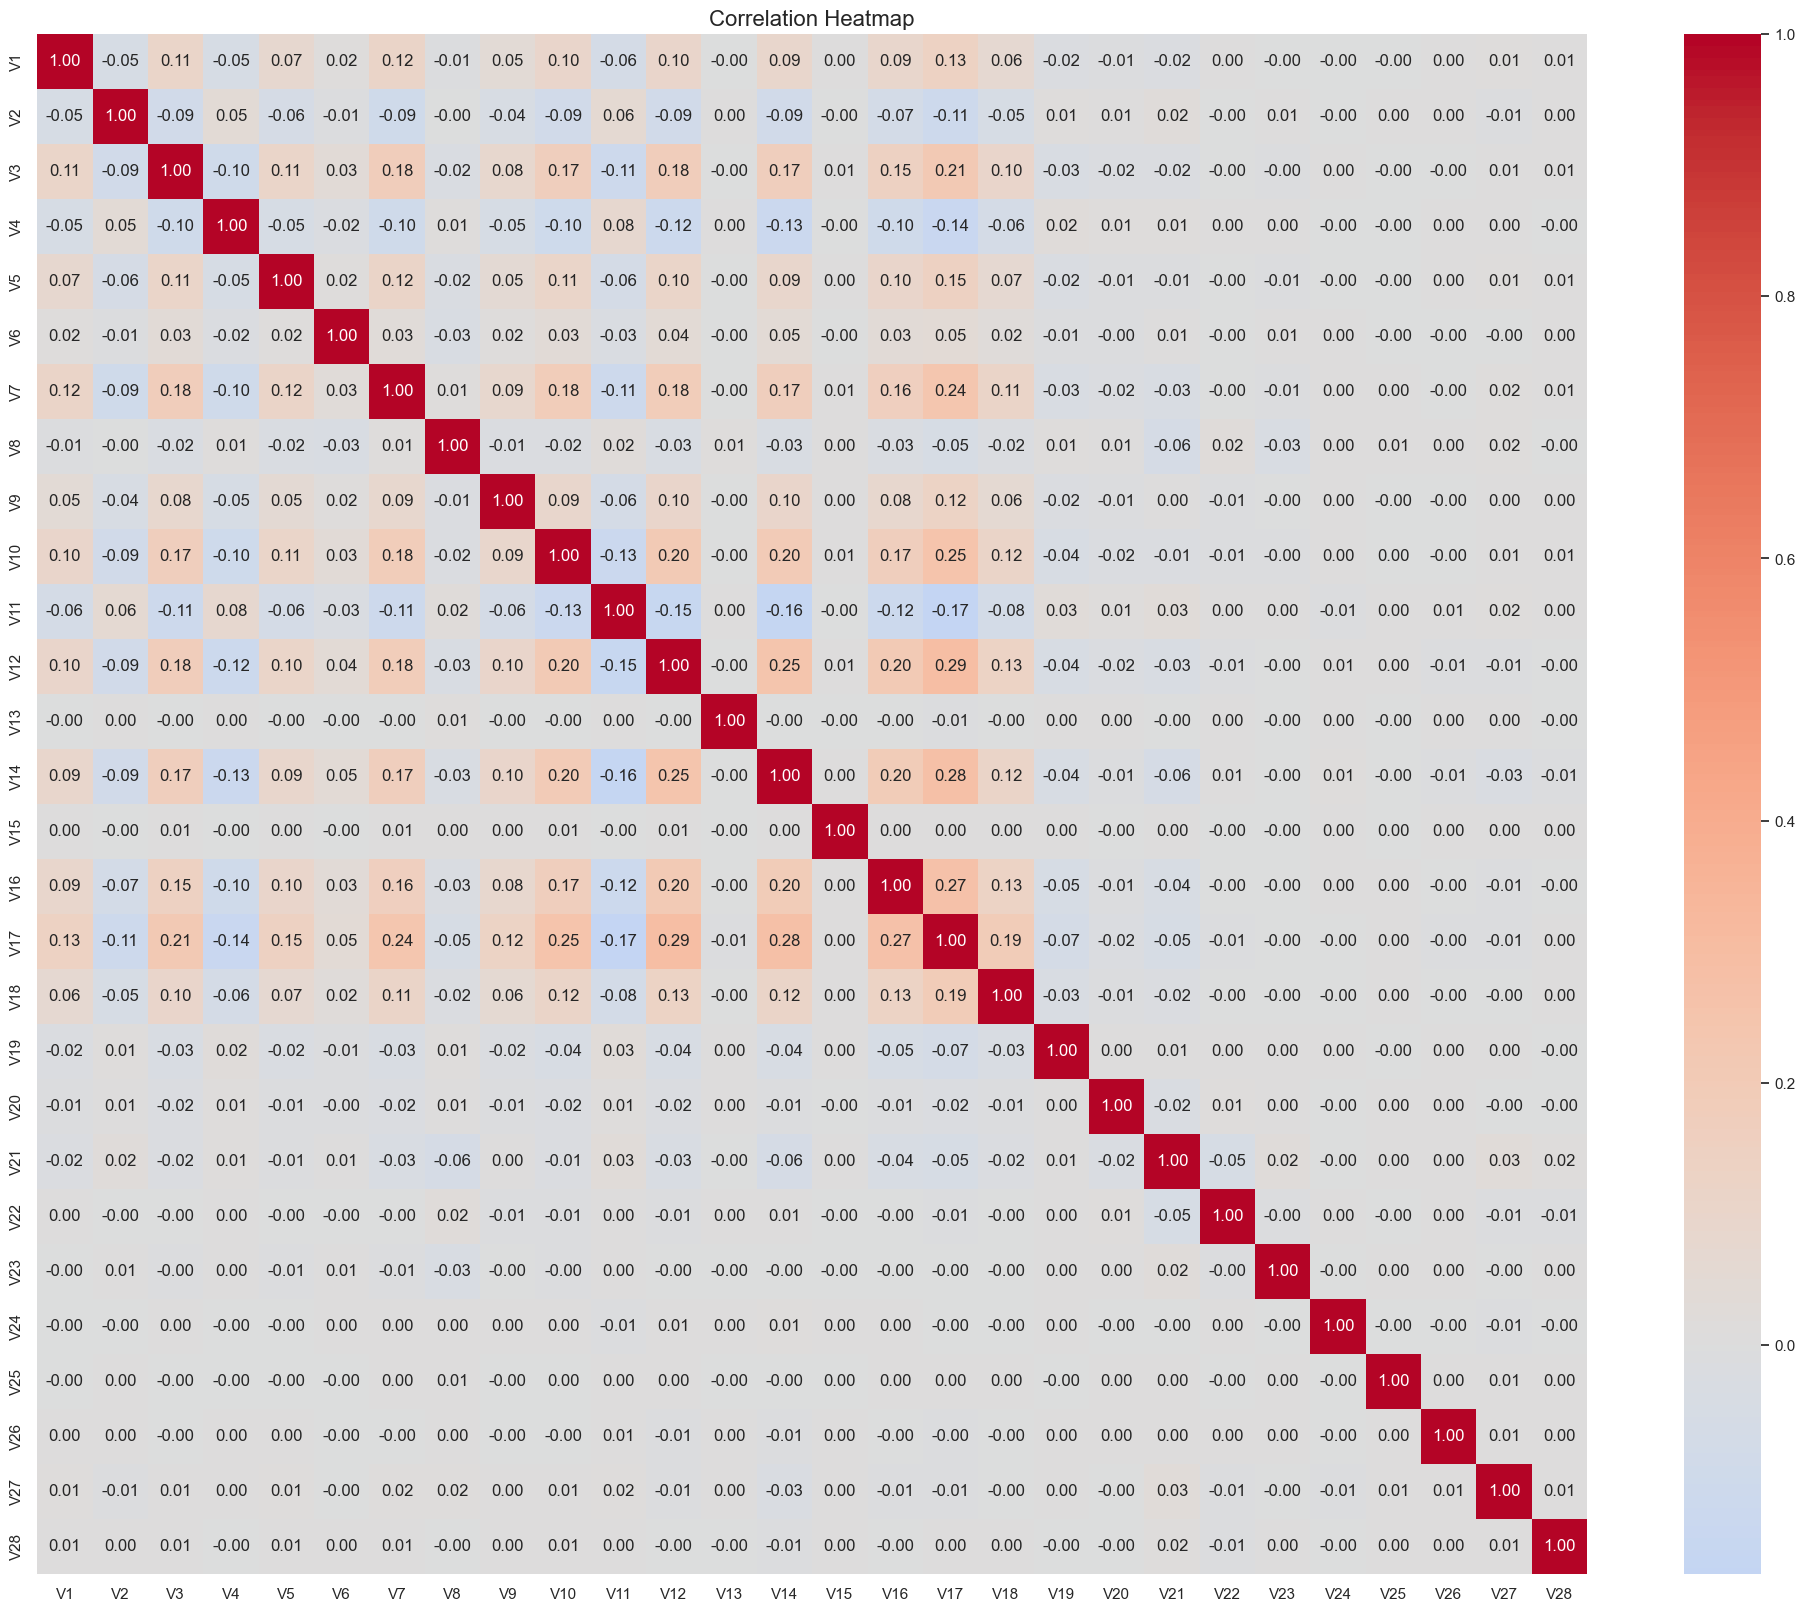

In [50]:
# We compute the correlation matrix
plt.figure(figsize=(25,20))
corr_matrix = pca_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [51]:
# We check weather the variances are in order
pca_df.var().sort_values(ascending=False)

V1     4.133678
V2     2.862047
V3     2.769604
V4     2.146659
V5     2.072729
V7     1.914833
V6     1.792298
V8     1.652815
V10    1.463027
V12    1.318099
V14    1.277377
V9     1.265459
V17    1.211633
V11    1.152255
V13    0.992174
V16    0.936607
V15    0.839074
V18    0.769882
V19    0.674097
V21    0.629308
V20    0.599954
V22    0.536118
V23    0.398532
V24    0.366461
V25    0.273272
V26    0.232608
V27    0.172595
V28    0.110285
dtype: float64

We can conclude that they do in fact come from a PCA

# **4. Feature Engineering**

In [52]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'transaction_id', 'customer_id', 'device_id', 'ip_address',
       'merchant_country', 'city', 'zip_code', 'merchant', 'is_foreign_tx',
       'is_night_tx', 'is_high_amount', 'timestamp', 'hour', 'day_of_week',
       'is_weekend', 'month', 'time_of_day', 'device_type', 'os', 'browser',
       'is_mobile', 'name', 'age', 'email', 'phone', 'customer_country',
       'credit_score', 'join_date'],
      dtype='object')

### **Temporal & Cyclical feature engineering**

Since our dataset spans only two days, we focus on **short-term temporal patterns** rather than weekly or monthly seasonality.  
This means we’ll engineer features that capture *hourly behavior, time-of-day, night activity,* and *account tenure (days in bank)* — all of which can help detect abnormal transaction timing.

We will:
- Create a variable to know how many days have been the user in the bank
- Encode hour as cyclical variables (sin/cos)  
- Create flags for **night**, **morning**, **afternoon**, and **evening**  
- Use **account tenure (`days_in_bank`)** to describe customer maturity  

In [53]:
#eliminate month since all transactions belong to the same month
df = df.drop(columns=['month'])
categoric_vars.remove('month')
categoric_df = categoric_df.drop(columns= ['month'])
categoric_encoded_df = categoric_encoded_df.drop(columns= ['month'])

#elminate day_of_the_week since it is the same as is_weekend because the dataset has only 2 days
df = df.drop(columns = ['day_of_week'])
binary_vars.remove('day_of_week')
binary_df = binary_df.drop(columns= ['day_of_week'])

In [54]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["join_date"] = pd.to_datetime(df["join_date"], errors="coerce")

today = pd.Timestamp.today().normalize()
df["days_in_bank"] = (today - df["join_date"]).dt.days

df = df.drop(columns=["join_date"])

In [55]:
# First, check the unique combinations of hour and time_of_day
hour_mapping = (
    df[["hour", "time_of_day"]]
    .drop_duplicates()
    .sort_values("hour")
)


# Optionally, summarize as ranges
print("\n=== Summary of hour ranges per time_of_day ===")
ranges = (
    df.groupby("time_of_day")["hour"]
    .agg(["min", "max"])
    .reset_index()
    .sort_values("min")
)
display(ranges)



=== Summary of hour ranges per time_of_day ===


,time_of_day,min,max
3,Night,0,5
2,Morning,6,11
0,Afternoon,12,17
1,Evening,18,23


In [56]:
# Cyclic encoding for hour.
# sin and cos allows the model to understand that hour = 23 and 0 are consecutuive
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# One-hot encode time_of_day
df["night"]     = (df["time_of_day"] == "Night").astype(int)
df["morning"]   = (df["time_of_day"] == "Morning").astype(int)
df["afternoon"] = (df["time_of_day"] == "Afternoon").astype(int)
df["evening"]   = (df["time_of_day"] == "Evening").astype(int)

# Account tenure transformations
# day_in_bank is how long the customer has been active
# apply a log-transformed version (to reduce skew) and categorical buckets
# log1p instead of log to avoid 0
df["days_in_bank_log"] = np.log1p(df["days_in_bank"].clip(lower=0))

bins_tenure = [-1, 180, 365, 730, 3650]  # <6m, 6–12m, 1–2y, >2y
labels_tenure = ["tenure_6m", "tenure_6_12m", "tenure_1_2y", "tenure_2y"]
df["tenure_bucket"] = pd.cut(df["days_in_bank"], bins=bins_tenure, labels=labels_tenure)

# Summary
temporal_cols = [
    "timestamp", "hour", "is_weekend",
    "hour_sin", "hour_cos",
    "days_in_bank", "days_in_bank_log", "tenure_bucket"
]

print(f"[OK] Derived temporal & cyclical features created: {len(temporal_cols)} columns")

print("Final shape:", df.shape)

[OK] Derived temporal & cyclical features created: 8 columns
Final shape: (286068, 64)


In [57]:
def summarize_feature(df, col):
    """Return counts and percentages for categorical or binary features."""
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    summary = pd.DataFrame({"count": counts, "percent": pct})
    return summary

# Weekend flag distribution
print("=== Weekend Flag (%) ===")
display(summarize_feature(df, "is_weekend"))

# Tenure bucket distribution
print("\n=== Tenure Bucket (%) ===")
display(summarize_feature(df, "tenure_bucket"))

# Hour distribution (as percentage of all transactions)
print("\n=== Hour Distribution (%) ===")
hour_summary = df["hour"].value_counts(normalize=True).sort_index() * 100
display(hour_summary.round(2))



=== Weekend Flag (%) ===


,count,percent
is_weekend,,
1,145519,50.87
0,140549,49.13



=== Tenure Bucket (%) ===


,count,percent
tenure_bucket,,
tenure_2y,199379,69.70
tenure_1_2y,53253,18.62
tenure_6_12m,27316,9.55
tenure_6m,6120,2.14



=== Hour Distribution (%) ===


hour
0     2.70
1     1.49
2     1.22
3     1.24
4     0.80
5     1.06
6     1.44
7     2.55
8     3.60
9     5.55
10    5.80
11    5.95
12    5.41
13    5.39
14    5.81
15    5.77
16    5.77
17    5.67
18    5.99
19    5.49
20    5.87
21    6.20
22    5.40
23    3.84
Name: proportion, dtype: float64

In [58]:
# Columns that were used to create derived temporal features
"""time_vars_to_drop = [
    "hour",           # cyclically encoded
    "day_of_week",    # redundant (dataset covers 2 days)
    "time_of_day",    # replaced by cyclic encoding
]"""

time_vars_to_drop = [
    "hour",           # cyclically encoded
    "day_of_week",    # redundant (dataset covers 2 days)
]

# Drop only those that actually exist
time_vars_to_drop = [c for c in time_vars_to_drop if c in df.columns]

# Drop from dataframe
df = df.drop(columns=time_vars_to_drop)

### **Transaction dynamics**

How quickly and frequently customers make transactions.  

In [59]:
# Sort by customer and timestamp to compute sequential features (from oldest to newest)
df = df.sort_values(["customer_id", "timestamp"])

# Time since previous transaction (in seconds)
df["prev_tx_time"] = df.groupby("customer_id")["timestamp"].shift(1)
df["secs_since_prev_tx"] = (df["timestamp"] - df["prev_tx_time"]).dt.total_seconds()
df["secs_since_prev_tx"] = df["secs_since_prev_tx"].fillna(df["secs_since_prev_tx"].median()) # first transaction does not have previous one -> median

# Transaction count per customer (overall activity level)
df["tx_per_customer"] = df.groupby("customer_id")["transaction_id"].transform("count")

# Transaction rate (average transactions per day of tenure)
df["tx_rate"] = df["tx_per_customer"] / df["days_in_bank"].clip(lower=1)

# Drop intermediate column (not needed for modeling)
if "prev_tx_time" in df.columns:
    df = df.drop(columns="prev_tx_time")
    print("[OK] Dropped intermediate column: 'prev_tx_time'")


# QUICK EXAMPLES: Fraud-related engineered features
cols_to_show = [
    "customer_id", "timestamp", "Amount",
    "secs_since_prev_tx", "tx_rate",
    "merchant", "merchant_country", "customer_country", "geo_anomaly",
    "device_type", "device_change", "shared_ip",
    "is_outlier_amount"
]

# Keep only those columns that exist in df (for safety)
cols_to_show = [c for c in cols_to_show if c in df.columns]

# Display 10 random rows to quickly inspect values
display(df[cols_to_show].sample(10, random_state=42))


[OK] Dropped intermediate column: 'prev_tx_time'


,customer_id,timestamp,Amount,secs_since_prev_tx,tx_rate,merchant,merchant_country,customer_country,device_type
40359,1576,2023-01-01 11:10:55,104.05,48.0,0.342435,Green-Rivera,France,Fiji,Mobile
126702,1955,2023-01-01 21:42:41,91.30,416.0,0.361446,"Hill, Butler and Parks",Australia,Greenland,POS
17491,1463,2023-01-01 08:00:12,9.99,656.0,0.166761,Banks-Miller,Spain,Marshall Islands,ATM
251801,1978,2023-01-02 19:15:29,24.90,1345.0,0.346966,Howe-Moore,Spain,Uruguay,ATM
103533,1110,2023-01-01 19:06:22,23.96,186.0,0.314415,Romero-Ryan,USA,Timor-Leste,POS
40716,1384,2023-01-01 11:13:37,5.00,579.0,0.700240,Dudley LLC,UK,Aruba,POS
67849,1708,2023-01-01 14:39:55,6.95,1735.0,0.311530,Butler-Stewart,Italy,Senegal,Mobile
50057,1781,2023-01-01 12:19:51,156.98,501.0,0.146576,Brady Group,Japan,Canada,ATM
136401,1009,2023-01-01 22:43:33,8.99,166.0,0.178991,"Chase, Golden and Berry",France,Finland,Mobile
33449,1146,2023-01-01 10:21:19,231.71,881.0,1.370892,Oconnor Inc,UK,Myanmar,ATM


### **Merchant and Country risk**

This section focuses on features that capture **geographical and merchant-level fraud patterns**.  
Fraudulent transactions often cluster around specific **merchants** or **countries** with higher risk levels.  
By quantifying these risks, we allow the model to learn where fraud is more likely to occur.

**Features created:**
- `merchant_fraud_rate` → average fraud rate per merchant based on historical data.  
- `country_fraud_rate` → average fraud rate per merchant country.  
- `geo_anomaly` → flag equal to 1 when the merchant and the customer are from different countries.

**Rationale:**
- Some merchants or countries may consistently show a higher proportion of fraudulent activity.  
- Mismatches between the customer’s country and the merchant’s country may indicate cross-border risk or account compromise.

In [60]:
# Fraud rate per merchant
merchant_fraud_rate = df.groupby("merchant")["Class"].mean()
df["merchant_fraud_rate"] = df["merchant"].map(merchant_fraud_rate)

# Fraud rate per merchant country
country_fraud_rate = df.groupby("merchant_country")["Class"].mean()
df["country_fraud_rate"] = df["merchant_country"].map(country_fraud_rate)

# Geographic anomaly: merchant vs customer country mismatch
df["geo_anomaly"] = (df["merchant_country"] != df["customer_country"]).astype(int)


# Quick examples:
# Top merchants by fraud rate
print("Top merchants by fraud rate:")
display(df[["merchant", "merchant_fraud_rate"]]
        .drop_duplicates()
        .sort_values("merchant_fraud_rate", ascending=False)
        .head(5))

# Top countries by fraud rate
print("\nTop countries by fraud rate:")
display(df[["merchant_country", "country_fraud_rate"]]
        .drop_duplicates()
        .sort_values("country_fraud_rate", ascending=False)
        .head(5))

# Geographic anomalies (merchant vs customer country)
print("\nGeo anomaly distribution (%):")
display(df["geo_anomaly"].value_counts(normalize=True).mul(100).round(2))

Top merchants by fraud rate:


,merchant,merchant_fraud_rate
285588,Baldwin-Bernard,1.0
285991,"Benson, Lara and Johnston",1.0
284792,Cuevas-Sutton,1.0
284988,"Elliott, Thomas and Freeman",1.0
284991,"Crawford, Martin and Martinez",1.0



Top countries by fraud rate:


,merchant_country,country_fraud_rate
4234,France,0.007597
897,Spain,0.007499
11164,UK,0.007048
4934,Australia,0.007004
8815,USA,0.006886



Geo anomaly distribution (%):


geo_anomaly
1    99.59
0     0.41
Name: proportion, dtype: float64

### **Device & Technical Consistency**

These features capture anomalies in how customers interact with the system.  
Fraudsters often use **different devices, browsers, or shared IP addresses** compared to legitimate users.

**Features created:**
- `main_device` / `main_browser` → most frequently used by each customer.  
- `device_change` / `browser_change` → flags if the current transaction uses a different device or browser.  
- `shared_ip` → flag equal to 1 when the same IP address is used by multiple customers.

**Rationale:**
- Sudden changes in device or browser may indicate account takeover.  
- Shared IPs often appear in coordinated fraud attacks

In [61]:
# Main device and browser per customer (most frequent)
df["main_device"] = df.groupby("customer_id")["device_type"].transform(lambda x: x.mode()[0] if len(x.mode()) else np.nan)
df["main_browser"] = df.groupby("customer_id")["browser"].transform(lambda x: x.mode()[0] if len(x.mode()) else np.nan)

# Flags for change from usual device or browser
df["device_change"] = (df["device_type"] != df["main_device"]).astype(int)
df["browser_change"] = (df["browser"] != df["main_browser"]).astype(int)

# Shared IP flag: if multiple customers use the same IP
ip_user_count = df.groupby("ip_address")["customer_id"].transform("nunique")
df["shared_ip"] = (ip_user_count > 1).astype(int)


# Show a few example transactions
cols_to_show = [
    "customer_id", "device_type", "main_device", "device_change",
    "browser", "main_browser", "browser_change",
    "ip_address", "shared_ip", "Class"
]
cols_to_show = [c for c in cols_to_show if c in df.columns]

display(df[cols_to_show].sample(10, random_state=42))

# Simple distribution check for the binary flags
print("\n=== Flag distributions (% of transactions) ===")
for col in ["device_change", "browser_change", "shared_ip"]:
    if col in df.columns:
        pct = df[col].mean() * 100
        print(f"{col}: {pct:.2f}% = 1")

,customer_id,device_type,main_device,device_change,browser,main_browser,browser_change,ip_address,shared_ip,Class
40359,1576,Mobile,POS,1,Chrome,Chrome,0,68.255.23.33,0,0
126702,1955,POS,POS,0,Safari,Chrome,1,213.215.255.35,0,0
17491,1463,ATM,POS,1,Firefox,Chrome,1,56.171.158.199,0,0
251801,1978,ATM,POS,1,Chrome,Chrome,0,39.94.34.49,0,0
103533,1110,POS,ATM,1,Unknown,Chrome,1,88.70.249.1,0,0
40716,1384,POS,Desktop,1,Chrome,Chrome,0,61.228.245.87,0,0
67849,1708,Mobile,Desktop,1,Chrome,Chrome,0,172.60.176.19,0,0
50057,1781,ATM,Desktop,1,Chrome,Chrome,0,83.153.182.179,0,0
136401,1009,Mobile,ATM,1,Chrome,Chrome,0,223.74.226.67,0,0
33449,1146,ATM,POS,1,Safari,Chrome,1,205.165.247.177,0,0



=== Flag distributions (% of transactions) ===
device_change: 70.97% = 1
browser_change: 61.99% = 1
shared_ip: 0.01% = 1


### **Transaction Amount Behavior**

These features describe how the transaction amount relates to typical spending patterns.

**Features created:**
- `amount_log` → logarithmic transformation of the transaction amount, used to reduce skew and make extreme values less dominant.  
- `is_outlier_amount` → binary flag equal to 1 if the transaction amount is unusually high compared to the global distribution (based on the IQR rule).

**Rationale:**
- Fraudulent transactions often involve unusually high amounts compared to normal activity.  
- Applying a log transform helps models handle a wide range of amounts more effectively.

In [62]:
# Log-transformed amount (reduces skew and stabilizes variance)
df["amount_log"] = np.log1p(df["Amount"])

# Outlier flag based on IQR rule
q1, q3 = df["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
df["is_outlier_amount"] = (df["Amount"] > upper_limit).astype(int)

# Show a few example transactions with original and derived amount features
cols_to_show = ["Amount", "amount_log", "is_outlier_amount", "Class"]
cols_to_show = [c for c in cols_to_show if c in df.columns]

print("=== Example transactions (amount features) ===")
display(df[cols_to_show].sample(10, random_state=42))

# Check basic statistics of the amount-related features
print("\n=== Summary statistics ===")
display(df[["Amount", "amount_log"]].describe().T.round(2))

# Percentage of transactions flagged as outliers
if "is_outlier_amount" in df.columns:
    pct_outliers = df["is_outlier_amount"].mean() * 100
    print(f"\nPercentage of transactions flagged as outliers: {pct_outliers:.2f}%")

=== Example transactions (amount features) ===


,Amount,amount_log,is_outlier_amount,Class
40359,104.05,4.654436,0,0
126702,91.30,4.525044,0,0
17491,9.99,2.396986,0,0
251801,24.90,3.254243,0,0
103533,23.96,3.217275,0,0
40716,5.00,1.791759,0,0
67849,6.95,2.073172,0,0
50057,156.98,5.062468,0,0
136401,8.99,2.301585,0,0
33449,231.71,5.449793,1,0



=== Summary statistics ===


,count,mean,std,min,25%,50%,75%,max
Amount,286068.0,92.61,367.11,0.0,5.49,22.00,77.65,25691.16
amount_log,286068.0,3.15,1.66,0.0,1.87,3.14,4.37,10.15



Percentage of transactions flagged as outliers: 11.20%


### Insights


**Temporal (48-hour)**
- `is_weekend` is balanced (≈51% weekend), so it may contribute predictive value.
- Hour distribution is heterogeneous (lower activity at night), confirming the usefulness of `hour_sin`/`hour_cos`; `time_of_day` can be dropped.

**Customer Tenure**
- The dataset is heavily skewed toward long-term clients: `tenure_>2y` ≈ **68.5%**, only 3% have <6 months.  
  → Keep `days_in_bank_log`; `tenure_bucket` adds interpretability but is redundant for modeling.

**Merchant & Country Risk**
- `geo_anomaly = 1` in **99.6%** of transactions (customer_country ≠ merchant_country).  
  → Extremely low variability → likely little predictive value (may be an artifact of data generation).  
- Some merchants have `merchant_fraud_rate = 1.0`, and countries have small but distinct fraud rates (France 0.816%, Spain 0.806%).  
  → Potential **data leakage** if these rates are computed on the full dataset. They must be created with **cross-validated target encoding** or smoothing.

**Device & Technical Consistency**
- High change frequency: `device_change` ≈ **70.9%**, `browser_change` ≈ **61.9%**.  
  → May indicate account takeover or session diversity, though window is short (2 days). Keep them — often predictive.  
- `shared_ip` ≈ **0.01%** — rare but possibly a strong fraud signal when it occurs.

**Transaction Amount**
- `is_outlier_amount` flags ≈ **11.2%** of transactions as outliers; `amount_log` normalizes the heavy tail well (mean ≈ 3.15).  
  → Both are useful; `is_high_amount` might overlap with them.

**Behavioral Dynamics**
- `secs_since_prev_tx` and `tx_rate` capture user activity patterns (fast bursts, intense short-term activity). These are typically strong predictors in fraud models.

### Columns to remove (TODO)

**Identifiers / personal data (no predictive value, risk of leakage):**  
- `transaction_id`, `name`, `email`, `phone`

**Raw temporal columns (already transformed):**  
- `timestamp`, `hour`, `day_of_week`, `month`, `time_of_day`, `join_date`

**Temporal redundancies:**  
- If keeping `hour_sin`/`hour_cos`, remove `night`, `morning`, `afternoon`, `evening`.  
- If keeping `days_in_bank_log`, you can drop `days_in_bank`.  
- Keep **either** `days_in_bank_log` **or** `tenure_bucket`, not both.

**Potential overlaps:**  
- `is_high_amount` overlaps with `is_outlier_amount` and `amount_log`. Keep **two** of them (recommended: `amount_log` + `is_outlier_amount`).

**Low-variability features:**  
- `geo_anomaly` = 1 in 99.6% → nearly constant. Consider removing or inverting the logic (`same_country` = 1 if equal) to get more balance.

### Leakage precautions

- `merchant_fraud_rate` and `country_fraud_rate` **must not** be computed on the full dataset.  
  Use **cross-validated target encoding** or **Bayesian smoothing** instead, for example:
  - Minimum frequency threshold (`min_count ≥ 50`),
  - Mean regularization (`encoded = (count * rate + m * global_mean) / (count + m)`),
  - Compute only on train folds and map to validation/test.

- For high-cardinality categorical variables (`merchant`, `ip_address`, `device_id`),  
  avoid one-hot encoding. Prefer:
  - **Target encoding with cross-validation**,  
  - **Count encoding**, or  
  - Risk grouping (e.g., “high-risk merchant” flag).

# NEXT STEPS
- conclusiones o resumenes de todo feature engineer
- borrar features no importantes - hay muuchas

# **5. Feature Selection**

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 286068 entries, 897 to 283249
Data columns (total 76 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   V1                   286068 non-null  float64       
 1   V2                   286068 non-null  float64       
 2   V3                   286068 non-null  float64       
 3   V4                   286068 non-null  float64       
 4   V5                   286068 non-null  float64       
 5   V6                   286068 non-null  float64       
 6   V7                   286068 non-null  float64       
 7   V8                   286068 non-null  float64       
 8   V9                   286068 non-null  float64       
 9   V10                  286068 non-null  float64       
 10  V11                  286068 non-null  float64       
 11  V12                  286068 non-null  float64       
 12  V13                  286068 non-null  float64       
 13  V14              

In [64]:
categoric_vars = [
    "merchant_country", "city", "merchant", "is_foreign_tx", "is_night_tx", "is_high_amount", "is_weekend", "time_of_day", "device_type", "os", "browser",
    "is_mobile", "customer_country", "night", "morning", "afternoon", "evening",
    "tenure_bucket", "geo_anomaly", "main_device", "main_browser", "device_change",
    "browser_change", "shared_ip", "is_outlier_amount"
]
categoric_df = df[categoric_vars]

df[categoric_vars] = df[categoric_vars].astype('category')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 286068 entries, 897 to 283249
Data columns (total 76 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   V1                   286068 non-null  float64       
 1   V2                   286068 non-null  float64       
 2   V3                   286068 non-null  float64       
 3   V4                   286068 non-null  float64       
 4   V5                   286068 non-null  float64       
 5   V6                   286068 non-null  float64       
 6   V7                   286068 non-null  float64       
 7   V8                   286068 non-null  float64       
 8   V9                   286068 non-null  float64       
 9   V10                  286068 non-null  float64       
 10  V11                  286068 non-null  float64       
 11  V12                  286068 non-null  float64       
 12  V13                  286068 non-null  float64       
 13  V14              

### LightGBM
So that we can take into account categorical and string variables

Train shape: (228854, 68), Test shape: (57214, 68)


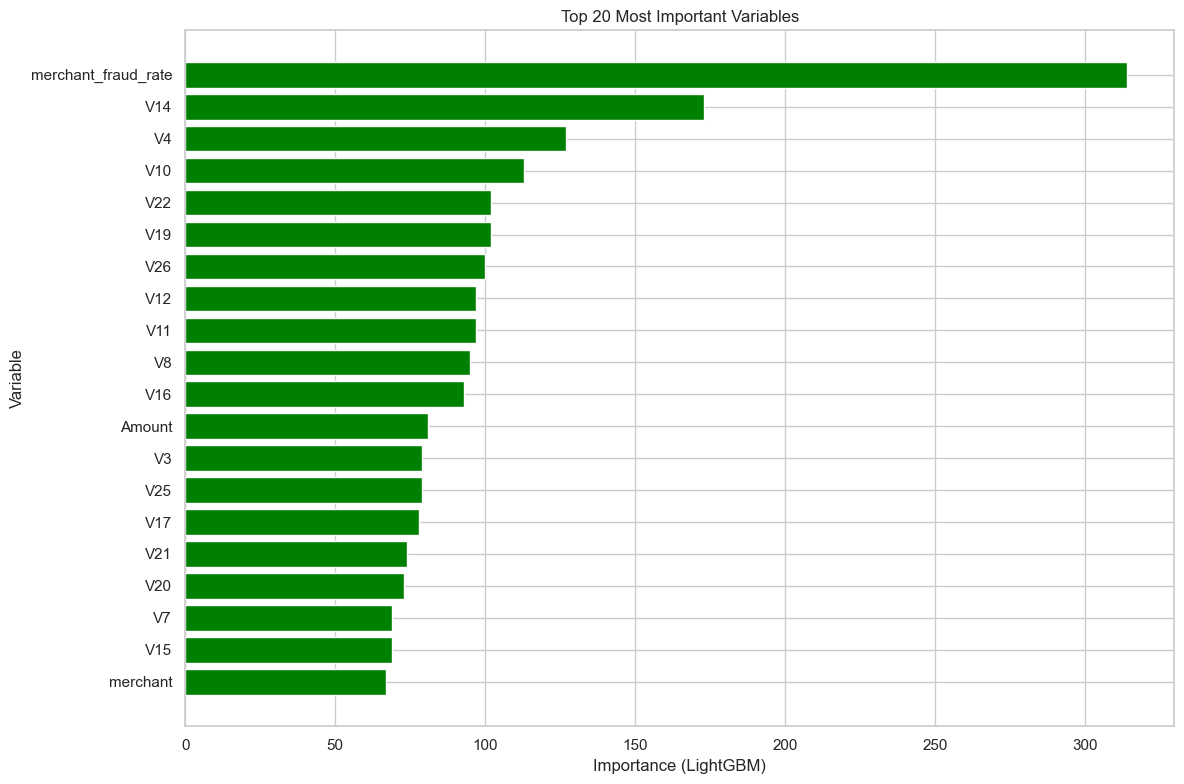

Vars: 1 | F1-score: 0.1762 | Recall: 0.9250 | Precision: 0.0974
Vars: 5 | F1-score: 0.7524 | Recall: 0.9650 | Precision: 0.6166
Vars: 10 | F1-score: 0.1313 | Recall: 0.9450 | Precision: 0.0706
Vars: 15 | F1-score: 0.7342 | Recall: 0.9425 | Precision: 0.6013
Vars: 20 | F1-score: 0.6050 | Recall: 0.9325 | Precision: 0.4478
Vars: 25 | F1-score: 0.9350 | Recall: 0.9525 | Precision: 0.9181
Vars: 30 | F1-score: 0.9299 | Recall: 0.9450 | Precision: 0.9153
Vars: 35 | F1-score: 0.9095 | Recall: 0.9550 | Precision: 0.8682
Vars: 40 | F1-score: 0.9320 | Recall: 0.9425 | Precision: 0.9218
Vars: 45 | F1-score: 0.6414 | Recall: 0.8875 | Precision: 0.5021
Vars: 50 | F1-score: 0.6025 | Recall: 0.8375 | Precision: 0.4705
Vars: 55 | F1-score: 0.5829 | Recall: 0.8700 | Precision: 0.4383
Vars: 60 | F1-score: 0.5829 | Recall: 0.8700 | Precision: 0.4383
Vars: 65 | F1-score: 0.6193 | Recall: 0.8500 | Precision: 0.4871


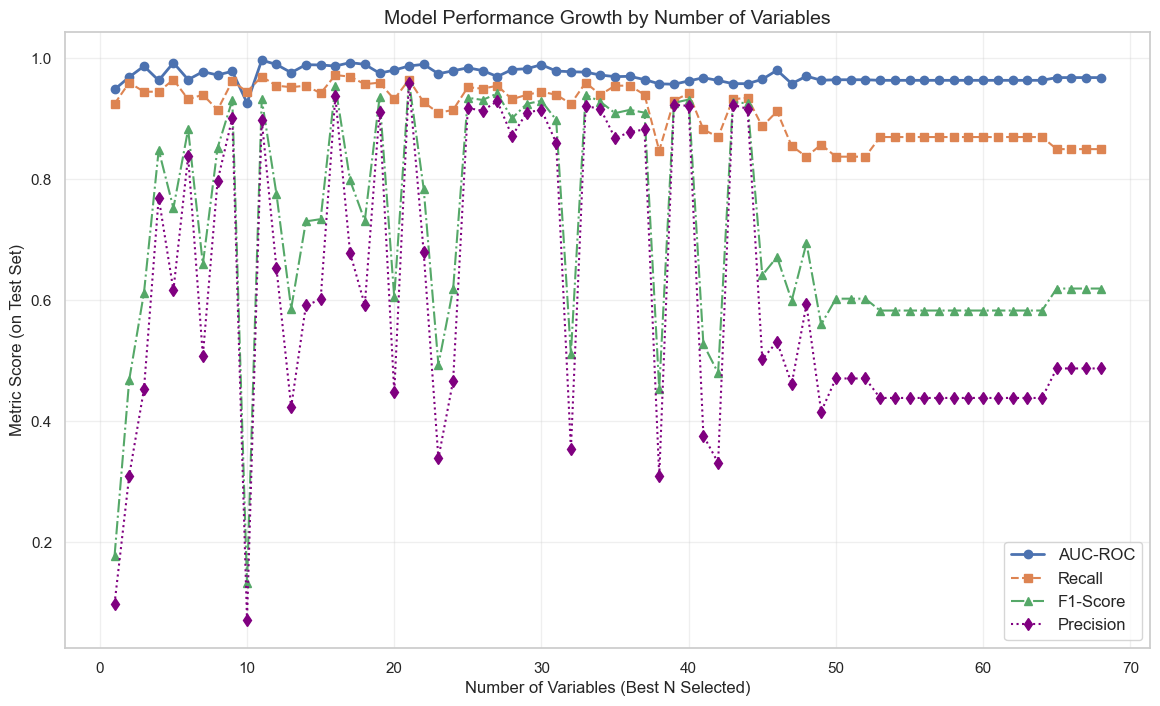

In [66]:
# --- 1. Data Preparation ---
TARGET_COLUMN = 'Class'
COLUMNS_TO_DROP = [TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id', 'email', 'phone', 'name', 'timestamp']

y = df[TARGET_COLUMN]
X = df.drop(columns=COLUMNS_TO_DROP, errors='ignore')

# Convert object variables to 'category' dtype for LightGBM
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_features:
    X[col] = X[col].astype('category')

# --- 2. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# --- 3. Training the model  ---
lgbm_base = lgbm.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

# Create Importance DataFrame
importances = lgbm_base.feature_importances_
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_LGBM1 = importance_df['Variable'].tolist()

# PLOT 1: Top 20 Feature Importances (Bar Chart)
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_20_features['Variable'],
    top_20_features['Importance'],
    color='green'
)
plt.xlabel("Importance (LightGBM)")
plt.ylabel("Variable")
plt.title("Top 20 Most Important Variables")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# PART 2: Iterative Performance Evaluation

# Arrays to store results
metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f1': [],
    'precision': []
}

# Loop through features
for k in range(1, len(sorted_features_LGBM1) + 1, 1):

    # Select top k features
    selected_feats = sorted_features_LGBM1[:k]

    # Train a new model
    model_k = lgbm.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # Train
    model_k.fit(X_train[selected_feats], y_train)

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Calculate Metrics
    metrics_results['num_vars'].append(k)
    metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    metrics_results['recall'].append(recall_score(y_test, preds_test))
    metrics_results['f1'].append(f1_score(y_test, preds_test))
    metrics_results['precision'].append(precision_score(y_test, preds_test))

    # Print progress
    if k % 5 == 0 or k == 1:
        print(f"Vars: {k} | F1-score: {metrics_results['f1'][-1]:.4f} | Recall: {metrics_results['recall'][-1]:.4f} | Precision: {metrics_results['precision'][-1]:.4f}")

# PLOT 2: Performance Curve (Line Chart)
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
plt.plot(metrics_results['num_vars'], metrics_results['f1'], label='F1-Score', marker='^', linestyle='-.')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':', color='purple')

plt.xlabel('Number of Variables (Best N Selected)', fontsize=12)
plt.ylabel('Metric Score (on Test Set)', fontsize=12)
plt.title('Model Performance Growth by Number of Variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


## CatBoost

Train shape: (228854, 67), Test shape: (57214, 67)
Categorical features: ['merchant_country', 'city', 'zip_code', 'merchant', 'is_foreign_tx', 'is_night_tx', 'is_high_amount', 'is_weekend', 'time_of_day', 'device_type', 'os', 'browser', 'is_mobile', 'customer_country', 'night', 'morning', 'afternoon', 'evening', 'tenure_bucket', 'geo_anomaly', 'main_device', 'main_browser', 'device_change', 'browser_change', 'shared_ip', 'is_outlier_amount']


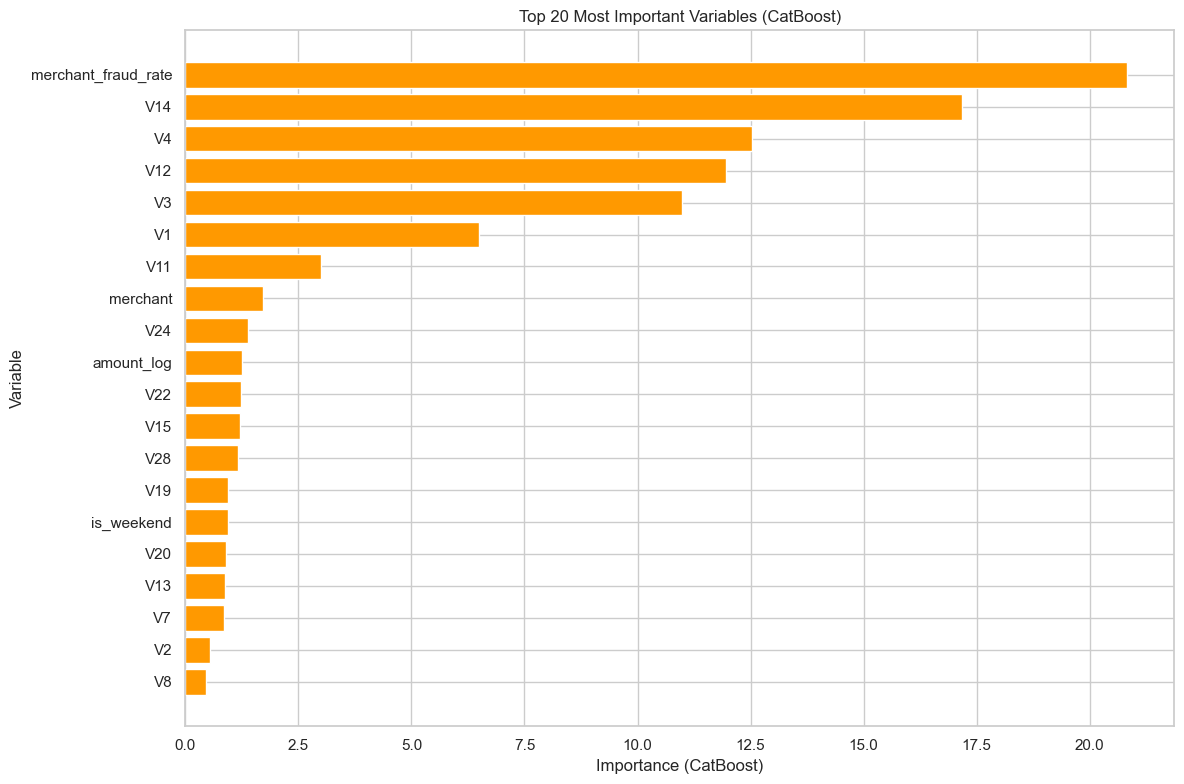

Vars: 1 | AUC: 0.9898 | Recall: 0.9800 | F1: 0.1548 | Precision: 0.0840
Vars: 5 | AUC: 0.9999 | Recall: 0.9875 | F1: 0.9122 | Precision: 0.8476
Vars: 15 | AUC: 1.0000 | Recall: 0.9875 | F1: 0.9472 | Precision: 0.9101
Vars: 25 | AUC: 0.9999 | Recall: 0.9900 | F1: 0.9754 | Precision: 0.9612
Vars: 35 | AUC: 1.0000 | Recall: 0.9925 | F1: 0.9636 | Precision: 0.9363


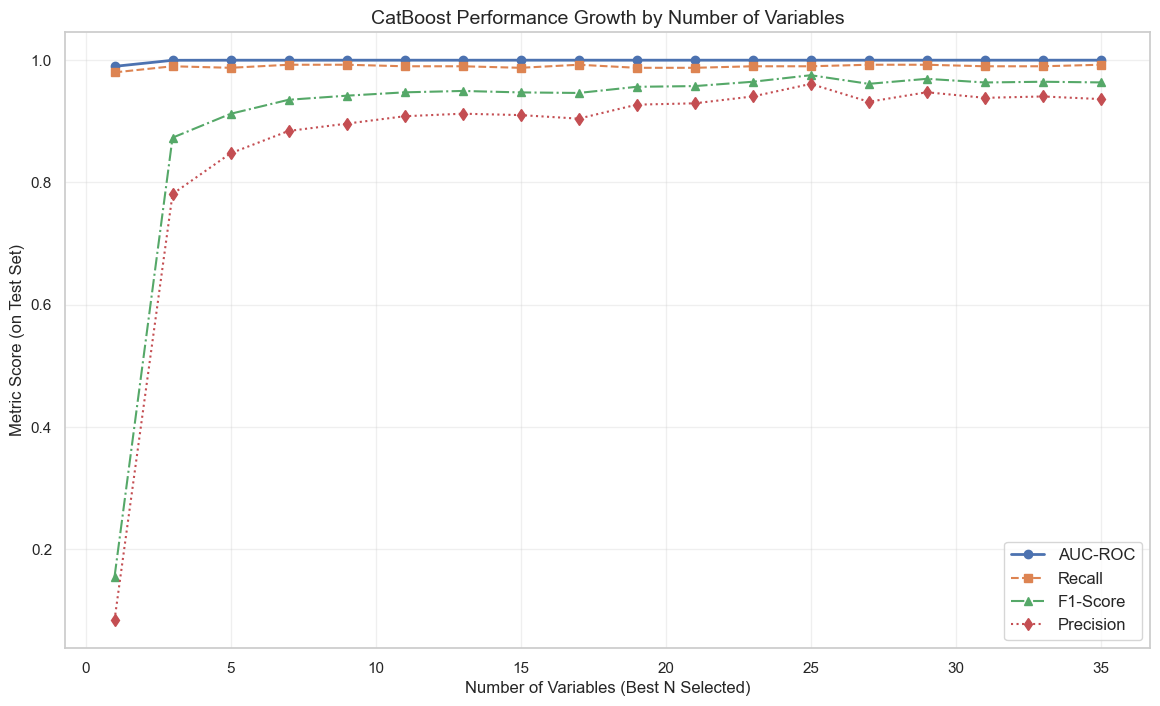

In [67]:
TARGET_COLUMN = 'Class'
COLUMNS_TO_DROP = [TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id', 'email', 'phone', 'name', 'timestamp', 'ip_address']

y = df[TARGET_COLUMN]
X = df.drop(columns=COLUMNS_TO_DROP, errors='ignore')

# We identify categorical features and ensure their type
all_categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in all_categorical_cols:
    X[col] = X[col].astype(str)

# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Categorical features: {all_categorical_cols}")

# We train the model to get ranking

base_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    thread_count=-1,
    auto_class_weights='Balanced',
    verbose=False,
    depth = 3,
    n_estimators = 100
)

base_model.fit(X_train, y_train, cat_features=all_categorical_cols)

# We get the feature importance
importances = base_model.get_feature_importance(type='FeatureImportance')
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_CB1 = importance_df['Variable'].tolist()

# PLOT 1: We plot the top 20 Feature Importances
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20_features['Variable'], top_20_features['Importance'], color='#FF9900')
plt.xlabel("Importance (CatBoost)")
plt.ylabel("Variable")
plt.title("Top 20 Most Important Variables (CatBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# We compute the different metrics

metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f1': [],
    'precision': []}

# Loop through features
step = 2
for k in range(1, 36, step):

    # Select Top k features
    selected_feats = sorted_features_CB1[:k]

    # Dynamic categorical detection
    current_cat_features = [f for f in selected_feats if f in all_categorical_cols]

    # Train the new model on subset
    model_k = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        thread_count=-1,
        auto_class_weights='Balanced',
        verbose=False,
        allow_writing_files=False
    )

    model_k.fit(
        X_train[selected_feats],
        y_train,
        cat_features=current_cat_features
    )

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Get the metrics
    metrics_results['num_vars'].append(k)
    metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    metrics_results['recall'].append(recall_score(y_test, preds_test))
    metrics_results['f1'].append(f1_score(y_test, preds_test))
    metrics_results['precision'].append(precision_score(y_test, preds_test))

    if k % 5 == 0 or k == 1:
        print(
            f"Vars: {k} | AUC: {metrics_results['auc'][-1]:.4f} | "
            f"Recall: {metrics_results['recall'][-1]:.4f} | "
            f"F1: {metrics_results['f1'][-1]:.4f} | "
            f"Precision: {metrics_results['precision'][-1]:.4f}"
        )

# PLOT 2: The performance curve
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
plt.plot(metrics_results['num_vars'], metrics_results['f1'], label='F1-Score', marker='^', linestyle='-.')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':')

plt.xlabel('Number of Variables (Best N Selected)', fontsize=12)
plt.ylabel('Metric Score (on Test Set)', fontsize=12)
plt.title('CatBoost Performance Growth by Number of Variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## Studying Leakeage

After fitting LightGMB and CatBoost, we suspect that merchant_fraud_rate and country_fraud_rate may contain class leakage. Therefore, we will repeat the fitting without these variables and compare the results.

Train shape: (228854, 66), Test shape: (57214, 66)


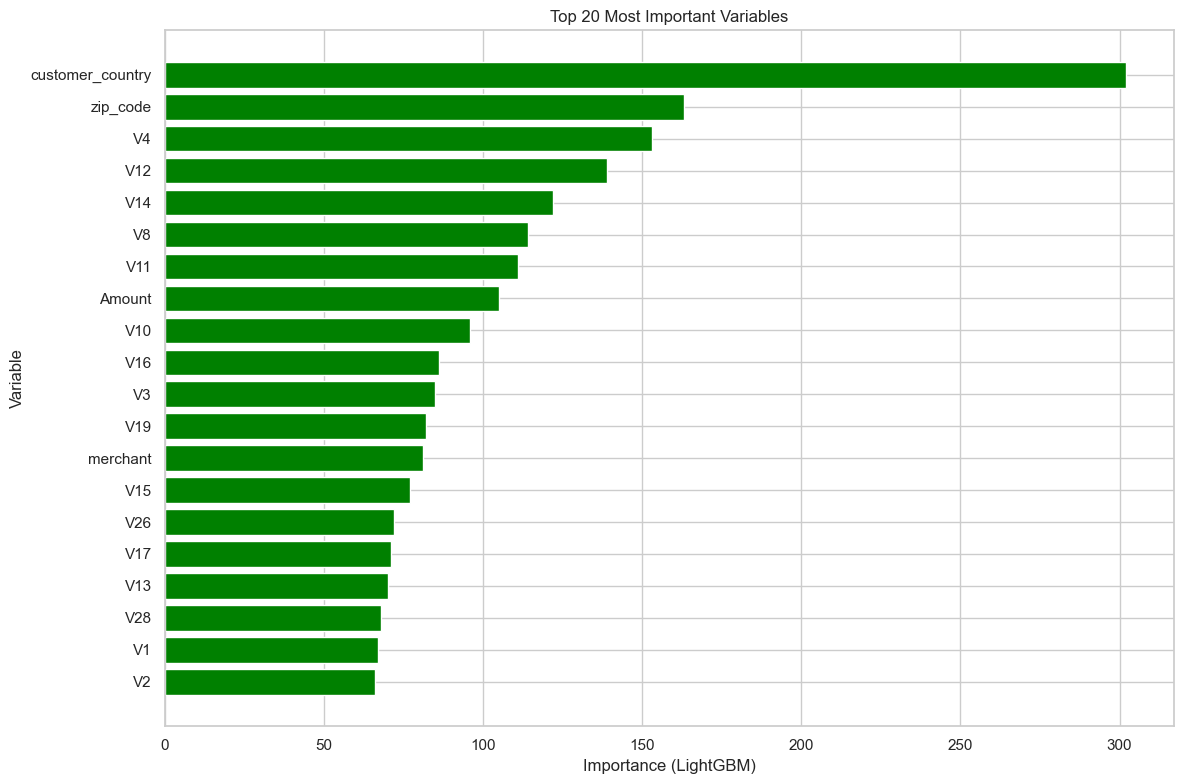

Vars: 1 | F1-score: 0.0142 | Recall: 0.4750 | Precision: 0.0072
Vars: 5 | F1-score: 0.6674 | Recall: 0.7825 | Precision: 0.5818
Vars: 10 | F1-score: 0.8596 | Recall: 0.8575 | Precision: 0.8618
Vars: 15 | F1-score: 0.7787 | Recall: 0.8225 | Precision: 0.7393
Vars: 20 | F1-score: 0.7372 | Recall: 0.8450 | Precision: 0.6538
Vars: 25 | F1-score: 0.8610 | Recall: 0.8750 | Precision: 0.8475
Vars: 30 | F1-score: 0.8928 | Recall: 0.8950 | Precision: 0.8905
Vars: 35 | F1-score: 0.8360 | Recall: 0.8600 | Precision: 0.8132
Vars: 40 | F1-score: 0.6034 | Recall: 0.7950 | Precision: 0.4862
Vars: 45 | F1-score: 0.8881 | Recall: 0.8925 | Precision: 0.8837
Vars: 50 | F1-score: 0.8585 | Recall: 0.8725 | Precision: 0.8450
Vars: 55 | F1-score: 0.8585 | Recall: 0.8725 | Precision: 0.8450
Vars: 60 | F1-score: 0.8585 | Recall: 0.8725 | Precision: 0.8450
Vars: 65 | F1-score: 0.8585 | Recall: 0.8725 | Precision: 0.8450


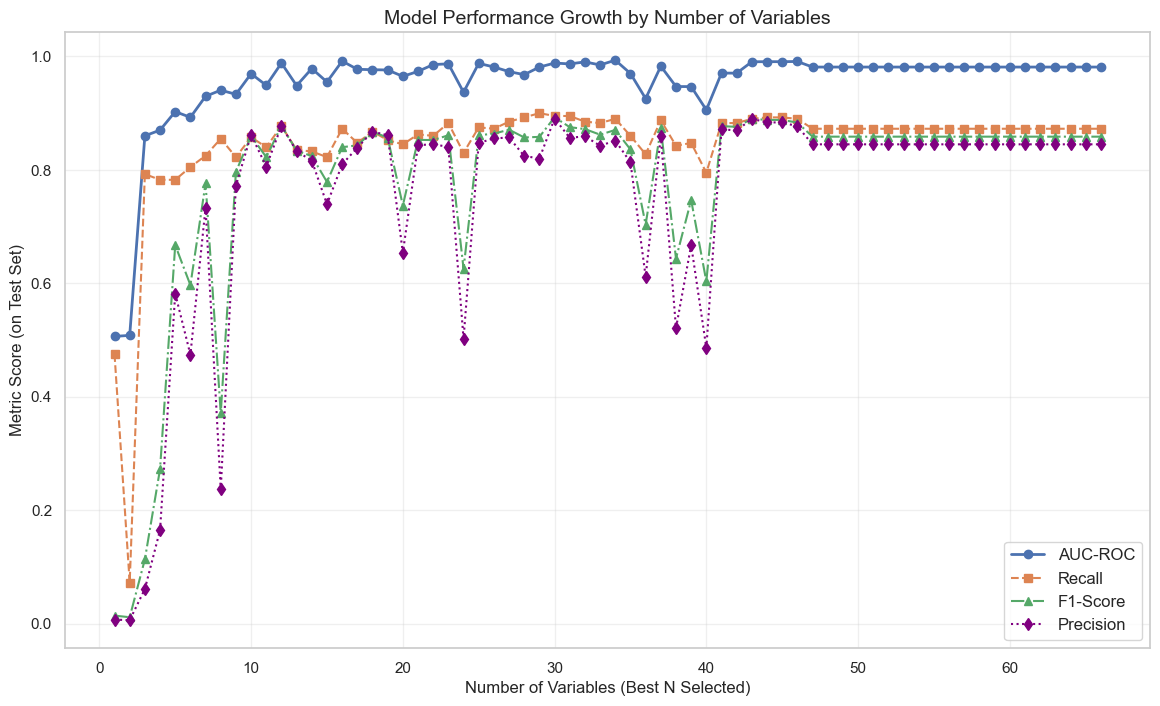

In [68]:
TARGET_COLUMN = 'Class'
COLUMNS_TO_DROP = [TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id', 'email', 'phone', 'name', 'timestamp', 'country_fraud_rate', "merchant_fraud_rate"]


y = df[TARGET_COLUMN]
X = df.drop(columns=COLUMNS_TO_DROP, errors='ignore')

# Convert categorical variables to 'category' dtype for LightGBM
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_features:
    X[col] = X[col].astype('category')

# --- 2. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# --- 3. Train Base Model to get Feature Ranking ---
lgbm_base = lgbm.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

# Create Importance DataFrame
importances = lgbm_base.feature_importances_
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_LGBM = importance_df['Variable'].tolist()

# PLOT 1: Top 20 Feature Importances (Bar Chart)
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_20_features['Variable'],
    top_20_features['Importance'],
    color='green'
)
plt.xlabel("Importance (LightGBM)")
plt.ylabel("Variable")
plt.title("Top 20 Most Important Variables")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# PART 2: Iterative Performance Evaluation

# Arrays to store results
metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f1': [],
    'precision': []
}

# Loop through features
for k in range(1, len(sorted_features_LGBM) + 1, 1):

    # Select top k features
    selected_feats = sorted_features_LGBM[:k]

    # Train a new model
    model_k = lgbm.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # Train
    model_k.fit(X_train[selected_feats], y_train)

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Calculate Metrics
    metrics_results['num_vars'].append(k)
    metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    metrics_results['recall'].append(recall_score(y_test, preds_test))
    metrics_results['f1'].append(f1_score(y_test, preds_test))
    metrics_results['precision'].append(precision_score(y_test, preds_test))

    # Print progress
    if k % 5 == 0 or k == 1:
        print(f"Vars: {k} | F1-score: {metrics_results['f1'][-1]:.4f} | Recall: {metrics_results['recall'][-1]:.4f} | Precision: {metrics_results['precision'][-1]:.4f}")

# PLOT 2: Performance Curve (Line Chart)
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
plt.plot(metrics_results['num_vars'], metrics_results['f1'], label='F1-Score', marker='^', linestyle='-.')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':', color='purple')

plt.xlabel('Number of Variables (Best N Selected)', fontsize=12)
plt.ylabel('Metric Score (on Test Set)', fontsize=12)
plt.title('Model Performance Growth by Number of Variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
print(sorted_features_LGBM)

['customer_country', 'zip_code', 'V4', 'V12', 'V14', 'V8', 'V11', 'Amount', 'V10', 'V16', 'V3', 'V19', 'merchant', 'V15', 'V26', 'V17', 'V13', 'V28', 'V1', 'V2', 'V7', 'V25', 'V6', 'V23', 'V18', 'V5', 'V20', 'V22', 'V21', 'V24', 'V9', 'V27', 'hour_sin', 'hour_cos', 'city', 'tx_per_customer', 'tx_rate', 'days_in_bank', 'credit_score', 'secs_since_prev_tx', 'age', 'morning', 'is_weekend', 'is_mobile', 'is_high_amount', 'evening', 'browser_change', 'ip_address', 'merchant_country', 'os', 'night', 'device_type', 'is_night_tx', 'is_foreign_tx', 'time_of_day', 'browser', 'days_in_bank_log', 'afternoon', 'tenure_bucket', 'geo_anomaly', 'main_browser', 'main_device', 'device_change', 'shared_ip', 'amount_log', 'is_outlier_amount']


Train shape: (228854, 65), Test shape: (57214, 65)
Categorical features: ['merchant_country', 'city', 'zip_code', 'merchant', 'is_foreign_tx', 'is_night_tx', 'is_high_amount', 'is_weekend', 'time_of_day', 'device_type', 'os', 'browser', 'is_mobile', 'customer_country', 'night', 'morning', 'afternoon', 'evening', 'tenure_bucket', 'geo_anomaly', 'main_device', 'main_browser', 'device_change', 'browser_change', 'shared_ip', 'is_outlier_amount']


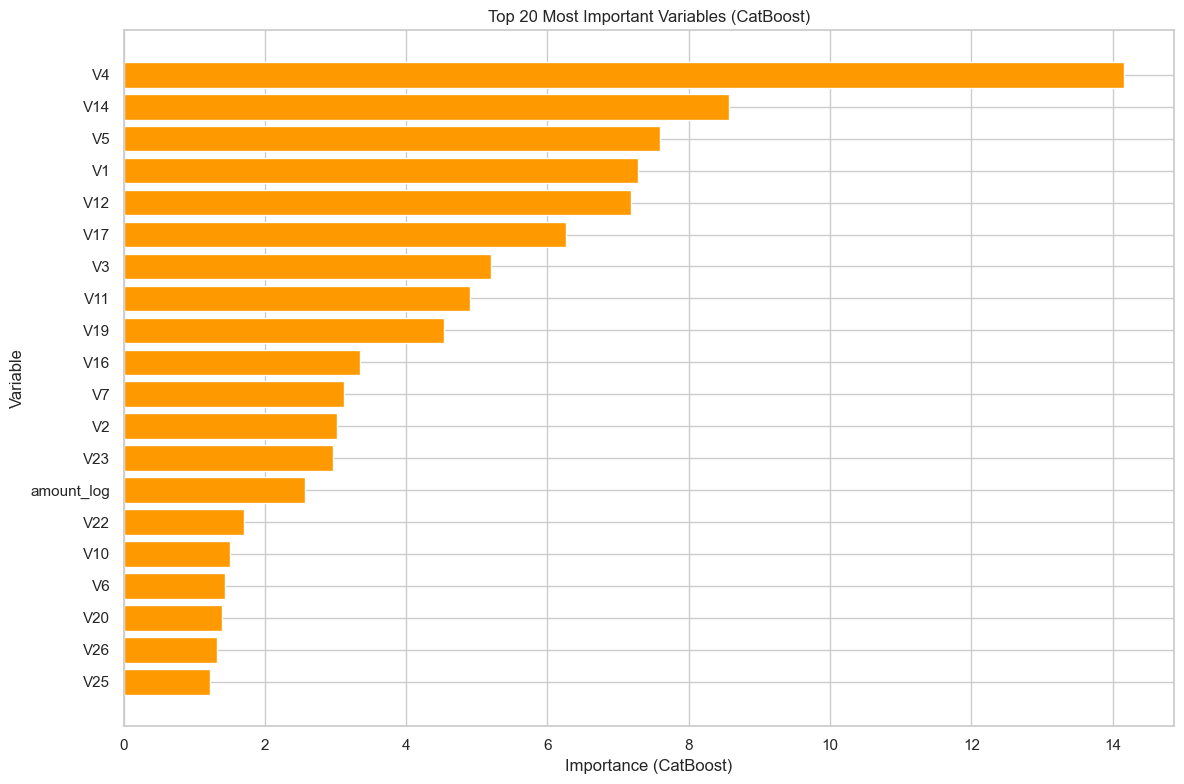

Vars: 1 | AUC: 0.9575 | Recall: 0.8950 | F1: 0.0902 | Precision: 0.0475
Vars: 5 | AUC: 0.9996 | Recall: 0.9975 | F1: 0.9110 | Precision: 0.8382
Vars: 15 | AUC: 0.9988 | Recall: 0.9950 | F1: 0.9602 | Precision: 0.9277
Vars: 25 | AUC: 0.9994 | Recall: 0.9900 | F1: 0.9754 | Precision: 0.9612
Vars: 35 | AUC: 0.9988 | Recall: 0.9950 | F1: 0.9791 | Precision: 0.9637


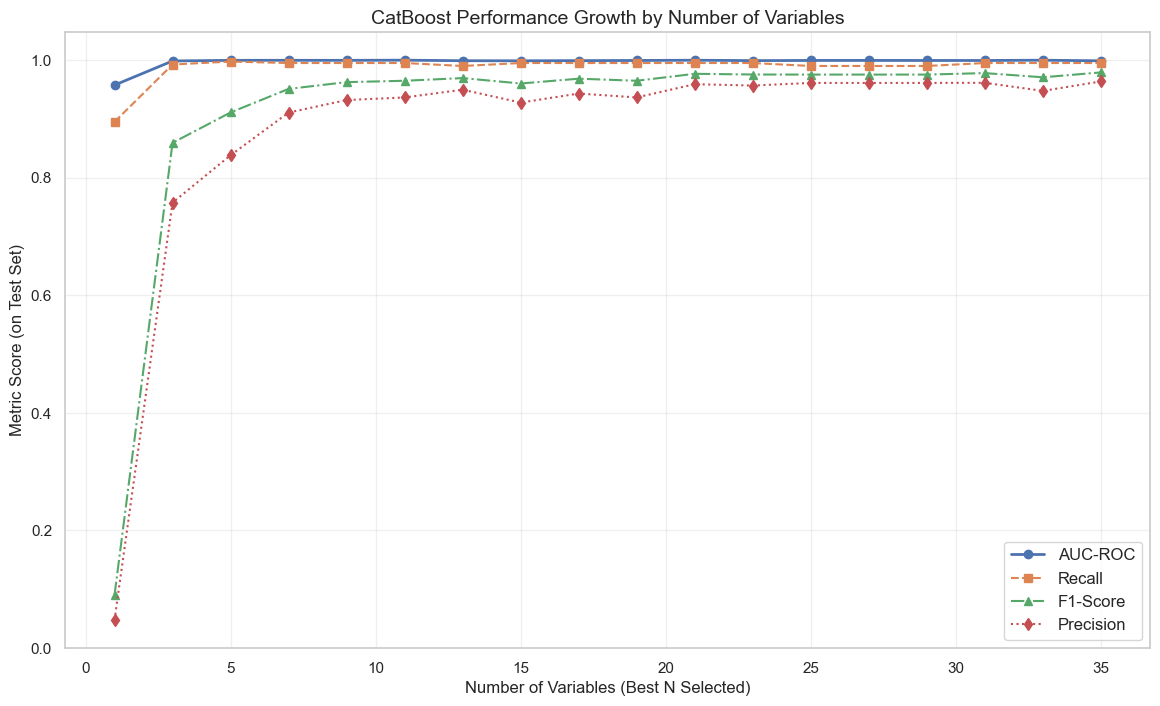

In [70]:
TARGET_COLUMN = 'Class'
COLUMNS_TO_DROP = [TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id', 'email', 'phone', 'name', 'timestamp','ip_address', 'merchant_fraud_rate', 'country_fraud_rate']

y = df[TARGET_COLUMN]
X = df.drop(columns=COLUMNS_TO_DROP, errors='ignore')

# We identify categorical features and ensure their type
all_categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in all_categorical_cols:
    X[col] = X[col].astype(str)

# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Categorical features: {all_categorical_cols}")

# We train the model to get ranking

base_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    thread_count=-1,
    auto_class_weights='Balanced',
    verbose=False,
    depth = 3,
    n_estimators = 100
)

base_model.fit(X_train, y_train, cat_features=all_categorical_cols)

# We get the feature importance
importances = base_model.get_feature_importance(type='FeatureImportance')
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_CB = importance_df['Variable'].tolist()

# PLOT 1: We plot the top 20 Feature Importances
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20_features['Variable'], top_20_features['Importance'], color='#FF9900')
plt.xlabel("Importance (CatBoost)")
plt.ylabel("Variable")
plt.title("Top 20 Most Important Variables (CatBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# We compute the different metrics

metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f1': [],
    'precision': []}

# Loop through features
step = 2
for k in range(1, 36 + 1, step):

    # Select Top k features
    selected_feats = sorted_features_CB[:k]

    # Dynamic categorical detection
    current_cat_features = [f for f in selected_feats if f in all_categorical_cols]

    # Train the new model on subset
    model_k = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        thread_count=-1,
        auto_class_weights='Balanced',
        verbose=False,
        allow_writing_files=False
    )

    model_k.fit(
        X_train[selected_feats],
        y_train,
        cat_features=current_cat_features
    )

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Get the metrics
    metrics_results['num_vars'].append(k)
    metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    metrics_results['recall'].append(recall_score(y_test, preds_test))
    metrics_results['f1'].append(f1_score(y_test, preds_test))
    metrics_results['precision'].append(precision_score(y_test, preds_test))

    if k % 5 == 0 or k == 1:
        print(
            f"Vars: {k} | AUC: {metrics_results['auc'][-1]:.4f} | "
            f"Recall: {metrics_results['recall'][-1]:.4f} | "
            f"F1: {metrics_results['f1'][-1]:.4f} | "
            f"Precision: {metrics_results['precision'][-1]:.4f}"
        )

# PLOT 2: The performance curve
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
plt.plot(metrics_results['num_vars'], metrics_results['f1'], label='F1-Score', marker='^', linestyle='-.')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':')

plt.xlabel('Number of Variables (Best N Selected)', fontsize=12)
plt.ylabel('Metric Score (on Test Set)', fontsize=12)
plt.title('CatBoost Performance Growth by Number of Variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [71]:
print(sorted_features_CB)

['V4', 'V14', 'V5', 'V1', 'V12', 'V17', 'V3', 'V11', 'V19', 'V16', 'V7', 'V2', 'V23', 'amount_log', 'V22', 'V10', 'V6', 'V20', 'V26', 'V25', 'V24', 'V15', 'V18', 'V8', 'morning', 'Amount', 'hour_sin', 'V27', 'is_high_amount', 'V13', 'V21', 'V9', 'time_of_day', 'hour_cos', 'V28', 'days_in_bank', 'is_weekend', 'credit_score', 'customer_country', 'city', 'merchant_country', 'merchant', 'zip_code', 'browser', 'os', 'is_night_tx', 'age', 'device_type', 'is_foreign_tx', 'night', 'is_mobile', 'evening', 'afternoon', 'tenure_bucket', 'secs_since_prev_tx', 'tx_per_customer', 'days_in_bank_log', 'tx_rate', 'geo_anomaly', 'main_browser', 'main_device', 'device_change', 'browser_change', 'shared_ip', 'is_outlier_amount']


## Selecting the variables

Since the metrics decrease significantly with the first variables, we can conclude that there is in fact class leakage. Thus, we decided to remove variables that were computed with class information.

In [72]:
df = df.drop(columns=['merchant_fraud_rate'], errors='ignore')
df = df.drop(columns=['country_fraud_rate'], errors='ignore')

Now we select the columns we want to keep with respect to the information provided by LightGBM and CatBoost

In [73]:
#COLUMNS_TO_KEEP=importance_df.head(17)

# **6. Dataset Expansion**

### **Aleatorio sin tener en cuenta la Class**

In [74]:
target_size = 500000
current_size = len(df)
n_new = target_size - current_size

# We select a base sample with replacement
synthetic_df = df.sample(n=n_new, replace=True, random_state=42).copy()

# We add controlled noise to numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Class', errors='ignore')

for col in numeric_cols:
    std = df[col].std()
    if std > 0:
        # Add normal noise with a deviation of 1% from the original
        synthetic_df[col] += np.random.normal(0, std * 0.01, size=len(synthetic_df))

# We combine the two datasets
df_exp_random = pd.concat([df, synthetic_df], ignore_index=True)
print("Expanded dataset:", df_exp_random.shape)
print("Class distribution:")
print(df_exp_random['Class'].value_counts(normalize=True))

Expanded dataset: (500000, 74)
Class distribution:
Class
0    0.992904
1    0.007096
Name: proportion, dtype: float64


### **Misma Proporción 99.3% - 0.7%**

In [75]:
target_size = 500000
current_size = len(df)
n_new = target_size - current_size

# Calculating class proportions
class_counts = df['Class'].value_counts(normalize=True)
p0, p1 = class_counts[0], class_counts[1]

n_new_0 = int(n_new * p0)
n_new_1 = n_new - n_new_0

# Creating sinthetic samples per class
synthetic_0 = df[df['Class'] == 0].sample(n=n_new_0, replace=True, random_state=42).copy()
synthetic_1 = df[df['Class'] == 1].sample(n=n_new_1, replace=True, random_state=42).copy()

# Adding noise to control numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Class', errors='ignore')

for subset in [synthetic_0, synthetic_1]:
    for col in numeric_cols:
        std = df[col].std()
        if std > 0:
            subset[col] += np.random.normal(0, std * 0.01, size=len(subset))

# Combine the datasets
synthetic_df = pd.concat([synthetic_0, synthetic_1], ignore_index=True)
df_exp_same_prop = pd.concat([df, synthetic_df], ignore_index=True)
print("Expanded Dataset:", df_exp_same_prop.shape)
print("Class distribution:")
print(df_exp_same_prop['Class'].value_counts(normalize=True))


Expanded Dataset: (500000, 74)
Class distribution:
Class
0    0.993008
1    0.006992
Name: proportion, dtype: float64


### **Proporción 66.6% - 33.3%**

In [76]:
target_size = 500000
current_size = len(df)
n_new = target_size - current_size

# Our goal is 2/3 and 1/3 (≈66.6% / 33.3%)
desired_0 = 333333
desired_1 = 166667

# How much we need to create per class
current_0 = (df['Class'] == 0).sum()
current_1 = (df['Class'] == 1).sum()

add_0 = max(0, desired_0 - current_0)
add_1 = max(0, desired_1 - current_1)

# Creating observations
synthetic_0 = df[df['Class'] == 0].sample(n=add_0, replace=True, random_state=42).copy() if add_0 > 0 else pd.DataFrame(columns=df.columns)
synthetic_1 = df[df['Class'] == 1].sample(n=add_1, replace=True, random_state=42).copy() if add_1 > 0 else pd.DataFrame(columns=df.columns)

synthetic_df = pd.concat([synthetic_0, synthetic_1], ignore_index=True)

# Adding noise to numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Class', errors='ignore')

for col in numeric_cols:
    std = df[col].std()
    if pd.notna(std) and std > 0:
        synthetic_df[col] = synthetic_df[col].astype(float) + np.random.normal(0, std * 0.01, size=len(synthetic_df))

# Combine datasets
df_exp_63 = pd.concat([df, synthetic_df], ignore_index=True)

print("Expanded dataset:", df_exp_63.shape)
print("Class distribution:")
print(df_exp_63['Class'].value_counts(normalize=True))

Expanded dataset: (500000, 74)
Class distribution:
Class
0    0.666666
1    0.333334
Name: proportion, dtype: float64


### **Proporción 50 - 50 (56.8% - 43.2%): Oversamping Class 1**

In [77]:
target_size = 500000
current_size = len(df)
n_new = target_size - current_size

# Oversampling ONLY of class 1
df_class1 = df[df['Class'] == 1]
synthetic_df = df_class1.sample(n=n_new, replace=True, random_state=42).copy()

# Add noise to numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Class', errors='ignore')

for col in numeric_cols:
    std = df[col].std()
    if std > 0:
        synthetic_df[col] += np.random.normal(0, std * 0.01, size=len(synthetic_df))

# Combine datasets
df_exp_50 = pd.concat([df, synthetic_df], ignore_index=True)
print("Expanded dataset:", df_exp_50.shape)
print("Class distribution:")
print(df_exp_50['Class'].value_counts(normalize=True))


Expanded dataset: (500000, 74)
Class distribution:
Class
0    0.568136
1    0.431864
Name: proportion, dtype: float64


### **SMOTE --> Usar con modelos que no balanceen**

# **7. Dataset Download**

In [78]:
folder_name = "csv_exports"
os.makedirs(folder_name, exist_ok=True)

In [79]:
df_exp_random.to_csv("csv_exports/df_exp_random.csv", index=False)

In [80]:
df_exp_same_prop.to_csv("csv_exports/df_exp_same_prop.csv", index=False)

In [81]:
df_exp_63.to_csv("csv_exports/df_exp_63.csv", index=False)

In [82]:
df_exp_50.to_csv("csv_exports/df_exp_50.csv", index=False)